# 170 — Generate final paper figures from authoritative pipeline products

This notebook generates the deployment map, the 30-minute sequence overview, key-event waveform panels, and source-aligned video/audio close-ups. Scientific inputs are read from the numbered pipeline products and `project_config.py`; calculations from weather analysis, catalogue construction, array analysis, polarization, or key-event measurement are not repeated here.

Source-to-BCHH travel-time reduction uses the Notebook 03 meteorological effective speed (approximately 351 m s⁻¹). The approximately 352 m s⁻¹ Notebook 080 apparent trace velocity is reported for comparison only. Camera audio uses the path-specific meteorological speed recorded by Notebook 13(?) (approximately 349 m s⁻¹).


## Pipeline-product figure generation

Required upstream products are validated at the start. The notebook uses the
canonical D* channel convention:

- DD1, DD2, DD3: infrasound
- DHE, DHN, DHZ: seismic

Legacy H* channel codes are not used in this notebook.


In [1]:
from __future__ import annotations

from pathlib import Path
import json
import sys
import warnings
from pprint import pprint

project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from obspy import Stream, Trace, UTCDateTime, read, read_inventory
from pyproj import Geod, Transformer

from modules import project_config as config
from modules.kml_utils import read_kml_points
from modules.xml_utils import (
    inventory_channels_to_dataframe,
    inventory_stations_to_dataframe,
    load_station_sensor_dataframe,
)
from modules.figure1_utils_fixed import (
    get_sensor_location,
    make_figure1,
    save_figure,
)

PROJECT_ROOT = config.PROJECT_ROOT
OUTDIR = config.NB170_DIR
OUTDIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.dpi": 120,
})


## 2. Load authoritative pipeline products

This cell is the single source of paths and scientific parameters for all
figures below.


In [2]:
# -----------------------------------------------------------------------------
# Required numbered products
# -----------------------------------------------------------------------------
ANALYSIS_CONFIG_FILE = config.NB010_DIR / "analysis_configuration.json"
WEATHER_FILE = config.NB020_DIR / "weather_acoustic_summary.csv"
CATALOGUE_FILE = config.NB030_DIR / "final_153_event_catalogue.csv"
PLANAR_RESULTS_FILE = (
    config.NB080_DIR
    / "planar_array_results.csv"
)
PLANAR_SUMMARY_FILE = (
    config.NB080_DIR
    / "planar_refined_solution_summaries.csv"
)
KEY_EVENT_PRESSURES_FILE = (
    config.NB110_DIR / "key_event_pressure_measurements.csv"
)
KEY_EVENT_WINDOWS_FILE = (
    config.NB110_DIR / "key_event_measurement_windows.csv"
)
KEY_EVENT_METADATA_FILE = (
    config.NB110_DIR / "key_event_measurement_metadata.json"
)
VIDEO_SYNC_FILE = (
    config.NB160_DIR
    / "video_sync_configuration.json"
)

for required in (
    ANALYSIS_CONFIG_FILE,
    WEATHER_FILE,
    CATALOGUE_FILE,
):
    if not required.exists():
        raise FileNotFoundError(
            f"Required pipeline product not found: {required}"
        )

analysis_config = json.loads(ANALYSIS_CONFIG_FILE.read_text())
weather_summary = pd.read_csv(WEATHER_FILE).iloc[0]
catalogue = pd.read_csv(CATALOGUE_FILE)

GEOMETRY_FILE = Path(analysis_config["geometry_file"]).expanduser()
KEY_EVENTS_FILE = Path(analysis_config["key_events_file"]).expanduser()
BASELINE_STREAM_FILE = Path(
    analysis_config["baseline_removed_streams"]["pickle"]
).expanduser()
CORRECTED_PICKLE_FILE = Path(
    analysis_config["notebook_01_products"]["corrected_pickle"]
).expanduser()
CORRECTED_STATIONXML_FILE = Path(
    analysis_config["notebook_01_products"]["calibrated_stationxml"]
).expanduser()
CORRECTION_SUMMARY_FILE = Path(
    analysis_config["notebook_01_products"]["channel_summary"]
).expanduser()

for required in (
    GEOMETRY_FILE,
    KEY_EVENTS_FILE,
    BASELINE_STREAM_FILE,
    CORRECTED_STATIONXML_FILE,
):
    if not required.exists():
        raise FileNotFoundError(
            f"Pipeline product recorded by Notebook 02 was not found: {required}"
        )

geometry = pd.read_csv(GEOMETRY_FILE)
key_events = pd.read_csv(KEY_EVENTS_FILE)
planar_results = (
    pd.read_csv(PLANAR_RESULTS_FILE)
    if PLANAR_RESULTS_FILE.exists()
    else pd.DataFrame()
)
planar_summaries = (
    pd.read_csv(PLANAR_SUMMARY_FILE)
    if PLANAR_SUMMARY_FILE.exists()
    else pd.DataFrame()
)
key_event_pressures = (
    pd.read_csv(KEY_EVENT_PRESSURES_FILE)
    if KEY_EVENT_PRESSURES_FILE.exists()
    else pd.DataFrame()
)
key_event_windows = (
    pd.read_csv(KEY_EVENT_WINDOWS_FILE)
    if KEY_EVENT_WINDOWS_FILE.exists()
    else pd.DataFrame()
)
key_event_metadata = (
    json.loads(KEY_EVENT_METADATA_FILE.read_text())
    if KEY_EVENT_METADATA_FILE.exists()
    else {}
)
video_sync = (
    json.loads(VIDEO_SYNC_FILE.read_text())
    if VIDEO_SYNC_FILE.exists()
    else {}
)

CHANNEL_ORDER = list(analysis_config["pressure_channels"]) + list(
    analysis_config["seismic_channels"]
)
PRESSURE_CHANNELS = tuple(analysis_config["pressure_channels"])
SEISMIC_CHANNELS = tuple(analysis_config["seismic_channels"])

legacy_channels = [
    channel for channel in CHANNEL_ORDER
    if channel.startswith("H")
]
if legacy_channels:
    raise ValueError(
        f"Notebook 02 configuration contains legacy H* channels: {legacy_channels}"
    )

EVENT_START = UTCDateTime(
    float(analysis_config["analysis_start_epoch_s"])
)
EVENT_END = UTCDateTime(
    float(analysis_config["analysis_end_epoch_s"])
)
BCHH_NETWORK = str(analysis_config["network"])
BCHH_STATION = str(analysis_config["station"])
BCHH_LOCATION = str(analysis_config["location"])

SLC40 = {
    "name": analysis_config["slc40"]["name"],
    "lat": float(analysis_config["slc40"]["latitude"]),
    "lon": float(analysis_config["slc40"]["longitude"]),
    "elevation_m": float(analysis_config["slc40"]["elevation_m"]),
}
ARRAY_REFERENCE = analysis_config["array_reference"]

# These are display choices, not scientific inputs.
ZEROPHASE = True
RUN_ZEROPHASE_COMPARISON = False
ZEROPHASE_RUNS = [True]
PRE_EVENT_SEC = 180
POST_EVENT_SEC = 1800

print("Analysis configuration:", ANALYSIS_CONFIG_FILE)
print("Geometry:", GEOMETRY_FILE)
print("Weather:", WEATHER_FILE)
print("Catalogue:", CATALOGUE_FILE)
print("Waveform source:", BASELINE_STREAM_FILE)
print("Key-event measurements:", KEY_EVENT_PRESSURES_FILE)
print("Key-event windows:", KEY_EVENT_WINDOWS_FILE)
print("Channels:", CHANNEL_ORDER)


Analysis configuration: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/010_prepare_analysis_inputs/analysis_configuration.json
Geometry: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/010_prepare_analysis_inputs/bchh_channels.csv
Weather: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/020_analyze_ksc_weather/weather_acoustic_summary.csv
Catalogue: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/030_reconcile_manual_event_catalogues/final_153_event_catalogue.csv
Waveform source: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/010_prepare_analysis_inputs/bchh_corrected_moving_median_baseline_removed.pkl
Key-event measurements: /Users/thompsong/Develop

### 2.1 Event times from Notebook 02

Event times are resolved from `02_key_events.csv`. The helper accepts common
column-name variants so that minor schema changes do not require hardcoded UTC
times in this figure notebook.


In [3]:
def choose_column(frame, candidates, *, required=True):
    for candidate in candidates:
        if candidate in frame.columns:
            return candidate
    if required:
        raise KeyError(
            f"None of {candidates} found in columns {frame.columns.tolist()}"
        )
    return None


EVENT_NAME_COLUMN = choose_column(
    key_events,
    ["event", "event_name", "name", "label", "event_key"],
)
EVENT_TIME_COLUMN = choose_column(
    key_events,
    [
        "source_time_utc",
        "event_time_utc",
        "time_utc",
        "utc_time",
        "origin_time",
        "time",
        "source_time",
        "epoch_s",
        "event_time_epoch_s",
    ],
)


def event_time_by_id(event_id):
    """Resolve one Notebook 02 key event by its canonical event_id."""
    if "event_id" not in key_events.columns:
        raise KeyError(
            "Notebook 02 key-event table has no event_id column"
        )

    matches = key_events.loc[
        key_events["event_id"]
        .astype(str)
        .str.strip()
        .str.lower()
        .eq(str(event_id).strip().lower())
    ]

    if len(matches) != 1:
        raise ValueError(
            f"Expected one Notebook 02 key event with "
            f"event_id={event_id!r}; found {len(matches)}.\n"
            f"{key_events.to_string(index=False)}"
        )

    value = matches.iloc[0][EVENT_TIME_COLUMN]

    if "epoch" in EVENT_TIME_COLUMN.lower():
        return UTCDateTime(float(value))

    if isinstance(value, (int, float, np.integer, np.floating)):
        return UTCDateTime(float(value))

    return UTCDateTime(str(value))


# Authoritative infrasound-derived source times shared by the notebook stack.
UPPER_STAGE = UTCDateTime(config.SOURCE_EVENT_TIMES["upper_stage"])
LOWER_STAGE = UTCDateTime(config.SOURCE_EVENT_TIMES["lower_stage"])
PAYLOAD_IMPACT = UTCDateTime(config.SOURCE_EVENT_TIMES["payload_impact"])
PAYLOAD_EXPLOSION = UTCDateTime(config.SOURCE_EVENT_TIMES["payload_explosion"])
EVENT_024_EVENT_KEY = next(
    (
        key for key in ("event_024",)
        if key in config.SOURCE_EVENT_TIMES
    ),
    None,
)
if EVENT_024_EVENT_KEY is None:
    raise KeyError(
        "SOURCE_EVENT_TIMES must contain 'event_024'"
    )
EVENT_024 = UTCDateTime(
    config.SOURCE_EVENT_TIMES[EVENT_024_EVENT_KEY]
)

# Backward-compatible variable names used by the plotting functions below.
EXPLOSION_TIME = UPPER_STAGE
FIRST_STAGE = LOWER_STAGE
PAYLOAD = PAYLOAD_IMPACT

MAIN_SOURCE_EVENTS = {
    "Upper\nstage": UPPER_STAGE,
    "Lower\nstage": LOWER_STAGE,
    "Payload\nimpact": PAYLOAD_IMPACT,
    "Payload\nexplosion": PAYLOAD_EXPLOSION,
}
EVENT_024_SOURCE_EVENT = {"24": EVENT_024}
PAYLOAD_SOURCE_EVENTS = {
    "Payload\nimpact": PAYLOAD_IMPACT,
    "Payload\nexplosion": PAYLOAD_EXPLOSION,
}
# Backward-compatible name: production overview labels only the four main events.
SOURCE_EVENTS = MAIN_SOURCE_EVENTS

# Notebook 12 candidate P picks are loaded for provenance and possible future
# annotation, but they are not source events and must not be inserted into
# SOURCE_EVENTS.
POLARIZATION_PICKS_FILE = (
    config.NB130_DIR / "provisional_p_wave_picks.csv"
)
polarization_picks = (
    pd.read_csv(POLARIZATION_PICKS_FILE)
    if POLARIZATION_PICKS_FILE.exists()
    else pd.DataFrame()
)


def optional_provisional_p_pick(fragment):
    """Return a Notebook 12 candidate-P time without making it a source event."""
    if polarization_picks.empty:
        return None
    name_col = choose_column(
        polarization_picks,
        ["label", "event", "event_name", "pick_name"],
        required=False,
    )
    time_col = choose_column(
        polarization_picks,
        ["pick_time_utc", "time_utc", "utc_time", "pick_epoch_s"],
        required=False,
    )
    if name_col is None or time_col is None:
        return None
    matches = polarization_picks.loc[
        polarization_picks[name_col]
        .astype(str)
        .str.contains(fragment, case=False, regex=False, na=False)
    ]
    if len(matches) != 1:
        return None
    value = matches.iloc[0][time_col]
    return (
        UTCDateTime(float(value))
        if "epoch" in time_col.lower()
        else UTCDateTime(str(value))
    )


PROVISIONAL_P_PICKS = {
    "candidate_p_1": optional_provisional_p_pick("precursor 1"),
    "candidate_p_2": optional_provisional_p_pick("precursor 2"),
}
PROVISIONAL_P_PICKS = {
    key: value for key, value in PROVISIONAL_P_PICKS.items()
    if value is not None
}

VIDEO_PICK_UNCERTAINTY_S = config.VIDEO_PICK_UNCERTAINTY_S

PLOT_START = EXPLOSION_TIME - 150
PLOT_END = EXPLOSION_TIME + POST_EVENT_SEC

# Broad phase/tremor annotations are shared project timing metadata.
PHASES = list(config.OVERVIEW_PHASE_INTERVALS)
TREMOR_START, TREMOR_END = config.OVERVIEW_TREMOR_INTERVAL
print("Overview phases from project_config.py:")
pprint(PHASES)
print(f"Tremor interval: {TREMOR_START} to {TREMOR_END}")

print("Key-event table:")
display(key_events)
print("Source-event markers:")
pprint(SOURCE_EVENTS)


def key_event_window(event_pattern):
    """Return one authoritative Notebook 11 measurement window."""
    if key_event_windows.empty:
        raise FileNotFoundError(
            "Notebook 11 measurement-window product is missing: "
            f"{KEY_EVENT_WINDOWS_FILE}"
        )

    matches = key_event_windows.loc[
        key_event_windows["event"]
        .astype(str)
        .str.contains(
            event_pattern,
            case=False,
            regex=True,
            na=False,
        )
    ]
    if len(matches) != 1:
        raise ValueError(
            f"Expected one Notebook 11 window matching {event_pattern!r}; "
            f"found {len(matches)}"
        )

    row = matches.iloc[0]
    return {
        "event": str(row["event"]),
        "start": UTCDateTime(str(row["window_start_utc"])),
        "end": UTCDateTime(str(row["window_end_utc"])),
        "baseline_start_s": float(row["baseline_start_s"]),
        "baseline_end_s": float(row["baseline_end_s"]),
        "signal_start_s": float(row["signal_start_s"]),
        "signal_end_s": float(row["signal_end_s"]),
    }


if not key_event_windows.empty:
    print("Notebook 11 measurement windows:")
    display(key_event_windows)


Overview phases from project_config.py:
[('Phase I',
  UTCDateTime(2016, 9, 1, 13, 7, 11, 913000),
  UTCDateTime(2016, 9, 1, 13, 8, 21, 913000)),
 ('Phase II',
  UTCDateTime(2016, 9, 1, 13, 14, 15),
  UTCDateTime(2016, 9, 1, 13, 15, 45)),
 ('Phase III',
  UTCDateTime(2016, 9, 1, 13, 19, 12),
  UTCDateTime(2016, 9, 1, 13, 25)),
 ('Phase IV',
  UTCDateTime(2016, 9, 1, 13, 29, 54),
  UTCDateTime(2016, 9, 1, 13, 34, 54))]
Tremor interval: 2016-09-01T13:08:48.000000Z to 2016-09-01T13:12:00.000000Z
Key-event table:


,event_id,label,source_time
0,upper_stage,Upper stage,2016-09-01T13:07:11.913000Z
1,lower_stage,Principal explosion,2016-09-01T13:07:15.513600Z
2,payload_impact,Payload impact,2016-09-01T13:07:24.420000Z
3,payload_explosion,Payload explosion,2016-09-01T13:07:24.987500Z
4,event_024,Event 024,2016-09-01T13:07:26.458000Z


Source-event markers:
{'Lower\nstage': UTCDateTime(2016, 9, 1, 13, 7, 15, 513600),
 'Payload\nexplosion': UTCDateTime(2016, 9, 1, 13, 7, 24, 987500),
 'Payload\nimpact': UTCDateTime(2016, 9, 1, 13, 7, 24, 420000),
 'Upper\nstage': UTCDateTime(2016, 9, 1, 13, 7, 11, 913000)}
Notebook 11 measurement windows:


,event,source_event_key,source_time_utc,source_time_epoch_s,arrival_reference_channel,arrival_reference_distance_m,acoustic_propagation_speed_mps,predicted_reference_travel_time_s,predicted_reference_arrival_utc,predicted_reference_arrival_epoch_s,...,window_start_epoch_s,window_end_epoch_s,window_duration_s,baseline_start_s,baseline_end_s,signal_start_s,signal_end_s,pressure_reduction_reference_distance_m,waveform_product,geometry_product
0,Initial second-stage failure,upper_stage,2016-09-01T13:07:11.913000,1.472735e+09,DD2,1408.338457,351.0,4.01236,2016-09-01T13:07:15.925360,1.472735e+09,...,1.472735e+09,1.472735e+09,2.00,0.1,0.80,0.85,1.40,1000.0,/Users/thompsong/Developer/KSCRocketSeismology...,/Users/thompsong/Developer/KSCRocketSeismology...
1,Principal explosion,lower_stage,2016-09-01T13:07:15.513600,1.472735e+09,DD2,1408.338457,351.0,4.01236,2016-09-01T13:07:19.525960,1.472735e+09,...,1.472735e+09,1.472735e+09,3.00,0.1,0.75,0.75,2.50,1000.0,/Users/thompsong/Developer/KSCRocketSeismology...,/Users/thompsong/Developer/KSCRocketSeismology...
2,Payload impact,payload_impact,2016-09-01T13:07:24.420000,1.472735e+09,DD2,1408.338457,351.0,4.01236,2016-09-01T13:07:28.432360,1.472735e+09,...,1.472735e+09,1.472735e+09,0.45,0.0,0.07,0.08,0.45,1000.0,/Users/thompsong/Developer/KSCRocketSeismology...,/Users/thompsong/Developer/KSCRocketSeismology...
3,Payload explosion,payload_explosion,2016-09-01T13:07:24.987500,1.472735e+09,DD2,1408.338457,351.0,4.01236,2016-09-01T13:07:28.999860,1.472735e+09,...,1.472735e+09,1.472735e+09,0.40,0.0,0.10,0.10,0.40,1000.0,/Users/thompsong/Developer/KSCRocketSeismology...,/Users/thompsong/Developer/KSCRocketSeismology...


### 2.2 Atmospheric and propagation parameters from Notebooks 03 and 08

In [4]:
def first_available(series, names, *, default=None):
    for name in names:
        if name in series.index and pd.notna(series[name]):
            return series[name]
    if default is not None:
        return default
    raise KeyError(f"None of the fields {names} is available")


TemperatureF = float(first_available(
    weather_summary,
    ["temperature_f", "mean_temperature_f"],
))
RelativeHumidityPercent = float(first_available(
    weather_summary,
    ["relative_humidity_percent", "mean_relative_humidity_percent"],
))
WindDirectionFromDeg = float(first_available(
    weather_summary,
    [
        "path_vector_mean_wind_direction_from_deg",
        "wind_direction_from_deg",
        "mean_wind_direction_from_deg",
    ],
))
WindSpeedMps = float(first_available(
    weather_summary,
    ["path_vector_mean_wind_speed_mps", "wind_speed_mps"],
))
WindSpeedKnots = WindSpeedMps / 0.514444
WindDirectionToDeg = (WindDirectionFromDeg + 180.0) % 360.0
STILL_AIR_SOUND_SPEED_MPS = float(first_available(
    weather_summary,
    ["still_air_sound_speed_mps"],
))
WEATHER_EFFECTIVE_SPEED_MPS = float(first_available(
    weather_summary,
    ["effective_sound_speed_mps"],
))

# Use the exact reduction speed stored by Notebook 11 when the named source
# times were derived. It is the Notebook 03 meteorological result rounded to
# 351 m/s; using it here makes the source-time reduction exactly reproducible.
if (
    not key_event_windows.empty
    and "acoustic_propagation_speed_mps" in key_event_windows.columns
):
    recorded_reduction_speeds = pd.to_numeric(
        key_event_windows["acoustic_propagation_speed_mps"],
        errors="coerce",
    ).dropna().unique()
    if len(recorded_reduction_speeds) != 1:
        raise ValueError(
            "Notebook 11 named-event windows do not contain one common "
            f"reduction speed: {recorded_reduction_speeds}"
        )
    ADOPTED_ACOUSTIC_SPEED_MPS = float(recorded_reduction_speeds[0])
    ADOPTED_SPEED_SOURCE = (
        "Notebook 11 exact named-event reduction speed, derived from the "
        "Notebook 03 meteorological result"
    )
else:
    ADOPTED_ACOUSTIC_SPEED_MPS = float(round(WEATHER_EFFECTIVE_SPEED_MPS))
    ADOPTED_SPEED_SOURCE = (
        "Notebook 03 meteorological effective speed rounded to 1 m/s"
    )

# Notebook 08's array-scale apparent trace speed is a distinct empirical result.
# Retain it for reporting/provenance, never as the source-to-BCHH travel speed.
EMPIRICAL_ARRAY_TRACE_SPEED_MPS = np.nan
if not planar_summaries.empty:
    normalized_columns = {
        str(column).strip().lower(): column
        for column in planar_summaries.columns
    }
    subset_column = normalized_columns.get("subset")
    speed_column = normalized_columns.get("weighted_apparent_speed_mps")
    if subset_column is not None and speed_column is not None:
        labels = planar_summaries[subset_column].astype(str).str.casefold()
        matches = planar_summaries.loc[labels.eq("quality a")]
        if not matches.empty:
            EMPIRICAL_ARRAY_TRACE_SPEED_MPS = float(
                matches.iloc[0][speed_column]
            )

print(
    f"Notebook 03 unrounded meteorological speed: "
    f"{WEATHER_EFFECTIVE_SPEED_MPS:.3f} m/s"
)
print(
    f"Exact named-event reduction speed: "
    f"{ADOPTED_ACOUSTIC_SPEED_MPS:.3f} m/s"
)
if np.isfinite(EMPIRICAL_ARRAY_TRACE_SPEED_MPS):
    print(
        "Empirical Notebook 08 array trace speed (not used for travel time): "
        f"{EMPIRICAL_ARRAY_TRACE_SPEED_MPS:.3f} m/s"
    )
display(pd.DataFrame([weather_summary]))
if not planar_summaries.empty:
    display(planar_summaries)


Notebook 03 unrounded meteorological speed: 350.977 m/s
Exact named-event reduction speed: 351.000 m/s
Empirical Notebook 08 array trace speed (not used for travel time): 351.983 m/s


,n_temperature,n_humidity,mean_temperature_f,mean_temperature_c,mean_relative_humidity_percent,still_air_sound_speed_mps,ray_azimuth_deg,propagation_distance_m,maximum_path_height_m,path_vector_mean_wind_speed_mps,path_vector_mean_wind_speed_knots,path_vector_mean_wind_direction_from_deg,wind_along_ray_mps,effective_sound_speed_mps,still_air_travel_time_s,wind_corrected_travel_time_s,wind_travel_time_correction_s
0,84.0,84.0,79.444048,26.357804,83.869048,348.329579,19.435717,1419.886511,65.0,4.566164,8.875921,144.870532,2.647354,350.976933,4.076273,4.045527,-0.030747


,subset,selection,event_count,weight_sum,minimum_coherence,median_coherence,maximum_coherence,weighted_back_azimuth_deg,weighted_back_azimuth_std_deg,weighted_apparent_speed_mps,weighted_apparent_speed_std_mps,median_back_azimuth_deg,median_apparent_speed_mps
0,All events,All successfully analyzed events,153,124.177209,0.438813,0.813315,0.998398,200.442170,1.509564,352.918291,19.269538,200.5,352.5
1,Coherence ≥ 0.90,Maximum coherence score ≥ 0.90,55,52.776768,0.907537,0.961625,0.998398,200.774366,0.849087,351.963791,7.088471,200.6,352.5
2,Quality A,Solution-quality class A_high_quality,51,49.014278,0.907537,0.963112,0.998398,200.725053,0.703327,351.983287,3.848139,200.5,352.5
3,Quality A+B,Solution-quality class A_high_quality or B_pro...,96,86.538296,0.750337,0.925962,0.998398,200.695807,0.968938,352.044017,11.933109,200.5,352.5


### 2.3 Geometry from Notebook 02 and camera metadata

In [5]:
GEOD = Geod(ellps="WGS84")

geometry["channel"] = geometry["channel"].astype(str).str.upper()
bchh_channels_df = geometry.loc[
    geometry["channel"].isin(CHANNEL_ORDER)
].copy()

missing_geometry_channels = (
    set(CHANNEL_ORDER) - set(bchh_channels_df["channel"])
)
if missing_geometry_channels:
    raise KeyError(
        f"Geometry table lacks channels: {sorted(missing_geometry_channels)}"
    )

# Use the canonical D* channel as the waveform channel.
bchh_channels_df["waveform_channel"] = bchh_channels_df["channel"]

KML_FILE = config.KML_FILE
kml_locations = read_kml_points(KML_FILE)

CAMERA_KML_NAMES = {
    "youtube": ("FIREY", "YouTube Video"),
    "pad_nw": ("Pad NW",),
    "pad_west": ("Pad West",),
    "pad_ne": ("NE Tower",),
    "ucs3": ("UCS-3",),
}
CAMERA_DISPLAY_NAMES = {
    "youtube": "FIREY",
    "pad_nw": "PadNW",
    "pad_west": "PadW",
    "pad_ne": "PadNE",
    "ucs3": "UCS-3",
}

camera_rows = []
for camera_id, kml_names in CAMERA_KML_NAMES.items():
    kml_name = next((name for name in kml_names if name in kml_locations), None)
    if kml_name is None:
        continue
    point = kml_locations[kml_name]
    ray_azimuth_deg, _, distance_m = GEOD.inv(
        SLC40["lon"],
        SLC40["lat"],
        float(point["lon"]),
        float(point["lat"]),
    )
    camera_rows.append({
        "camera_id": camera_id,
        "name": CAMERA_DISPLAY_NAMES[camera_id],
        "latitude": float(point["lat"]),
        "longitude": float(point["lon"]),
        "altitude_m": point.get("altitude_m"),
        "distance_m": float(distance_m),
        "ray_azimuth_deg": float(ray_azimuth_deg % 360.0),
        "coordinate_source": f"KML placemark: {kml_name}",
    })
camera_locations_df = pd.DataFrame(camera_rows)

SENSOR_DISTANCES_M = (
    bchh_channels_df
    .set_index("channel")["distance_m"]
    .astype(float)
    .to_dict()
)
BCHH_INFRASOUND_DISTANCES_M = {
    channel: SENSOR_DISTANCES_M[channel]
    for channel in PRESSURE_CHANNELS
}

display(camera_locations_df)
display(bchh_channels_df)


,camera_id,name,latitude,longitude,altitude_m,distance_m,ray_azimuth_deg,coordinate_source
0,youtube,FIREY,28.551140,-80.618930,8.0,4254.532067,253.676701,KML placemark: YouTube Video
1,pad_nw,PadNW,28.562646,-80.577882,14.0,102.864227,319.923729,KML placemark: Pad NW
2,pad_west,PadW,28.562160,-80.578559,22.0,134.745638,280.624512,KML placemark: Pad West
3,pad_ne,PadNE,28.562393,-80.576702,73.0,70.670423,44.172628,KML placemark: NE Tower
4,ucs3,UCS-3,28.575108,-80.573638,0.0,1501.050255,13.445065,KML placemark: UCS-3


,seed_id,network,station,location,channel,latitude,longitude,elevation_m,depth_m,azimuth_deg,...,corrected_standard_deviation,corrected_rms,easting_m,northing_m,distance_m,source_to_receiver_azimuth_deg,back_azimuth_to_slc40_deg,sensor,label,waveform_channel
0,1R.BCHH.10.DD1,1R,BCHH,10,DD1,28.574222,-80.572417,0.0,0.0,0.0,...,33.066433,33.066433,541816.300901,3.160889e+06,1439.963831,18.985737,198.988027,infraBSU DD1,DD1,DD1
1,1R.BCHH.10.DD2,1R,BCHH,10,DD2,28.573881,-80.572296,0.0,0.0,90.0,...,7.851059,7.851060,541828.276924,3.160851e+06,1408.338457,19.940904,199.943252,infraBSU DD2,DD2,DD2
2,1R.BCHH.10.DD3,1R,BCHH,10,DD3,28.574006,-80.572560,0.0,0.0,0.0,...,13.326394,13.326395,541802.343163,3.160865e+06,1412.854330,18.761692,198.763913,infraBSU DD3,DD3,DD3
3,1R.BCHH.10.DHE,1R,BCHH,10,DHE,28.574017,-80.572376,0.0,0.0,90.0,...,0.000013,0.000013,541820.377763,3.160867e+06,1419.886511,19.435717,199.438026,Trillium Compact,BCHH,DHE
4,1R.BCHH.10.DHN,1R,BCHH,10,DHN,28.574017,-80.572376,0.0,0.0,0.0,...,0.000022,0.000022,541820.377763,3.160867e+06,1419.886511,19.435717,199.438026,Trillium Compact,BCHH,DHN
5,1R.BCHH.10.DHZ,1R,BCHH,10,DHZ,28.574017,-80.572376,0.0,0.0,0.0,...,0.000033,0.000033,541820.377763,3.160867e+06,1419.886511,19.435717,199.438026,Trillium Compact,BCHH,DHZ


## Figure 1: SLC-40 and BCHH deployment geometry

This section uses the same metadata-loading and plotting workflow as
`01_generate_figure1.ipynb`. It is kept separate from the waveform-geometry
tables used later in this notebook.


In [6]:

# Figure 1 input metadata
FIGURE1_STATIONXML_FILE = CORRECTED_STATIONXML_FILE
FIGURE1_STEM = "fig01_slc40_bchh_location"

# Metadata interval containing the 1 September 2016 deployment
FIGURE1_STARTTIME = UTCDateTime("2016-09-01T00:00:00")
FIGURE1_ENDTIME = UTCDateTime("2016-09-02T00:00:00")

# StationXML selection
FIGURE1_NETWORK_CODE = "1R"
FIGURE1_STATION_CODE = "BCHH"
FIGURE1_LOCATION_CODE = "10"

# Coordinate reference systems
FIGURE1_GEOGRAPHIC_CRS = "EPSG:4326"
FIGURE1_UTM_CRS = "EPSG:32617"

# Map placemark names
FIGURE1_SLC40_KML_NAME = "SLC40"
FIGURE1_SLC41_KML_NAME = "SLC41"

# Map the six recorded channels onto four physical sensors.
FIGURE1_CHANNEL_TO_SENSOR = {
    "DHZ": "Seismometer",
    "DHN": "Seismometer",
    "DHE": "Seismometer",
    # Compatibility IDs required internally by figure1_utils.make_figure1.
    # The actual channels and visible labels remain DD1/DD2/DD3.
    "DD1": "HD1",
    "DD2": "HD2",
    "DD3": "HD3",
}

# Short labels used in Panel B.
FIGURE1_CHANNEL_TO_LABEL = {
    "DHZ": "BCHH",
    "DHN": "BCHH",
    "DHE": "BCHH",
    "DD1": "DD1",
    "DD2": "DD2",
    "DD3": "DD3",
}


In [7]:
# figure1_utils currently identifies the three infrasound-array vertices
# by internal sensor IDs HD1/HD2/HD3. These IDs are used only inside the
# Figure 1 helper; the StationXML channels and plotted labels remain DD1/DD2/DD3.


# Read launch-pad coordinates from KML.
figure1_kml_points = read_kml_points(KML_FILE)

figure1_locations_df = (
    pd.DataFrame.from_dict(figure1_kml_points, orient="index")
    .rename_axis("kml_id")
    .reset_index()
)

FIGURE1_SLC40 = figure1_kml_points[FIGURE1_SLC40_KML_NAME]
FIGURE1_SLC41 = figure1_kml_points[FIGURE1_SLC41_KML_NAME]

display(figure1_locations_df)
print("SLC-40:", FIGURE1_SLC40)
print("SLC-41:", FIGURE1_SLC41)

# Read and subset StationXML, then map channels to physical sensors.
(
    figure1_inventory_event,
    figure1_channels_df,
    FIGURE1_BCHH_SENSORS,
) = load_station_sensor_dataframe(
    stationxml_file=FIGURE1_STATIONXML_FILE,
    starttime=FIGURE1_STARTTIME,
    endtime=FIGURE1_ENDTIME,
    network_code=FIGURE1_NETWORK_CODE,
    station_code=FIGURE1_STATION_CODE,
    location_code=FIGURE1_LOCATION_CODE,
    channel_to_sensor=FIGURE1_CHANNEL_TO_SENSOR,
    channel_to_label=FIGURE1_CHANNEL_TO_LABEL,
    source_crs=FIGURE1_GEOGRAPHIC_CRS,
    target_crs=FIGURE1_UTM_CRS,
)

figure1_stations_df = inventory_stations_to_dataframe(
    figure1_inventory_event
)

print(figure1_inventory_event)
display(figure1_stations_df)
display(figure1_channels_df)
display(FIGURE1_BCHH_SENSORS)

# Derive BCHH reference point and coordinate transformations.
FIGURE1_BCHH = get_sensor_location(
    sensors_df=FIGURE1_BCHH_SENSORS,
    sensor_name="Seismometer",
    display_name="BCHH",
)

FIGURE1_GEOD = Geod(ellps="WGS84")
FIGURE1_LL_TO_UTM = Transformer.from_crs(
    FIGURE1_GEOGRAPHIC_CRS,
    FIGURE1_UTM_CRS,
    always_xy=True,
)
FIGURE1_UTM_TO_LL = Transformer.from_crs(
    FIGURE1_UTM_CRS,
    FIGURE1_GEOGRAPHIC_CRS,
    always_xy=True,
)

print("BCHH reference point:", FIGURE1_BCHH)


,kml_id,name,lat,lon,altitude_m
0,NE Tower,NE Tower,28.562393,-80.576702,73.000000
1,Pad NW,Pad NW,28.562646,-80.577882,14.000000
2,YouTube Video,YouTube Video,28.551140,-80.618930,8.000000
3,Pad West,Pad West,28.562160,-80.578559,22.000000
4,UCS-3,UCS-3,28.575108,-80.573638,0.000000
5,SLC41,SLC41,28.583456,-80.582882,10.624272
6,SLC39A,SLC39A,28.608259,-80.604128,12.710094
7,SLC39B,SLC39B,28.627307,-80.620859,3.305249
8,SLC40,SLC40,28.561936,-80.577205,14.032006
9,SLC37B,SLC37B,28.531303,-80.564680,9.443226


SLC-40: {'name': 'SLC40', 'lat': 28.56193580144674, 'lon': -80.57720517592954, 'altitude_m': 14.03200591939605}
SLC-41: {'name': 'SLC41', 'lat': 28.58345596796037, 'lon': -80.58288223763739, 'altitude_m': 10.62427218651398}
Inventory created at 2025-08-27T17:13:42.028418Z
	Created by: ObsPy 1.4.2
		    https://www.obspy.org
	Sending institution: Merged and patched by merge_inventories()
	Contains:
		Networks (1):
			1R
		Stations (1):
			1R.BCHH (BCHH_SITE)
		Channels (6):
			1R.BCHH.10.DD1, 1R.BCHH.10.DD2, 1R.BCHH.10.DD3, 1R.BCHH.10.DHZ, 
			1R.BCHH.10.DHN, 1R.BCHH.10.DHE


,network,station,latitude,longitude,elevation_m,site_name,station_start,station_end,n_channels
0,1R,BCHH,28.574222,-80.572417,0.0,BCHH_SITE,2016-05-17,2016-10-06,6


,network,station,location,channel,seed_id,latitude,longitude,elevation_m,depth_m,azimuth_deg,dip_deg,sample_rate_hz,sensor_description,channel_start,channel_end,station_latitude,station_longitude,station_elevation_m
0,1R,BCHH,10,DD1,1R.BCHH.10.DD1,28.574222,-80.572417,0.0,0.0,0.0,0.0,250.0,The sensor name,2016-05-17,2016-09-09,28.574222,-80.572417,0.0
1,1R,BCHH,10,DD2,1R.BCHH.10.DD2,28.573881,-80.572296,0.0,0.0,90.0,0.0,250.0,The sensor name,2016-05-17,2016-09-09,28.574222,-80.572417,0.0
2,1R,BCHH,10,DD3,1R.BCHH.10.DD3,28.574006,-80.572560,0.0,0.0,0.0,0.0,250.0,The sensor name,2016-05-17,2016-09-09,28.574222,-80.572417,0.0
3,1R,BCHH,10,DHE,1R.BCHH.10.DHE,28.574017,-80.572376,0.0,0.0,90.0,0.0,250.0,NaN,2016-05-17,2016-09-09,28.574222,-80.572417,0.0
4,1R,BCHH,10,DHN,1R.BCHH.10.DHN,28.574017,-80.572376,0.0,0.0,0.0,0.0,250.0,NaN,2016-05-17,2016-09-09,28.574222,-80.572417,0.0
5,1R,BCHH,10,DHZ,1R.BCHH.10.DHZ,28.574017,-80.572376,0.0,0.0,0.0,-90.0,250.0,NaN,2016-05-17,2016-09-09,28.574222,-80.572417,0.0


,sensor,label,easting,northing,lat,lon
0,Seismometer,BCHH,541820.377763,3.160867e+06,28.574017,-80.572376
1,HD1,DD1,541816.300901,3.160889e+06,28.574222,-80.572417
2,HD2,DD2,541828.276924,3.160851e+06,28.573881,-80.572296
3,HD3,DD3,541802.343163,3.160865e+06,28.574006,-80.572560


BCHH reference point: {'name': 'BCHH', 'lat': 28.5740172, 'lon': -80.572376}


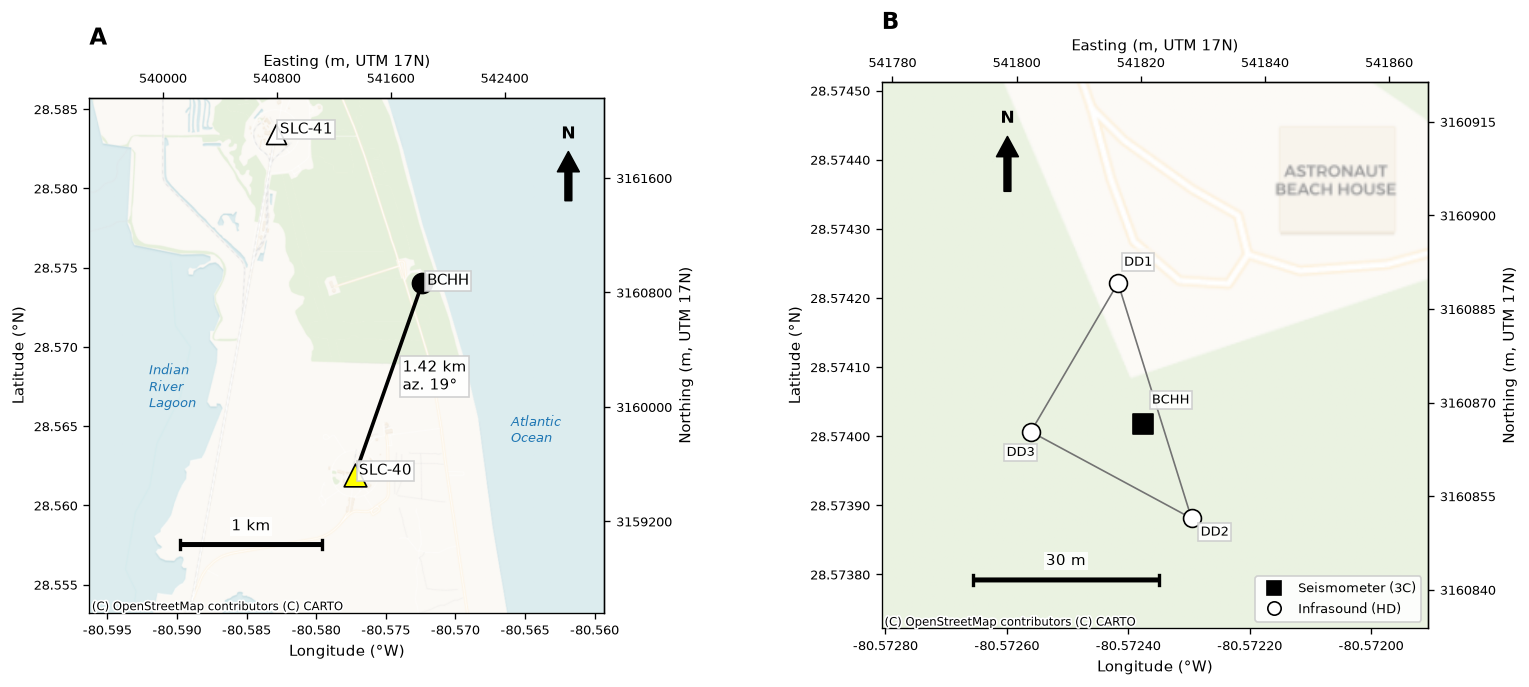

In [8]:

fig1, fig1_axes = make_figure1(
    slc40=FIGURE1_SLC40,
    slc41=FIGURE1_SLC41,
    bchh=FIGURE1_BCHH,
    bchh_sensors=FIGURE1_BCHH_SENSORS,
    geod=FIGURE1_GEOD,
    ll_to_utm=FIGURE1_LL_TO_UTM,
    utm_to_ll=FIGURE1_UTM_TO_LL,
)

plt.show()


In [9]:

figure1_output_paths = save_figure(
    fig=fig1,
    output_directory=OUTDIR,
    filename_stem=FIGURE1_STEM,
    extensions=("pdf",),
    dpi=300,
)

for path in figure1_output_paths:
    print(path.resolve())


/Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/170_generate_publication_figures/fig01_slc40_bchh_location.pdf


## 3. Receiver-specific acoustic propagation

BCHH geometry and the adopted effective acoustic speed come directly from
Notebooks 02, 03, and 08. Camera distances are computed from the canonical
SLC-40 coordinate and KML camera coordinates.


In [10]:
# BCHH propagation uses the meteorological path-effective speed from Notebook 03.
bchh_channels_df["effective_sound_speed_mps"] = ADOPTED_ACOUSTIC_SPEED_MPS
bchh_channels_df["acoustic_travel_time_s"] = (
    bchh_channels_df["distance_m"] / ADOPTED_ACOUSTIC_SPEED_MPS
)
bchh_channels_df["shockwave_travel_time_s"] = (
    bchh_channels_df["acoustic_travel_time_s"]
)

# Camera paths have different azimuths and therefore different wind projections.
if not camera_locations_df.empty:
    camera_locations_df["wind_along_ray_mps"] = (
        WindSpeedMps
        * np.cos(
            np.deg2rad(
                camera_locations_df["ray_azimuth_deg"] - WindDirectionToDeg
            )
        )
    )
    camera_locations_df["effective_sound_speed_mps"] = (
        STILL_AIR_SOUND_SPEED_MPS
        + camera_locations_df["wind_along_ray_mps"]
    )
    camera_locations_df["acoustic_travel_time_s"] = (
        camera_locations_df["distance_m"]
        / camera_locations_df["effective_sound_speed_mps"]
    )
    camera_locations_df["shockwave_travel_time_s"] = (
        camera_locations_df["acoustic_travel_time_s"]
    )

SENSOR_ACOUSTIC_TRAVEL_TIMES_S = (
    bchh_channels_df
    .set_index("channel")["acoustic_travel_time_s"]
    .to_dict()
)
SENSOR_SHOCKWAVE_TRAVEL_TIMES_S = dict(SENSOR_ACOUSTIC_TRAVEL_TIMES_S)
CAMERA_DISTANCES_M = (
    camera_locations_df.set_index("camera_id")["distance_m"].to_dict()
    if not camera_locations_df.empty else {}
)
CAMERA_EFFECTIVE_SPEEDS_MPS = (
    camera_locations_df
    .set_index("camera_id")["effective_sound_speed_mps"]
    .to_dict()
    if not camera_locations_df.empty else {}
)
CAMERA_ACOUSTIC_TRAVEL_TIMES_S = (
    camera_locations_df
    .set_index("camera_id")["acoustic_travel_time_s"]
    .to_dict()
    if not camera_locations_df.empty else {}
)
CAMERA_SHOCKWAVE_TRAVEL_TIMES_S = dict(CAMERA_ACOUSTIC_TRAVEL_TIMES_S)

ACOUSTIC_SPEED_MPS = ADOPTED_ACOUSTIC_SPEED_MPS
WIND_SPEED_MPS = WindSpeedMps
SHOCK_SPEED_MPS = ADOPTED_ACOUSTIC_SPEED_MPS

display(bchh_channels_df[[
    "channel",
    "distance_m",
    "back_azimuth_to_slc40_deg",
    "effective_sound_speed_mps",
    "acoustic_travel_time_s",
]])
if not camera_locations_df.empty:
    display(camera_locations_df[[
        "camera_id",
        "name",
        "distance_m",
        "ray_azimuth_deg",
        "wind_along_ray_mps",
        "effective_sound_speed_mps",
        "acoustic_travel_time_s",
    ]])


,channel,distance_m,back_azimuth_to_slc40_deg,effective_sound_speed_mps,acoustic_travel_time_s
0,DD1,1439.963831,198.988027,351.0,4.102461
1,DD2,1408.338457,199.943252,351.0,4.012360
2,DD3,1412.854330,198.763913,351.0,4.025226
3,DHE,1419.886511,199.438026,351.0,4.045261
4,DHN,1419.886511,199.438026,351.0,4.045261
5,DHZ,1419.886511,199.438026,351.0,4.045261


,camera_id,name,distance_m,ray_azimuth_deg,wind_along_ray_mps,effective_sound_speed_mps,acoustic_travel_time_s
0,youtube,FIREY,4254.532067,253.676701,1.471983,349.801563,12.162702
1,pad_nw,PadNW,102.864227,319.923729,4.549156,352.878735,0.291500
2,pad_west,PadW,134.745638,280.624512,3.270974,351.600553,0.383235
3,pad_ne,PadNE,70.670423,44.172628,0.847620,349.177200,0.202391
4,ucs3,UCS-3,1501.050255,13.445065,3.021181,351.350760,4.272227


## 4. Load the canonical Notebook 02 waveform product

The figure notebook uses the response-corrected Stream with the adopted
moving-median correction already applied to DD1–DD3. Seismic D* channels are
unchanged by that correction.


In [11]:
st_corr = read(
    str(BASELINE_STREAM_FILE),
    format="PICKLE",
)
st_corr.trim(
    EXPLOSION_TIME - PRE_EVENT_SEC,
    EXPLOSION_TIME + POST_EVENT_SEC,
    pad=False,
)
st_corr.sort(keys=["station", "channel"])

loaded_channels = {
    trace.stats.channel
    for trace in st_corr
}
missing_channels = set(CHANNEL_ORDER) - loaded_channels
if missing_channels:
    raise KeyError(
        f"Notebook 02 baseline Stream lacks channels: {sorted(missing_channels)}"
    )

print(f"Loaded canonical waveform product:\n  {BASELINE_STREAM_FILE}")
print(st_corr)
for trace in st_corr:
    print(
        trace.id,
        trace.stats.starttime,
        trace.stats.endtime,
        trace.stats.sampling_rate,
        trace.stats.npts,
        trace.stats.get("units", "units not stored"),
    )

if CORRECTION_SUMMARY_FILE.exists():
    correction_summary_df = pd.read_csv(CORRECTION_SUMMARY_FILE)
    display(correction_summary_df)
else:
    correction_summary_df = None


Loaded canonical waveform product:
  /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/010_prepare_analysis_inputs/bchh_corrected_moving_median_baseline_removed.pkl
6 Trace(s) in Stream:
1R.BCHH.10.DD1 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:11.912000Z | 250.0 Hz, 494959 samples
1R.BCHH.10.DD2 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:11.912000Z | 250.0 Hz, 494959 samples
1R.BCHH.10.DD3 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:11.912000Z | 250.0 Hz, 494959 samples
1R.BCHH.10.DHE | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:11.912000Z | 250.0 Hz, 494959 samples
1R.BCHH.10.DHN | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:11.912000Z | 250.0 Hz, 494959 samples
1R.BCHH.10.DHZ | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:11.912000Z | 250.0 Hz, 494959 samples
1R.BCHH.10.DD1 2016-09-01T13:04:12.080000Z 2016-09-01T13:37:11.912000Z 250.0 494959 Pa
1R.BCHH.10.DD2 2016-09-01T13:04:12.080000Z 2016-

,seed_id,network,station,location,channel,latitude,longitude,elevation_m,depth_m,azimuth_deg,...,raw_counts_rms,corrected_npts,corrected_finite_npts,corrected_minimum,corrected_maximum,corrected_peak_absolute,corrected_mean,corrected_median,corrected_standard_deviation,corrected_rms
0,1R.BCHH.10.DD1,1R,BCHH,10,DD1,28.574222,-80.572417,0.0,0.0,0.0,...,371941.875867,494959,494959,-253.017929,1349.141488,1349.141488,5.759260e-03,-4.147836e-01,33.066433,33.066433
1,1R.BCHH.10.DD2,1R,BCHH,10,DD2,28.573881,-80.572296,0.0,0.0,90.0,...,1723.106421,494959,494959,-219.103737,1557.411627,1557.411627,4.224622e-03,-4.240241e-02,7.851059,7.851060
2,1R.BCHH.10.DD3,1R,BCHH,10,DD3,28.574006,-80.572560,0.0,0.0,0.0,...,21436.580227,494959,494959,-222.554265,1434.860925,1434.860925,2.320425e-03,1.220304e+00,13.326394,13.326395
3,1R.BCHH.10.DHE,1R,BCHH,10,DHE,28.574017,-80.572376,0.0,0.0,90.0,...,4292.888830,494959,494959,-0.001094,0.001004,0.001094,1.705370e-12,-1.168159e-09,0.000013,0.000013
4,1R.BCHH.10.DHN,1R,BCHH,10,DHN,28.574017,-80.572376,0.0,0.0,0.0,...,6547.121321,494959,494959,-0.002207,0.001867,0.002207,-3.898675e-12,-1.079728e-11,0.000022,0.000022
5,1R.BCHH.10.DHZ,1R,BCHH,10,DHZ,28.574017,-80.572376,0.0,0.0,0.0,...,13989.037234,494959,494959,-0.002876,0.002173,0.002876,-8.093430e-15,-2.073428e-09,0.000033,0.000033


## 5. Channel-type helpers

Instrument-response removal has already been completed. These helpers are retained only because the plotting and display-preprocessing functions use them to apply channel-specific filters and labels.


In [12]:
def is_seismic_channel(channel: str) -> bool:
    """Return True for the BCHH high-gain seismic channels."""
    channel = channel.upper()
    return len(channel) >= 2 and channel[1] in {"H", "L"}


def is_infrasound_channel(channel: str) -> bool:
    """Return True for the BCHH pressure channels."""
    channel = channel.upper()
    return len(channel) >= 2 and channel[1] == "D"


def is_audio_channel(channel: str) -> bool:
    """Return True for imported video/audio waveform channels."""
    return channel.upper() in {"AUD", "AUDIO"}


## 6. Generic plotting and preprocessing utilities

ZEROPHASE filters can still introduce phase/group delay, so pick timing should be checked against minimally processed traces as well.


In [13]:
def trace_time_array_datetime64(tr):
    """Return matplotlib date numbers for all samples in a trace."""
    t0 = tr.stats.starttime.datetime
    sr = float(tr.stats.sampling_rate)
    seconds = np.arange(tr.stats.npts, dtype=float) / sr
    return mdates.date2num(t0) + seconds / 86400.0


def robust_scale(data, percentile=99.3):
    """Robust absolute-amplitude scale for display."""
    x = np.asarray(data, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return 1.0
    s = np.percentile(np.abs(x), percentile)
    return s if np.isfinite(s) and s > 0 else 1.0


def select_channels_in_order(st: Stream, channel_order) -> Stream:
    """Return a stream containing the first matching trace for each requested channel."""
    selected = Stream()
    for ch in channel_order:
        matches = st.select(channel=ch)
        if len(matches) == 0:
            matches = Stream([tr for tr in st if tr.stats.channel.upper() == ch.upper()])
        if len(matches):
            selected += matches[0].copy()
        else:
            warnings.warn(f'No trace found for channel {ch}')
    return selected


def preprocess_display_stream(
    st: Stream,
    starttime: UTCDateTime | None = None,
    endtime: UTCDateTime | None = None,
    infra_filter: dict | None = None,
    seis_filter: dict | None = None,
) -> Stream:
    """Trim, detrend, taper, and filter a stream for display only."""
    out = Stream()
    for tr0 in st:
        tr = tr0.copy()
        if starttime is not None and endtime is not None:
            tr.trim(starttime, endtime, pad=True, fill_value=0.0)
        tr.detrend('demean')
        tr.detrend('linear')
        tr.taper(max_percentage=0.005)

        ch = tr.stats.channel.upper()
        if is_infrasound_channel(ch) and infra_filter is not None:
            tr.filter(**infra_filter)
        elif is_seismic_channel(ch) and seis_filter is not None:
            tr.filter(**seis_filter)

        out += tr
    return out


def acoustic_or_seismic_delay_s(
    channel: str,
    distance_m: float,
    acoustic_speed_mps: float,
    direct_seismic_speed_mps: float,
    hh_use_direct_seismic_speed: bool,
) -> float:
    """Return the travel-time correction for one physical BCHH channel."""
    ch = channel.upper()
    if is_audio_channel(ch):
        return 0.0
    if is_infrasound_channel(ch):
        return distance_m / acoustic_speed_mps
    if is_seismic_channel(ch):
        speed = direct_seismic_speed_mps if hh_use_direct_seismic_speed else acoustic_speed_mps
        return distance_m / speed
    return 0.0


def reduce_stream_to_source_time_physical(
    st: Stream,
    sensor_distances_m: dict,
    acoustic_speed_mps: float,
    direct_seismic_speed_mps: float,
    hh_use_direct_seismic_speed: bool,
    audio_delay_s: float,
) -> Stream:
    """Shift each trace earlier by its assumed source-to-receiver travel time."""
    st_red = st.copy()

    for tr in st_red:
        ch = tr.stats.channel.upper()

        if is_audio_channel(ch):
            delay_s = audio_delay_s
        elif ch in sensor_distances_m:
            delay_s = acoustic_or_seismic_delay_s(
                ch,
                distance_m=sensor_distances_m[ch],
                acoustic_speed_mps=acoustic_speed_mps,
                direct_seismic_speed_mps=direct_seismic_speed_mps,
                hh_use_direct_seismic_speed=hh_use_direct_seismic_speed,
            )
        else:
            delay_s = 0.0

        print(f"Reducing {tr.id} by {delay_s:.4f} s")
        tr.stats.starttime -= delay_s
        tr.stats.processing = tr.stats.get("processing", [])
        tr.stats.processing.append(f"reduced_time_shift_minus_{delay_s:.4f}_s")

    return st_red


def zerophase_tag(zerophase: bool) -> str:
    """Short filename tag for the filter phase convention."""
    return "zp_true" if bool(zerophase) else "zp_false"


def add_zerophase_tag(outfile_base: Path, zerophase: bool) -> Path:
    """Append the zerophase convention to an output filename stem."""
    return outfile_base.with_name(f"{outfile_base.name}_{zerophase_tag(zerophase)}")


def bandpass_filter_dict(freqmin, freqmax, corners=4, zerophase=False):
    """Build an ObsPy bandpass filter dictionary with explicit zerophase."""
    return {
        "type": "bandpass",
        "freqmin": float(freqmin),
        "freqmax": float(freqmax),
        "corners": int(corners),
        "zerophase": bool(zerophase),
    }


## 7. Build the response-corrected display stream


In [14]:
def build_overview_stream(
    st: Stream,
    plot_start: UTCDateTime,
    plot_end: UTCDateTime,
    zerophase: bool,
    infra_freqmin: float = 0.5,
    infra_freqmax: float = 25.0,
    seis_freqmin: float = 0.5,
    seis_freqmax: float = 25.0,
    corners: int = 4,
) -> Stream:
    """Build the filtered 30-minute display stream for one zerophase setting."""
    overview_infra_filter = bandpass_filter_dict(
        freqmin=infra_freqmin,
        freqmax=infra_freqmax,
        corners=corners,
        zerophase=zerophase,
    )
    overview_seis_filter = bandpass_filter_dict(
        freqmin=seis_freqmin,
        freqmax=seis_freqmax,
        corners=corners,
        zerophase=zerophase,
    )

    return preprocess_display_stream(
        st,
        starttime=plot_start,
        endtime=plot_end,
        infra_filter=overview_infra_filter,
        seis_filter=overview_seis_filter,
    )


st_ordered = select_channels_in_order(st_corr, CHANNEL_ORDER)
st_overview = build_overview_stream(
    st=st_ordered,
    plot_start=PLOT_START,
    plot_end=PLOT_END,
    zerophase=ZEROPHASE,
)

print(f"Overview stream built with ZEROPHASE={ZEROPHASE}")
print(st_overview)


Overview stream built with ZEROPHASE=True
6 Trace(s) in Stream:
1R.BCHH.10.DD1 | 2016-09-01T13:04:41.912000Z - 2016-09-01T13:37:11.912000Z | 250.0 Hz, 487501 samples
1R.BCHH.10.DD2 | 2016-09-01T13:04:41.912000Z - 2016-09-01T13:37:11.912000Z | 250.0 Hz, 487501 samples
1R.BCHH.10.DD3 | 2016-09-01T13:04:41.912000Z - 2016-09-01T13:37:11.912000Z | 250.0 Hz, 487501 samples
1R.BCHH.10.DHE | 2016-09-01T13:04:41.912000Z - 2016-09-01T13:37:11.912000Z | 250.0 Hz, 487501 samples
1R.BCHH.10.DHN | 2016-09-01T13:04:41.912000Z - 2016-09-01T13:37:11.912000Z | 250.0 Hz, 487501 samples
1R.BCHH.10.DHZ | 2016-09-01T13:04:41.912000Z - 2016-09-01T13:37:11.912000Z | 250.0 Hz, 487501 samples


## 8. Figure 2: 30-minute overview figure


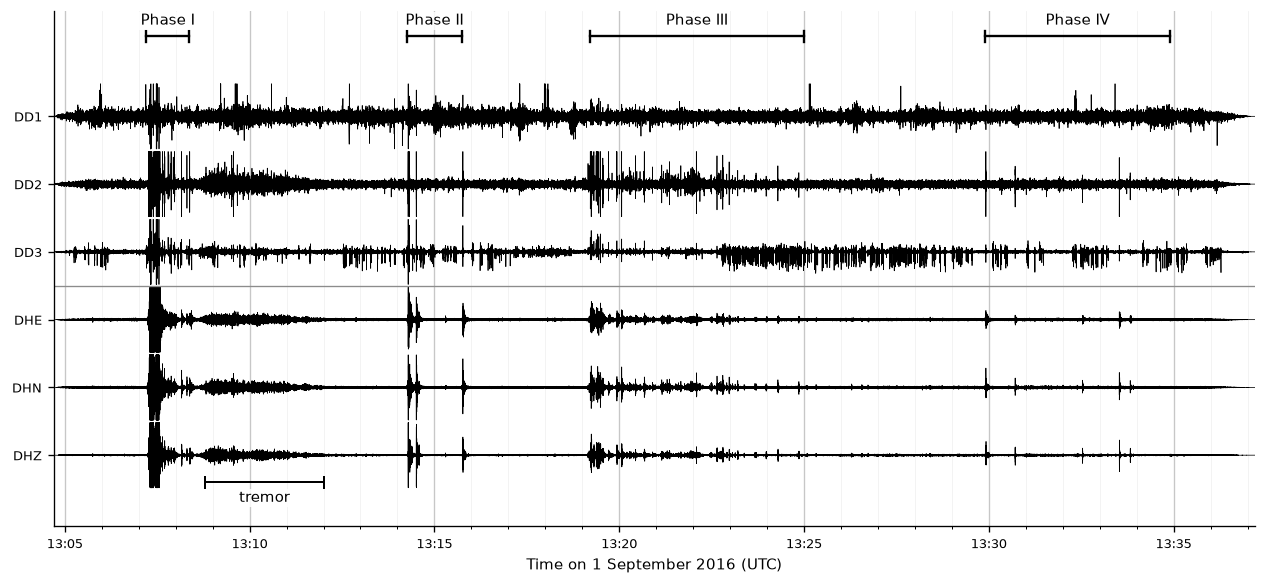

In [15]:
def add_time_bar(ax, t0, t1, y, text, above=True, lw=1.4, fontsize=9):
    """Draw a bracket-style time interval annotation."""
    x0 = mdates.date2num(t0.datetime)
    x1 = mdates.date2num(t1.datetime)

    ax.plot([x0, x1], [y, y], color="black", lw=lw, clip_on=False, zorder=20)
    tick = 0.08
    ax.plot([x0, x0], [y - tick, y + tick], color="black", lw=lw, clip_on=False, zorder=20)
    ax.plot([x1, x1], [y - tick, y + tick], color="black", lw=lw, clip_on=False, zorder=20)

    dy = 0.12 if above else -0.12
    va = "bottom" if above else "top"
    ax.text(
        (x0 + x1) / 2,
        y + dy,
        text,
        ha="center",
        va=va,
        fontsize=fontsize,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=1.0),
        clip_on=False,
        zorder=25,
    )


def make_overview_figure(
    st: Stream,
    outfile_base: Path,
    plot_start: UTCDateTime,
    plot_end: UTCDateTime,
    phases: list,
    explosion_time: UTCDateTime,
    tremor_start: UTCDateTime | None = None,
    tremor_end: UTCDateTime | None = None,
    normalize_by_group: bool = False,
    clip: float = 3.0,
    trace_gain: float = 0.15,
):
    """Make the 30-minute BCHH overview figure."""
    n = len(st)
    if n == 0:
        raise ValueError("No traces to plot")

    fig, ax = plt.subplots(figsize=(11.0, 5.8))
    offsets = np.arange(n)[::-1].astype(float)
    channel_labels = []

    infra_scales = [robust_scale(tr.data) for tr in st if is_infrasound_channel(tr.stats.channel)]
    seis_scales = [robust_scale(tr.data) for tr in st if is_seismic_channel(tr.stats.channel)]
    group_scale_infra = np.median(infra_scales) if infra_scales else 1.0
    group_scale_seis = np.median(seis_scales) if seis_scales else 1.0

    for i, tr in enumerate(st):
        y0 = offsets[i]
        ch = tr.stats.channel.upper()
        t = trace_time_array_datetime64(tr)
        data = np.nan_to_num(tr.data.astype(float), nan=0.0, posinf=0.0, neginf=0.0)

        if normalize_by_group:
            scale = group_scale_infra if is_infrasound_channel(ch) else group_scale_seis
        else:
            scale = robust_scale(data, percentile=99.3)

        y = y0 + np.clip(data / scale, -clip, clip) * trace_gain
        ax.plot(t, y, '-', color='black', lw=0.45, rasterized=True)
        channel_labels.append(ch)

    ax.set_yticks(offsets)
    ax.set_yticklabels(channel_labels)
    ax.set_ylim(-1.05, n + 0.55)
    ax.set_xlim(mdates.date2num(plot_start.datetime), mdates.date2num(plot_end.datetime))

    ax.xaxis.set_major_locator(mdates.MinuteLocator(byminute=range(0, 60, 5)))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.xaxis.set_minor_locator(mdates.MinuteLocator(interval=1))
    ax.grid(axis='x', which='major', color='0.78', lw=0.8)
    ax.grid(axis='x', which='minor', color='0.93', lw=0.4)
    ax.set_xlabel('Time on 1 September 2016 (UTC)')

    # Separator between infrasound and seismic channels for default 3+3 order.
    if n >= 6:
        ax.axhline(2.5, color='0.55', lw=0.8)

    phase_y = n + 0.18
    for name, t0, t1 in phases:
        if name.strip().lower() == 'phase i':
            t0 = explosion_time
        if t1 < plot_start or t0 > plot_end:
            continue
        add_time_bar(ax, max(t0, plot_start), min(t1, plot_end), phase_y, name, above=True)

    if tremor_start is not None and tremor_end is not None:
        if tremor_end >= plot_start and tremor_start <= plot_end:
            add_time_bar(
                ax,
                max(tremor_start, plot_start),
                min(tremor_end, plot_end),
                y=-0.4,
                text='tremor',
                above=False,
                lw=1.2,
            )

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    fig.subplots_adjust(left=0.08, right=0.99, top=0.88, bottom=0.14)

    fig.savefig(outfile_base.with_suffix('.pdf'), dpi=300, bbox_inches='tight', pad_inches=0.04)

    return fig, ax


overview_outfile = add_zerophase_tag(
    OUTDIR / 'fig03_bchh_30min_overview',
    ZEROPHASE,
)

fig, ax = make_overview_figure(
    st_overview,
    overview_outfile,
    PLOT_START,
    PLOT_END,
    phases=PHASES,
    explosion_time=EXPLOSION_TIME,
    tremor_start=TREMOR_START,
    tremor_end=TREMOR_END,
    normalize_by_group=False,
    clip=3.0,
    trace_gain=0.16,
)
plt.show()


## 9. Quick amplitude diagnostic

Use this to sanity-check response-corrected amplitudes before using the figures in the manuscript.


In [16]:
rows = []
for tr in st_ordered:
    x = np.asarray(tr.data, dtype=float)
    rows.append({
        'id': tr.id,
        'channel': tr.stats.channel,
        'units': getattr(tr.stats, 'units', ''),
        'sampling_rate': tr.stats.sampling_rate,
        'min': float(np.nanmin(x)),
        'max': float(np.nanmax(x)),
        'p99_abs': float(np.nanpercentile(np.abs(x), 99)),
        'p99_9_abs': float(np.nanpercentile(np.abs(x), 99.9)),
    })

try:
    import pandas as pd
    display(pd.DataFrame(rows))
except Exception:
    for r in rows:
        print(r)


,id,channel,units,sampling_rate,min,max,p99_abs,p99_9_abs
0,1R.BCHH.10.DD1,DD1,Pa,250.0,-138.805934,1301.957255,29.460973,83.426975
1,1R.BCHH.10.DD2,DD2,Pa,250.0,-163.344631,1507.523187,6.779160,35.130732
2,1R.BCHH.10.DD3,DD3,Pa,250.0,-163.765403,1385.597666,32.295513,57.070180
3,1R.BCHH.10.DHE,DHE,m/s,250.0,-0.001094,0.001004,0.000033,0.000188
4,1R.BCHH.10.DHN,DHN,m/s,250.0,-0.002207,0.001867,0.000043,0.000295
5,1R.BCHH.10.DHZ,DHZ,m/s,250.0,-0.002876,0.002173,0.000057,0.000476


## Peak and reduced-pressure measurements from Notebook 11

The authoritative numerical measurements are loaded from
`key_event_pressure_measurements.csv`. This notebook only displays them and
uses the corresponding pipeline event times to define waveform panels.


In [17]:
from collections.abc import Mapping

# Surveyed source-to-sensor distances from SLC-40.
# Update these values if the final geometry table changes.
BCHH_INFRASOUND_DISTANCES_M = {
    "DD1": 1442.2,
    "DD2": 1410.2,
    "DD3": 1414.8,
}


def _channel_code(trace) -> str:
    """Return the final channel code, e.g. DD1, from an ObsPy Trace."""
    return str(trace.stats.channel).upper()


def measure_reduced_pressures(
    st_event: Stream,
    sensor_distances_m: Mapping[str, float],
    *,
    reference_distance_m: float = 1000.0,
    event_name: str | None = None,
    #highpass: bool = False,
) -> pd.DataFrame:
    """
    Measure observed and reduced pressures from a short calibrated event stream.

    Parameters
    ----------
    st_event
        ObsPy Stream containing calibrated infrasound traces in Pa. The stream
        should already be trimmed to the desired event window.
    sensor_distances_m
        Mapping from channel code, such as ``DD1``, to source-to-sensor
        distance in metres.
    reference_distance_m
        Distance to which pressures are reduced. The default is 1000 m.
    event_name
        Optional event label added to the output table.

    Returns
    -------
    pandas.DataFrame
        One row per infrasound channel, containing observed and reduced
        positive, negative, negative-magnitude, and peak-to-peak pressures.

    Notes
    -----
    Reduced pressure is calculated assuming spherical spreading:

        p_reduced = p_observed * distance / reference_distance

    The negative pressure retains its sign. ``negative_magnitude_pa`` is also
    included for convenient comparison with the positive peak.
    """
    if reference_distance_m <= 0:
        raise ValueError("reference_distance_m must be positive.")

    if len(st_event) == 0:
        raise ValueError("st_event contains no traces.")

    rows: list[dict[str, Any]] = []
    
    st_event2 = st_event.copy()
    #if highpass:
    #    st_event2.filter('highpass', freq=5, corners=2)
    for tr in st_event2:
        channel = _channel_code(tr)

        if channel not in sensor_distances_m:
            continue

        distance_m = float(sensor_distances_m[channel])
        if not np.isfinite(distance_m) or distance_m <= 0:
            raise ValueError(
                f"Invalid source distance for {channel}: {distance_m}"
            )

        data = np.asarray(tr.data, dtype=float)
        data = data[np.isfinite(data)]

        if data.size == 0:
            raise ValueError(f"{tr.id} contains no finite samples.")

        positive_peak_pa = float(np.max(data))
        negative_peak_pa = float(np.min(data))
        negative_magnitude_pa = abs(negative_peak_pa)
        peak_to_peak_pa = positive_peak_pa - negative_peak_pa

        reduction_factor = distance_m / reference_distance_m

        rows.append(
            {
                "event": event_name,
                "id": tr.id,
                "channel": channel,
                "starttime": tr.stats.starttime,
                "endtime": tr.stats.endtime,
                "sampling_rate_hz": float(tr.stats.sampling_rate),
                "npts": int(tr.stats.npts),
                "distance_m": distance_m,
                "reference_distance_m": float(reference_distance_m),
                "reduction_factor": reduction_factor,
                "positive_peak_pa": positive_peak_pa,
                "negative_peak_pa": negative_peak_pa,
                "negative_magnitude_pa": negative_magnitude_pa,
                "peak_to_peak_pa": peak_to_peak_pa,
                "positive_reduced_pa": positive_peak_pa * reduction_factor,
                "negative_reduced_pa": negative_peak_pa * reduction_factor,
                "negative_magnitude_reduced_pa": (
                    negative_magnitude_pa * reduction_factor
                ),
                "peak_to_peak_reduced_pa": peak_to_peak_pa * reduction_factor,
            }
        )

    if not rows:
        available = sorted({_channel_code(tr) for tr in st_event})
        expected = sorted(sensor_distances_m)
        raise ValueError(
            "No traces matched the distance dictionary. "
            f"Available channels: {available}; expected channels: {expected}"
        )

    result = pd.DataFrame(rows).sort_values("channel").reset_index(drop=True)

    # Add robust three-sensor summaries as a separate final row.
    numeric_columns = [
        "distance_m",
        "reduction_factor",
        "positive_peak_pa",
        "negative_peak_pa",
        "negative_magnitude_pa",
        "peak_to_peak_pa",
        "positive_reduced_pa",
        "negative_peak_pa",
        "negative_reduced_pa",
        "negative_magnitude_reduced_pa",
        "peak_to_peak_reduced_pa",
    ]

    summary = {
        "event": event_name,
        "id": "ARRAY_MEDIAN",
        "channel": "MEDIAN",
        "starttime": result["starttime"].min(),
        "endtime": result["endtime"].max(),
        "sampling_rate_hz": result["sampling_rate_hz"].median(),
        "npts": np.nan,
        "reference_distance_m": float(reference_distance_m),
    }

    for column in dict.fromkeys(numeric_columns):
        summary[column] = result[column].median()

    result = pd.concat(
        [result, pd.DataFrame([summary])],
        ignore_index=True,
    )

    return result


def measure_reduced_pressures_in_window(
    st: Stream,
    starttime: UTCDateTime | str,
    endtime: UTCDateTime | str,
    sensor_distances_m: Mapping[str, float],
    *,
    reference_distance_m: float = 1000.0,
    event_name: str | None = None,
    nearest_sample: bool = True,
    #highpass: bool = False,
) -> tuple[Stream, pd.DataFrame]:
    """
    Trim a calibrated stream to an event window and measure reduced pressures.

    Returns both the trimmed event stream and the measurement table.
    """
    t0 = UTCDateTime(starttime)
    t1 = UTCDateTime(endtime)

    if t1 <= t0:
        raise ValueError(f"endtime must follow starttime: {t0} to {t1}")

    st_event = st.copy()
    st_event.trim(
        starttime=t0,
        endtime=t1,
        nearest_sample=nearest_sample,
        pad=False,
    )

    '''
    # Retain only infrasound channels represented in the distance dictionary.
    st_event = Stream(
        traces=[
            tr for tr in st_event
            if _channel_code(tr) in sensor_distances_m
        ]
    )
    '''

    measurements = measure_reduced_pressures(
        st_event.select(channel='HD*'),
        sensor_distances_m,
        reference_distance_m=reference_distance_m,
        event_name=event_name,
        #highpass=highpass,
    )

    return st_event, measurements


def pressure_results_for_paper(
    measurements: pd.DataFrame,
) -> pd.DataFrame:
    """Return a compact, publication-oriented view of the measurements."""
    columns = [
        "event",
        "channel",
        "distance_m",
        "positive_peak_pa",
        "negative_peak_pa",
        "peak_to_peak_pa",
        "positive_reduced_pa",
        "negative_reduced_pa",
        "peak_to_peak_reduced_pa",
    ]

    output = measurements.loc[:, columns].copy()

    pressure_columns = [
        "positive_peak_pa",
        "negative_peak_pa",
        "peak_to_peak_pa",
        "positive_reduced_pa",
        "negative_reduced_pa",
        "peak_to_peak_reduced_pa",
    ]

    output["distance_m"] = output["distance_m"].round(1)
    output[pressure_columns] = output[pressure_columns].round(1)

    return output

In [18]:
print(st_corr)

6 Trace(s) in Stream:
1R.BCHH.10.DD1 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:11.912000Z | 250.0 Hz, 494959 samples
1R.BCHH.10.DD2 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:11.912000Z | 250.0 Hz, 494959 samples
1R.BCHH.10.DD3 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:11.912000Z | 250.0 Hz, 494959 samples
1R.BCHH.10.DHE | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:11.912000Z | 250.0 Hz, 494959 samples
1R.BCHH.10.DHN | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:11.912000Z | 250.0 Hz, 494959 samples
1R.BCHH.10.DHZ | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:11.912000Z | 250.0 Hz, 494959 samples


In [19]:
if key_event_pressures.empty:
    warnings.warn(
        f"Notebook 11 pressure measurements not found: "
        f"{KEY_EVENT_PRESSURES_FILE}"
    )
else:
    print("Authoritative Notebook 11 key-event measurements:")
    display(key_event_pressures)

if key_event_windows.empty:
    warnings.warn(
        f"Notebook 11 measurement windows not found: "
        f"{KEY_EVENT_WINDOWS_FILE}"
    )
else:
    print("Authoritative Notebook 11 measurement windows:")
    display(key_event_windows)


Authoritative Notebook 11 key-event measurements:


,event,id,channel,distance_m,baseline_pa,positive_peak_time_s,negative_peak_time_s,positive_peak_pa,negative_peak_pa,peak_to_peak_pa,positive_reduced_pa,negative_reduced_pa,peak_to_peak_reduced_pa
0,Initial second-stage failure,1R.BCHH.10.DD1,DD1,1439.963831,9.656469,1.020,0.864,30.387552,-72.234297,102.621850,43.756976,-104.014775,147.771752
1,Initial second-stage failure,1R.BCHH.10.DD2,DD2,1408.338457,0.152385,0.932,1.180,51.690353,-25.419443,77.109797,72.797513,-35.799180,108.596692
2,Initial second-stage failure,1R.BCHH.10.DD3,DD3,1412.854330,0.028138,1.296,1.192,38.843842,-21.233191,60.077033,54.880690,-29.999406,84.880097
3,Initial second-stage failure,ARRAY_MEDIAN,MEDIAN,1412.854330,0.152385,NaN,NaN,38.843842,-25.419443,77.109797,54.880690,-35.799180,108.596692
4,Principal explosion,1R.BCHH.10.DD1,DD1,1439.963831,-7.158443,1.456,1.892,1309.115699,-130.805838,1439.921537,1885.079256,-188.355675,2073.434931
5,Principal explosion,1R.BCHH.10.DD2,DD2,1408.338457,-4.883605,1.368,1.680,1512.406792,-158.461026,1670.867817,2129.980647,-223.166756,2353.147403
6,Principal explosion,1R.BCHH.10.DD3,DD3,1412.854330,-6.731183,1.380,1.820,1392.328849,-157.034220,1549.363069,1967.157844,-221.866478,2189.024322
7,Principal explosion,ARRAY_MEDIAN,MEDIAN,1412.854330,-6.731183,NaN,NaN,1392.328849,-157.034220,1549.363069,1967.157844,-221.866478,2189.024322
8,Payload impact,1R.BCHH.10.DD1,DD1,1439.963831,23.387006,0.200,0.244,225.788003,-128.053453,353.841456,325.126558,-184.392340,509.518898
9,Payload impact,1R.BCHH.10.DD2,DD2,1408.338457,-3.182755,0.112,0.156,279.145109,-115.324633,394.469742,393.130792,-162.416115,555.546908


Authoritative Notebook 11 measurement windows:


,event,source_event_key,source_time_utc,source_time_epoch_s,arrival_reference_channel,arrival_reference_distance_m,acoustic_propagation_speed_mps,predicted_reference_travel_time_s,predicted_reference_arrival_utc,predicted_reference_arrival_epoch_s,...,window_start_epoch_s,window_end_epoch_s,window_duration_s,baseline_start_s,baseline_end_s,signal_start_s,signal_end_s,pressure_reduction_reference_distance_m,waveform_product,geometry_product
0,Initial second-stage failure,upper_stage,2016-09-01T13:07:11.913000,1.472735e+09,DD2,1408.338457,351.0,4.01236,2016-09-01T13:07:15.925360,1.472735e+09,...,1.472735e+09,1.472735e+09,2.00,0.1,0.80,0.85,1.40,1000.0,/Users/thompsong/Developer/KSCRocketSeismology...,/Users/thompsong/Developer/KSCRocketSeismology...
1,Principal explosion,lower_stage,2016-09-01T13:07:15.513600,1.472735e+09,DD2,1408.338457,351.0,4.01236,2016-09-01T13:07:19.525960,1.472735e+09,...,1.472735e+09,1.472735e+09,3.00,0.1,0.75,0.75,2.50,1000.0,/Users/thompsong/Developer/KSCRocketSeismology...,/Users/thompsong/Developer/KSCRocketSeismology...
2,Payload impact,payload_impact,2016-09-01T13:07:24.420000,1.472735e+09,DD2,1408.338457,351.0,4.01236,2016-09-01T13:07:28.432360,1.472735e+09,...,1.472735e+09,1.472735e+09,0.45,0.0,0.07,0.08,0.45,1000.0,/Users/thompsong/Developer/KSCRocketSeismology...,/Users/thompsong/Developer/KSCRocketSeismology...
3,Payload explosion,payload_explosion,2016-09-01T13:07:24.987500,1.472735e+09,DD2,1408.338457,351.0,4.01236,2016-09-01T13:07:28.999860,1.472735e+09,...,1.472735e+09,1.472735e+09,0.40,0.0,0.10,0.10,0.40,1000.0,/Users/thompsong/Developer/KSCRocketSeismology...,/Users/thompsong/Developer/KSCRocketSeismology...


In [20]:

from collections.abc import Mapping

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator
from obspy import Stream, UTCDateTime


def plot_main_explosion(
    st_event: Stream,
    *,
    reference_time: UTCDateTime | str,
    pressure_results=None,
    title: str = "Principal explosion",
    seismic_channels: tuple[str, ...] = ("DHZ", "DHN", "DHE"),
    infrasound_channels: tuple[str, ...] = ("DD1", "DD2", "DD3"),
    seismic_labels: Mapping[str, str] | None = None,
    infrasound_labels: Mapping[str, str] | None = None,
    figsize: tuple[float, float] = (11.5, 6.8),
    outfile=None,
    add_measurements=False,
):
    """
    Plot the principal explosion as grouped seismic and infrasound panels.

    Parameters
    ----------
    st_event
        Response-corrected event stream. Seismic traces must be in m/s and
        infrasound traces in Pa.
    reference_time
        Time used for the relative x-axis.
    pressure_results
        Optional DataFrame returned by the pressure measurement function.
        When supplied, positive and negative pressure extrema are marked.
    title
        Figure title.
    outfile
        Optional output path. If supplied, the figure is saved.
    """
    reference_time = UTCDateTime(reference_time)

    if seismic_labels is None:
        seismic_labels = {
            "DHZ": "Vertical",
            "DHN": "North",
            "DHE": "East",
        }

    if infrasound_labels is None:
        infrasound_labels = {
            "DD1": "DD1",
            "DD2": "DD2",
            "DD3": "DD3",
        }

    seismic_traces = []
    for channel in seismic_channels:
        matches = st_event.select(channel=channel)
        if len(matches) != 1:
            raise ValueError(
                f"Expected one {channel} trace, found {len(matches)}."
            )
        seismic_traces.append(matches[0])

    pressure_traces = []
    for channel in infrasound_channels:
        matches = st_event.select(channel=channel)
        if len(matches) != 1:
            raise ValueError(
                f"Expected one {channel} trace, found {len(matches)}."
            )
        pressure_traces.append(matches[0])

    fig = plt.figure(figsize=figsize, constrained_layout=True)
    grid = fig.add_gridspec(
        nrows=3,
        ncols=2,
        width_ratios=(1.0, 1.25),
        wspace=0.08,
        hspace=0.05,
    )

    seismic_axes = [
        fig.add_subplot(grid[row, 0])
        for row in range(3)
    ]

    pressure_axes = [
        fig.add_subplot(grid[row, 1])
        for row in range(3)
    ]

    # Determine common limits within each instrument group.
    seismic_limit = max(
        np.nanmax(np.abs(np.asarray(tr.data, dtype=float)))
        for tr in seismic_traces
    )
    seismic_limit *= 1.08

    pressure_min = min(
        np.nanmin(np.asarray(tr.data, dtype=float))
        for tr in pressure_traces
    )
    pressure_max = max(
        np.nanmax(np.asarray(tr.data, dtype=float))
        for tr in pressure_traces
    )

    pressure_padding = 0.05 * (pressure_max - pressure_min)
    pressure_ylim = (
        pressure_min - pressure_padding,
        pressure_max + pressure_padding,
    )

    # Plot seismic components.
    for index, (ax, tr) in enumerate(
        zip(seismic_axes, seismic_traces)
    ):
        channel = tr.stats.channel
        time_s = tr.times(
            reftime=reference_time
        )
        data = np.asarray(tr.data, dtype=float)

        ax.plot(time_s, data, linewidth=0.9)
        ax.axhline(0.0, linewidth=0.5, alpha=0.5)

        ax.set_ylim(-seismic_limit, seismic_limit)
        ax.yaxis.set_major_locator(MaxNLocator(nbins=4))

        ax.text(
            0.02,
            0.86,
            seismic_labels.get(channel, channel),
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=10,
            fontweight="bold",
        )

        if index < 2:
            ax.tick_params(labelbottom=False)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    # Plot infrasound channels.
    for index, (ax, tr) in enumerate(
        zip(pressure_axes, pressure_traces)
    ):
        channel = tr.stats.channel
        time_s = tr.times(
            reftime=reference_time
        )
        data = np.asarray(tr.data, dtype=float)

        ax.plot(time_s, data, linewidth=1.0)
        ax.axhline(0.0, linewidth=0.5, alpha=0.5)
        ax.set_ylim(*pressure_ylim)
        ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

        ax.text(
            0.02,
            0.86,
            infrasound_labels.get(channel, channel),
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=10,
            fontweight="bold",
        )

        # Mark positive and negative extrema.
        positive_index = int(np.nanargmax(data))
        negative_index = int(np.nanargmin(data))

        positive_time = time_s[positive_index]
        negative_time = time_s[negative_index]

        positive_value = data[positive_index]
        negative_value = data[negative_index]

        ax.scatter(
            positive_time,
            positive_value,
            s=24,
            zorder=4,
        )
        ax.scatter(
            negative_time,
            negative_value,
            s=24,
            zorder=4,
        )

        ax.annotate(
            f"{positive_value:.0f} Pa",
            xy=(positive_time, positive_value),
            xytext=(5, -16),
            textcoords="offset points",
            fontsize=8,
            ha="left",
            va="top",
        )

        ax.annotate(
            f"{negative_value:.0f} Pa",
            xy=(negative_time, negative_value),
            xytext=(5, 7),
            textcoords="offset points",
            fontsize=8,
            ha="left",
            va="bottom",
        )

        if index < 2:
            ax.tick_params(labelbottom=False)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    # Shared x limits.
    all_traces = seismic_traces + pressure_traces

    xmin = min(
        tr.stats.starttime - reference_time
        for tr in all_traces
    )
    xmax = max(
        tr.stats.endtime - reference_time
        for tr in all_traces
    )

    for ax in seismic_axes + pressure_axes:
        ax.set_xlim(xmin, xmax)
        ax.grid(axis="x", linewidth=0.4, alpha=0.3)

    seismic_axes[0].set_title(
        "Ground velocity",
        fontsize=11,
        fontweight="bold",
    )
    pressure_axes[0].set_title(
        "Acoustic pressure",
        fontsize=11,
        fontweight="bold",
    )

    seismic_axes[1].set_ylabel(
        "Ground velocity (m s$^{-1}$)"
    )
    pressure_axes[1].set_ylabel(
        "Pressure (Pa)"
    )

    seismic_axes[-1].set_xlabel(
        f"Time relative to {reference_time.strftime('%H:%M:%S.%f')[:-3]} UTC (s)"
    )
    pressure_axes[-1].set_xlabel(
        f"Time relative to {reference_time.strftime('%H:%M:%S.%f')[:-3]} UTC (s)"
    )

    fig.suptitle(
        title,
        fontsize=13,
        fontweight="bold",
    )

    if pressure_results is not None and add_measurements:
        sensor_rows = pressure_results[
            pressure_results["channel"].isin(infrasound_channels)
        ]

        if len(sensor_rows) > 0:
            median_positive = sensor_rows[
                "positive_peak_pa"
            ].median()

            median_reduced = sensor_rows[
                "positive_reduced_pa"
            ].median()

            fig.text(
                0.995,
                0.91,
                (
                    f"Median positive peak: {median_positive / 1000:.2f} kPa; "
                    f"median reduced pressure at 1 km: "
                    f"{median_reduced / 1000:.2f} kPa"
                ),
                ha="right",
                va="bottom",
                fontsize=8.5,
            )

    if outfile is not None:
        fig.savefig(
            outfile,
            dpi=300,
            bbox_inches="tight",
        )

    return fig, {
        "seismic": seismic_axes,
        "infrasound": pressure_axes,
    }

In [21]:

from collections.abc import Mapping

import numpy as np
import pandas as pd
from obspy import Stream, UTCDateTime


def measure_reduced_pressures(
    st_event: Stream,
    sensor_distances_m: Mapping[str, float],
    *,
    reference_distance_m: float = 1000.0,
    event_name: str | None = None,
    baseline_start_s: float = 0.0,
    baseline_end_s: float = 0.75,
    signal_start_s: float | None = None,
    signal_end_s: float | None = None,
) -> pd.DataFrame:
    """
    Measure locally baseline-corrected pressure amplitudes.

    Times are specified in seconds relative to the start of each trace in
    ``st_event``.

    Parameters
    ----------
    st_event
        Calibrated infrasound event stream in Pa.
    sensor_distances_m
        Mapping from channel code to source-to-sensor distance in metres.
    reference_distance_m
        Reference distance for reduced pressure.
    event_name
        Optional event label.
    baseline_start_s, baseline_end_s
        Quiet pre-event interval used to estimate the local pressure baseline.
    signal_start_s, signal_end_s
        Interval over which extrema are measured. If omitted, measurement begins
        at ``baseline_end_s`` and continues to the end of the trace.
    """
    if reference_distance_m <= 0:
        raise ValueError("reference_distance_m must be positive.")

    if baseline_end_s <= baseline_start_s:
        raise ValueError("baseline_end_s must be greater than baseline_start_s.")

    if signal_start_s is None:
        signal_start_s = baseline_end_s

    rows = []

    for tr in st_event:
        channel = str(tr.stats.channel).upper()

        if channel not in sensor_distances_m:
            continue

        data = np.asarray(tr.data, dtype=float)
        sampling_rate = float(tr.stats.sampling_rate)
        times = tr.times()

        baseline_mask = (
            (times >= baseline_start_s)
            & (times < baseline_end_s)
            & np.isfinite(data)
        )

        if not np.any(baseline_mask):
            raise ValueError(
                f"No baseline samples found for {tr.id} in "
                f"{baseline_start_s:.3f}–{baseline_end_s:.3f} s."
            )

        baseline_pa = float(np.nanmedian(data[baseline_mask]))
        corrected_data = data - baseline_pa

        signal_mask = (
            (times >= signal_start_s)
            & np.isfinite(corrected_data)
        )

        if signal_end_s is not None:
            signal_mask &= times <= signal_end_s

        if not np.any(signal_mask):
            raise ValueError(
                f"No signal samples found for {tr.id} in the requested window."
            )

        signal_data = corrected_data[signal_mask]
        signal_times = times[signal_mask]

        positive_index = int(np.nanargmax(signal_data))
        negative_index = int(np.nanargmin(signal_data))

        positive_peak_pa = float(signal_data[positive_index])
        negative_peak_pa = float(signal_data[negative_index])
        peak_to_peak_pa = positive_peak_pa - negative_peak_pa

        distance_m = float(sensor_distances_m[channel])
        reduction_factor = distance_m / reference_distance_m

        rows.append(
            {
                "event": event_name,
                "id": tr.id,
                "channel": channel,
                "distance_m": distance_m,
                "baseline_pa": baseline_pa,
                "positive_peak_time_s": float(signal_times[positive_index]),
                "negative_peak_time_s": float(signal_times[negative_index]),
                "positive_peak_pa": positive_peak_pa,
                "negative_peak_pa": negative_peak_pa,
                "peak_to_peak_pa": peak_to_peak_pa,
                "positive_reduced_pa": positive_peak_pa * reduction_factor,
                "negative_reduced_pa": negative_peak_pa * reduction_factor,
                "peak_to_peak_reduced_pa": peak_to_peak_pa * reduction_factor,
            }
        )

    if not rows:
        raise ValueError("No infrasound channels matched sensor_distances_m.")

    result = (
        pd.DataFrame(rows)
        .sort_values("channel")
        .reset_index(drop=True)
    )

    summary_columns = [
        "distance_m",
        "baseline_pa",
        "positive_peak_pa",
        "negative_peak_pa",
        "peak_to_peak_pa",
        "positive_reduced_pa",
        "negative_reduced_pa",
        "peak_to_peak_reduced_pa",
    ]

    summary = {
        "event": event_name,
        "id": "ARRAY_MEDIAN",
        "channel": "MEDIAN",
        "positive_peak_time_s": np.nan,
        "negative_peak_time_s": np.nan,
    }

    for column in summary_columns:
        summary[column] = float(result[column].median())

    return pd.concat(
        [result, pd.DataFrame([summary])],
        ignore_index=True,
    )

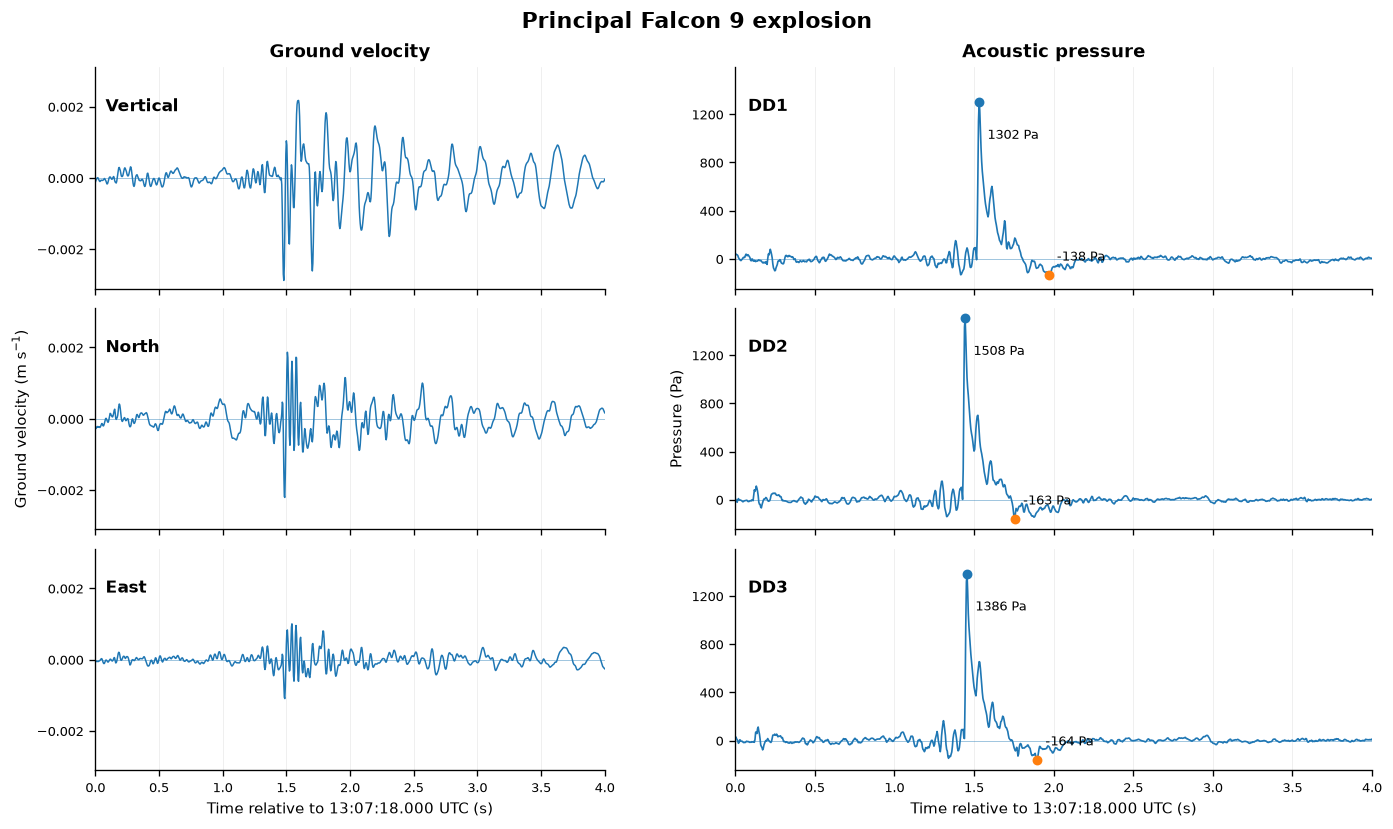

In [22]:
def floor_utc_to_second(value):
    return UTCDateTime(np.floor(float(UTCDateTime(value))))


def ceil_utc_to_second(value):
    return UTCDateTime(np.ceil(float(UTCDateTime(value))))


principal_window = key_event_window(r"principal")

MAIN_EXPLOSION_MEASUREMENT_START = principal_window["start"]
MAIN_EXPLOSION_MEASUREMENT_END = principal_window["end"]
MAIN_EXPLOSION_START = floor_utc_to_second(MAIN_EXPLOSION_MEASUREMENT_START)
MAIN_EXPLOSION_END = ceil_utc_to_second(MAIN_EXPLOSION_MEASUREMENT_END)

st_main_explosion = st_corr.copy().trim(
    MAIN_EXPLOSION_START,
    MAIN_EXPLOSION_END,
)
main_explosion_pressures = key_event_pressures.loc[
    key_event_pressures["event"]
    .astype(str)
    .str.contains("principal", case=False, na=False)
].copy()

fig, axes = plot_main_explosion(
    st_main_explosion,
    reference_time=MAIN_EXPLOSION_START,
    pressure_results=main_explosion_pressures,
    title="Principal Falcon 9 explosion",
    outfile=OUTDIR / "principal_explosion_waveforms.pdf",
)


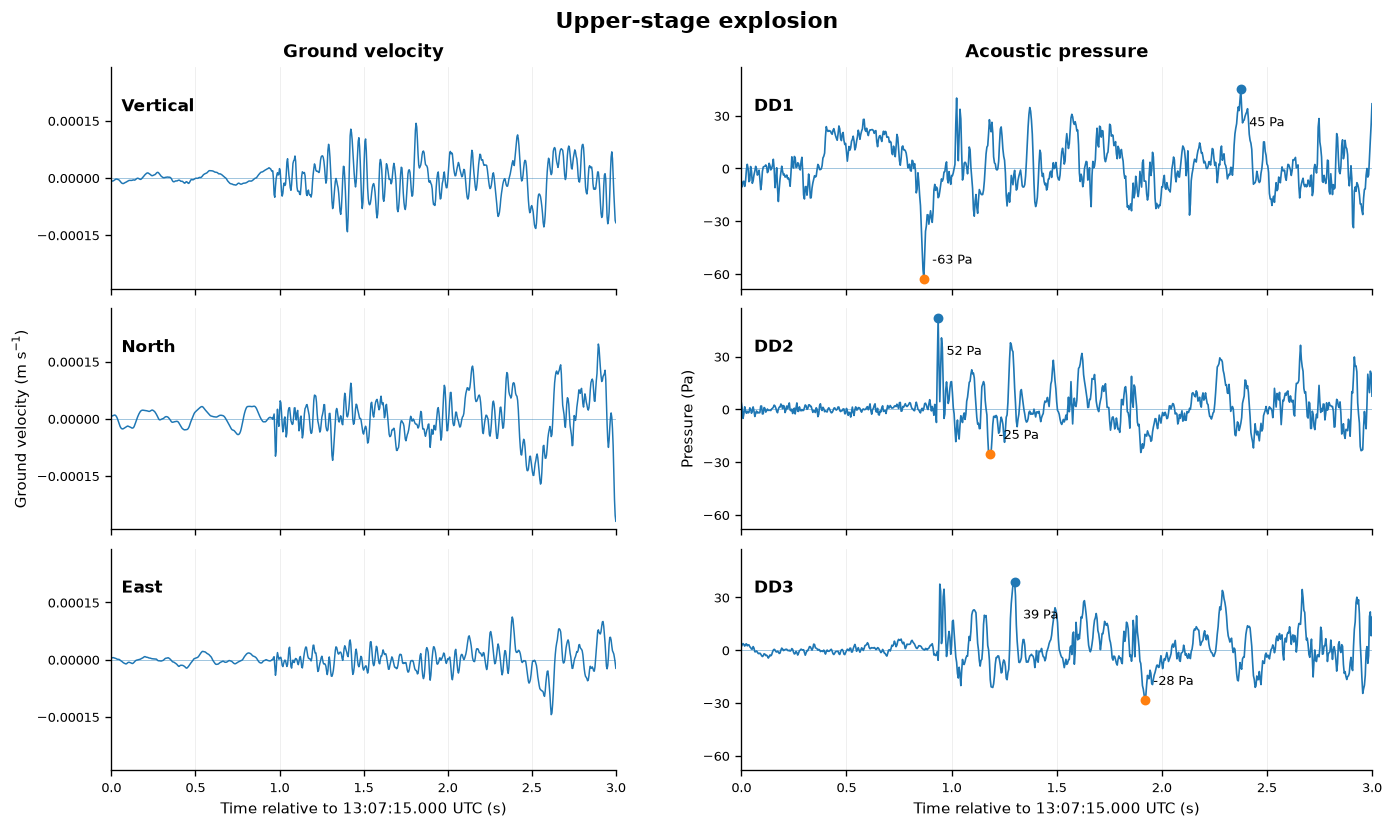

In [23]:
second_stage_window = key_event_window(
    r"upper-stage|upper stage|second-stage|second stage"
)

SECOND_STAGE_MEASUREMENT_START = second_stage_window["start"]
SECOND_STAGE_MEASUREMENT_END = second_stage_window["end"]
SECOND_STAGE_START = floor_utc_to_second(SECOND_STAGE_MEASUREMENT_START)
SECOND_STAGE_END = ceil_utc_to_second(SECOND_STAGE_MEASUREMENT_END)

st_second_stage = st_corr.copy().trim(
    SECOND_STAGE_START,
    SECOND_STAGE_END,
)
second_stage_pressures = key_event_pressures.loc[
    key_event_pressures["event"]
    .astype(str)
    .str.contains(
        "upper-stage|upper stage|second-stage|second stage",
        case=False,
        regex=True,
        na=False,
    )
].copy()

fig, axes = plot_main_explosion(
    st_second_stage,
    reference_time=SECOND_STAGE_START,
    pressure_results=second_stage_pressures,
    title="Upper-stage explosion",
    outfile=OUTDIR / "upper_stage_waveforms.pdf",
)


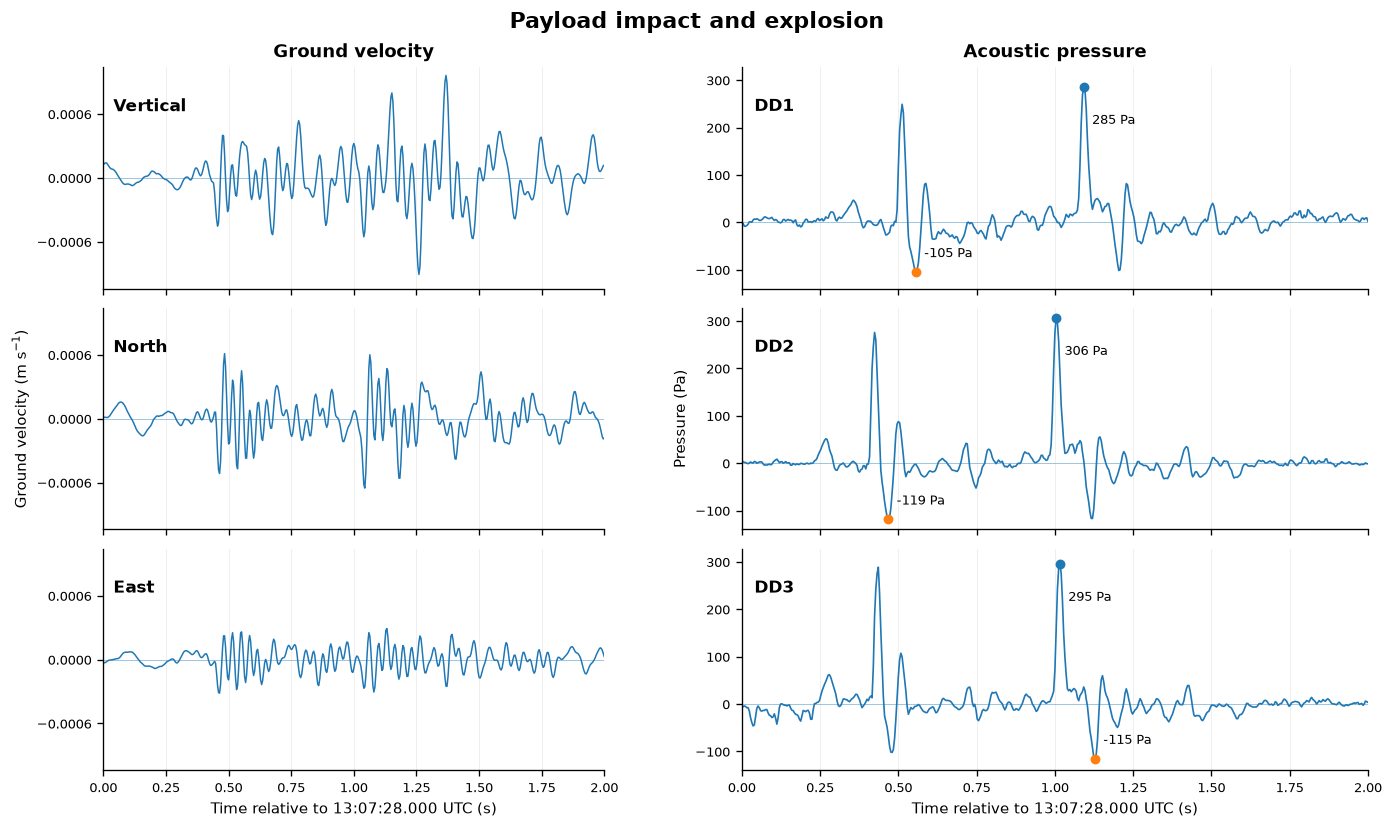

In [24]:
payload_window_rows = key_event_windows.loc[
    key_event_windows["event"]
    .astype(str)
    .str.contains("payload|capsule", case=False, regex=True, na=False)
].copy()

if payload_window_rows.empty:
    raise ValueError(
        "Notebook 11 exported no payload measurement windows"
    )

PAYLOAD_MEASUREMENT_START = UTCDateTime(
    str(payload_window_rows["window_start_utc"].min())
)
PAYLOAD_MEASUREMENT_END = UTCDateTime(
    str(payload_window_rows["window_end_utc"].max())
)
PAYLOAD_START = floor_utc_to_second(PAYLOAD_MEASUREMENT_START)
PAYLOAD_END = ceil_utc_to_second(PAYLOAD_MEASUREMENT_END)

st_payload = st_corr.copy().trim(
    PAYLOAD_START,
    PAYLOAD_END,
)
payload_pressures = key_event_pressures.loc[
    key_event_pressures["event"]
    .astype(str)
    .str.contains("payload|capsule", case=False, regex=True, na=False)
].copy()

fig, axes = plot_main_explosion(
    st_payload,
    reference_time=PAYLOAD_START,
    pressure_results=payload_pressures,
    title="Payload impact and explosion",
    outfile=OUTDIR / "payload_explosion_waveforms.pdf",
)


## 10. Load synchronized video/audio track

The audio track is treated as an approximate source-time reference, not an independent calibrated acoustic sensor. If `librosa` or the MP3 file is unavailable, the rest of the notebook still works without audio.


In [25]:
def load_video_audio_as_stream(
    audio_file: Path,
    starttime: UTCDateTime,
    network="YT",
    station="SYNC",
    channel="AUD",
) -> Stream:
    """Load a WAV/MP3 file as one ObsPy trace."""
    try:
        import librosa
    except Exception as exc:
        raise ImportError(
            "librosa is required to load synchronized video audio"
        ) from exc

    samples, sampling_rate = librosa.load(audio_file, sr=None)
    trace = Trace(data=np.asarray(samples, dtype=np.float32))
    trace.stats.sampling_rate = sampling_rate
    trace.stats.network = network
    trace.stats.station = station
    trace.stats.location = ""
    trace.stats.channel = channel
    trace.stats.starttime = starttime
    return Stream([trace])


def prepare_audio_for_plot(
    st_audio: Stream,
    zoom_start: UTCDateTime | None = None,
    zoom_end: UTCDateTime | None = None,
    freqmin: float | None = None,
    freqmax: float | None = None,
    audio_time_shift_s: float | None = None,
    demean: bool = True,
    normalize: bool = True,
    zerophase: bool = False,
    corners: int = 4,
) -> Stream:
    sta = st_audio.copy()
    for trace in sta:
        if demean:
            trace.detrend("demean")
        if freqmin is not None and freqmax is not None:
            trace.filter(
                "bandpass",
                freqmin=freqmin,
                freqmax=freqmax,
                corners=corners,
                zerophase=bool(zerophase),
            )
        if audio_time_shift_s is not None:
            trace.stats.starttime += audio_time_shift_s
        if zoom_start is not None and zoom_end is not None:
            trace.trim(zoom_start, zoom_end, pad=False)
        if normalize:
            trace.normalize()
    return sta


import subprocess

# Prefer Notebook 160's synchronized WAV, but do not require a complete
# video render merely to make static publication figures. If that WAV is
# absent, extract the authorized local source movie audio and map it
# directly into source time using the shared video anchor and the
# independently calculated SLC-40-to-camera travel time.
sync_audio_value = video_sync.get("extracted_audio_wav")
audio_candidates = []
if sync_audio_value:
    audio_candidates.append(Path(sync_audio_value).expanduser())
audio_candidates.extend([
    config.NB160_DIR / "youtube_audio_source_aligned.wav",
    config.NB160_DIR / "youtube_audio_observed_utc.wav",
    config.NB160_DIR / "youtube_audio_render_interval.wav",
])
AUDIO_FILE = next((path for path in audio_candidates if path.is_file()), None)

camera_travel_fallback_s = CAMERA_ACOUSTIC_TRAVEL_TIMES_S.get("youtube", np.nan)
AUDIO_CAMERA_TRAVEL_TIME_S = float(
    video_sync.get("youtube_camera_travel_time_s", camera_travel_fallback_s)
)
if not np.isfinite(AUDIO_CAMERA_TRAVEL_TIME_S):
    raise ValueError(
        "Cannot determine the SLC-40-to-USLaunchReport camera travel time "
        "from Notebook 160 metadata or the KML/weather calculation."
    )

st_audio_raw = Stream()
AUDIO_ALIGNMENT_MODE = video_sync.get(
    "alignment_mode", video_sync.get("audio_time_basis")
)
AUDIO_METADATA_SOURCE = None
AUDIO_NATIVE_START_PTS_S = None

if AUDIO_FILE is not None:
    filename_lower = AUDIO_FILE.name.lower()
    if AUDIO_ALIGNMENT_MODE not in {"observed_utc", "source_aligned"}:
        if "source_aligned" in filename_lower:
            AUDIO_ALIGNMENT_MODE = "source_aligned"
        elif "observed_utc" in filename_lower:
            AUDIO_ALIGNMENT_MODE = "observed_utc"
    if AUDIO_ALIGNMENT_MODE not in {"observed_utc", "source_aligned"}:
        raise ValueError(
            f"Cannot infer the timing basis of synchronized audio {AUDIO_FILE}. "
            "Rerun Notebook 160 or use a filename containing "
            "'source_aligned' or 'observed_utc'."
        )
    audio_start_value = video_sync.get(
        "audio_start_utc",
        video_sync.get("render_start_utc", str(UPPER_STAGE - 2.0)),
    )
    AUDIO_STARTTIME = UTCDateTime(str(audio_start_value))
    AUDIO_METADATA_SOURCE = "Notebook 160 synchronized-audio product"
else:
    source_video = config.USLAUNCHREPORT_VIDEO_FILE
    if source_video is None or not Path(source_video).is_file():
        warnings.warn(
            "Neither Notebook 160 synchronized audio nor the authorized "
            "local USLaunchReport movie is available; audio-dependent "
            "figures will be skipped."
        )
    else:
        AUDIO_FILE = OUTDIR / "uslaunchreport_audio_source_aligned_12khz.wav"
        probe = subprocess.run(
            [
                "ffprobe", "-v", "error", "-select_streams", "a:0",
                "-show_entries", "stream=start_time",
                "-of", "default=noprint_wrappers=1:nokey=1",
                str(source_video),
            ],
            check=True, capture_output=True, text=True,
        )
        try:
            AUDIO_NATIVE_START_PTS_S = float(probe.stdout.strip())
        except ValueError:
            AUDIO_NATIVE_START_PTS_S = 0.0
            warnings.warn(
                "ffprobe did not report an audio-stream start PTS; "
                "assuming movie audio begins at 0 s."
            )
        if not AUDIO_FILE.is_file():
            subprocess.run(
                [
                    "ffmpeg", "-y", "-loglevel", "error",
                    "-i", str(source_video), "-vn", "-ac", "1",
                    "-ar", "12000", "-c:a", "pcm_s16le",
                    str(AUDIO_FILE),
                ],
                check=True,
            )
        # The extracted WAV begins at movie time zero. Advance it by the
        # camera-path travel time while mapping the configured visual
        # anchor to the upper-stage source time.
        AUDIO_STARTTIME = (
            UTCDateTime(config.VIDEO_ANCHOR_UTC)
            + AUDIO_NATIVE_START_PTS_S
            - float(config.VIDEO_ANCHOR_MOVIE_S)
            - AUDIO_CAMERA_TRAVEL_TIME_S
        )
        AUDIO_ALIGNMENT_MODE = "source_aligned"
        AUDIO_METADATA_SOURCE = "direct extraction from configured source movie"

if AUDIO_FILE is not None and AUDIO_FILE.is_file():
    st_audio_raw = load_video_audio_as_stream(AUDIO_FILE, AUDIO_STARTTIME)
    print("Loaded publication-figure audio:", AUDIO_FILE)
    print("Audio timing basis:", AUDIO_ALIGNMENT_MODE)
    print("Audio timing provenance:", AUDIO_METADATA_SOURCE)


Loaded publication-figure audio: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/160_generate_synchronized_phase1_video/youtube_audio_source_aligned.wav
Audio timing basis: source_aligned
Audio timing provenance: Notebook 160 synchronized-audio product


In [26]:
# Additional camera-audio experiments were removed from the production
# figure notebook. Notebook 13 owns audio extraction and synchronization.


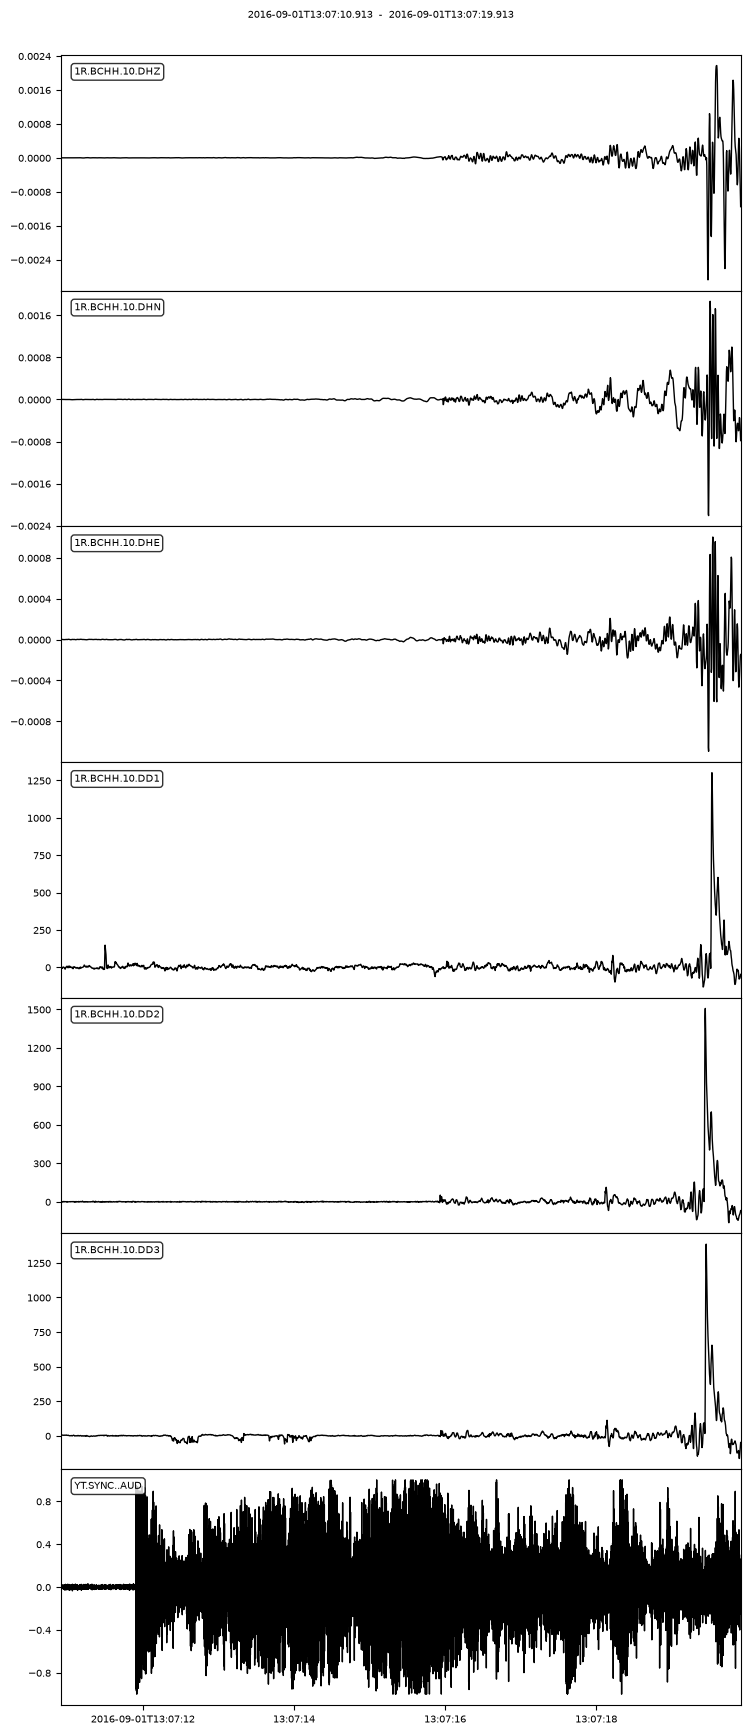

In [27]:
if len(st_audio_raw):
    (st_corr + st_audio_raw).plot(
        starttime=EXPLOSION_TIME - 1,
        endtime=EXPLOSION_TIME + 8,
        equal_scale=False,
    )


## 11. Zoom-figure utilities

The same function can make either:

- **Observed-time plot**: traces remain in UTC; dashed arrival ticks show expected acoustic arrivals.
- **Reduced-time plot**: traces are shifted earlier by travel time; source-time red lines should align with arrivals if the assumed propagation speed and source picks are correct.


## 12. Build the zoom stream and figure

Set `REDUCE_TIME=False` to inspect observed UTC arrival times. Set `REDUCE_TIME=True` to shift traces into source time using the effective acoustic speed computed above.


In [28]:
def build_zoom_stream(
    stcentaur: Stream,
    staudio: Stream,
    zoom_start: UTCDateTime,
    zoom_end: UTCDateTime,
    zerophase: bool,
    infra_freqmin: float = 0.05,
    infra_freqmax: float = 120.0,
    seis_freqmin: float = 0.05,
    seis_freqmax: float = 120.0,
    audio_freqmin: float = 300.0,
    audio_freqmax: float = 5000.0,
    corners: int = 4,
    pad_seconds: float = 10.0,
) -> Stream:
    """Build the filtered zoom stream, including audio, for one zerophase setting."""
    zoom_infra_filter = bandpass_filter_dict(
        freqmin=infra_freqmin,
        freqmax=infra_freqmax,
        corners=corners,
        zerophase=zerophase,
    )
    zoom_seis_filter = bandpass_filter_dict(
        freqmin=seis_freqmin,
        freqmax=seis_freqmax,
        corners=corners,
        zerophase=zerophase,
    )

    # Rebuild zoom data from response-corrected traces, not from the already filtered overview stream.
    st_zoom_local = preprocess_display_stream(
        stcentaur,
        starttime=zoom_start - pad_seconds,
        endtime=zoom_end + pad_seconds,
        infra_filter=zoom_infra_filter,
        seis_filter=zoom_seis_filter,
    )

    # Audio stays in its own clock convention here. Reduced-time shifting handles
    # audio_delay_s later in one place.
    st_audio_zoom_local = prepare_audio_for_plot(
        staudio,
        zoom_start=zoom_start - pad_seconds,
        zoom_end=zoom_end + pad_seconds,
        freqmin=audio_freqmin,
        freqmax=audio_freqmax,
        normalize=True,
        zerophase=zerophase,
        corners=corners,
    )

    return st_audio_zoom_local + st_zoom_local


def channel_delay_s(
    channel: str,
    sensor_distances_m: dict,
    acoustic_speed_mps: float,
    audio_delay_s: float,
) -> float:
    """
    Return propagation delay for one plotted channel.

    For BCHH we assume both infrasound and HH seismic channels record
    the ground-coupled airwave, so all physical BCHH channels use the
    acoustic travel time.

    Audio is treated separately because it may already be synchronized
    to video/source time, or may have a separate manual clock offset.
    """
    ch = channel.upper()

    if is_audio_channel(ch):
        return audio_delay_s

    if ch in sensor_distances_m:
        return (
            sensor_distances_m[ch] / acoustic_speed_mps
            - config.REDUCED_TIME_RESIDUAL_SHIFT_S
        )

    return 0.0


def reduce_stream_to_source_time_for_zoom(
    st: Stream,
    sensor_distances_m: dict,
    acoustic_speed_mps: float,
    audio_delay_s: float,
) -> Stream:
    """
    Shift traces from observed UTC into reduced/source time.

    After this correction, an airwave travelling at acoustic_speed_mps
    should align with the source event time.
    """
    st_red = st.copy()

    for tr in st_red:
        delay = channel_delay_s(
            channel=tr.stats.channel,
            sensor_distances_m=sensor_distances_m,
            acoustic_speed_mps=acoustic_speed_mps,
            audio_delay_s=audio_delay_s,
        )

        print(f"Reducing {tr.id} by {delay:.4f} s")
        tr.stats.starttime -= delay

    return st_red


def make_zoom_figure_simple(
    st: Stream,
    outfile_base: Path,
    zoom_start: UTCDateTime,
    zoom_end: UTCDateTime,
    source_events: dict,
    sensor_distances_m: dict,
    acoustic_speed_mps: float,
    audio_delay_s: float,
    event_window_s: float,
    reduced_time: bool = False,
    show_source_times: bool = True,
    show_predicted_arrivals: bool = True,
    show_event_windows: bool = False,
    normalize_by_group: bool = False,
    clip: float = 4.0,
    trace_gain: float = 0.18,
):
    """
    Plot BCHH zoom figure.

    Timing convention
    -----------------
    If reduced_time is False:
        traces are shown in observed UTC.
        predicted arrivals are plotted at source_time + travel_time.

    If reduced_time is True:
        traces have already had travel times removed.
        source times are plotted directly.
    """
    if len(st) == 0:
        raise ValueError("No traces to plot")

    fig, ax = plt.subplots(figsize=(11.0, 5.2))

    offsets = np.arange(len(st))[::-1].astype(float)
    channel_labels = []
    channel_y = {}

    infra_scales = [
        robust_scale(tr.data, percentile=99.5)
        for tr in st
        if is_infrasound_channel(tr.stats.channel)
    ]
    seis_scales = [
        robust_scale(tr.data, percentile=99.5)
        for tr in st
        if is_seismic_channel(tr.stats.channel)
    ]

    group_scale_infra = np.median(infra_scales) if infra_scales else 1.0
    group_scale_seis = np.median(seis_scales) if seis_scales else 1.0

    for i, tr in enumerate(st):
        y0 = offsets[i]
        ch = tr.stats.channel.upper()
        channel_y[ch] = y0

        trc = tr.copy().trim(zoom_start, zoom_end, pad=True, fill_value=0)

        t = trace_time_array_datetime64(trc)
        data = np.nan_to_num(
            trc.data.astype(float),
            nan=0.0,
            posinf=0.0,
            neginf=0.0,
        )

        if normalize_by_group:
            if is_audio_channel(ch):
                scale = robust_scale(data, percentile=99.5)
            elif is_infrasound_channel(ch):
                scale = group_scale_infra
            else:
                scale = group_scale_seis
        else:
            scale = robust_scale(data, percentile=99.5)

        if scale <= 0 or not np.isfinite(scale):
            scale = 1.0

        y = y0 + np.clip(data / scale, -clip, clip) * trace_gain
        ax.plot(t, y, "-", color="black", lw=0.55, rasterized=True, zorder=12)

        if is_audio_channel(ch):
            channel_labels.append("Audio\n0.3–5 kHz")
        else:
            channel_labels.append(ch)

    ax.set_yticks(offsets)
    ax.set_yticklabels(channel_labels)
    ax.set_ylim(-0.7, len(st) - 0.25)
    ax.set_xlim(
        mdates.date2num(zoom_start.datetime),
        mdates.date2num(zoom_end.datetime),
    )

    from matplotlib.ticker import FuncFormatter

    def format_utc_tenth(value, _position=None):
        timestamp = mdates.num2date(value)
        tenth = timestamp.microsecond // 100000
        return timestamp.strftime("%H:%M:%S") + f".{tenth:d}"

    window_duration_s = float(zoom_end - zoom_start)
    if window_duration_s <= 5.0:
        # Readable labels every 0.5 s, with minor grid lines every 0.1 s.
        ax.xaxis.set_major_locator(
            mdates.MicrosecondLocator(interval=500_000)
        )
        ax.xaxis.set_minor_locator(
            mdates.MicrosecondLocator(interval=100_000)
        )
    else:
        ax.xaxis.set_major_locator(mdates.SecondLocator(interval=2))
        ax.xaxis.set_minor_locator(mdates.SecondLocator(interval=1))
    ax.xaxis.set_major_formatter(FuncFormatter(format_utc_tenth))

    ax.grid(axis="x", which="major", color="0.78", lw=0.8, zorder=1)
    ax.grid(axis="x", which="minor", color="0.93", lw=0.4, zorder=1)
    ax.set_xlabel("Time on 1 September 2016 (UTC)")

    if len(st) >= 6:
        ax.axhline(2.5, color="0.55", lw=0.8, zorder=10)

    def draw_short_vline(x, y0, half_height=0.38, **kwargs):
        ax.vlines(x, y0 - half_height, y0 + half_height, **kwargs)

    ytop = len(st) - 0.15

    for label, source_time in source_events.items():

        if show_source_times and zoom_start <= source_time <= zoom_end:
            x = mdates.date2num(source_time.datetime)

            ax.axvline(
                x,
                color="firebrick",
                lw=1.1,
                alpha=0.85,
                zorder=25,
            )

            ax.text(
                x,
                ytop,
                label,
                rotation=90,
                ha="center",
                va="top",
                fontsize=8,
                color="firebrick",
                alpha=0.90,
                bbox=dict(
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.75,
                    pad=1.0,
                ),
                clip_on=False,
                zorder=30,
            )

        for ch, y0 in channel_y.items():

            if reduced_time:
                arrival_time = source_time
            else:
                delay = channel_delay_s(
                    channel=ch,
                    sensor_distances_m=sensor_distances_m,
                    acoustic_speed_mps=acoustic_speed_mps,
                    audio_delay_s=audio_delay_s,
                )
                arrival_time = source_time + delay

            if show_event_windows:
                t_left = arrival_time - event_window_s / 2
                t_right = arrival_time + event_window_s / 2

                if t_right >= zoom_start and t_left <= zoom_end:
                    ax.fill_betweenx(
                        [y0 - 0.42, y0 + 0.42],
                        mdates.date2num(max(t_left, zoom_start).datetime),
                        mdates.date2num(min(t_right, zoom_end).datetime),
                        color="0.75",
                        alpha=0.35,
                        lw=0,
                        zorder=18,
                    )

            if show_predicted_arrivals and zoom_start <= arrival_time <= zoom_end:
                x = mdates.date2num(arrival_time.datetime)

                color = "firebrick" if is_infrasound_channel(ch) else "0.25"

                draw_short_vline(
                    x,
                    y0,
                    color=color,
                    lw=0.9,
                    linestyles="--",
                    alpha=0.6,
                    zorder=22,
                )

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    fig.subplots_adjust(left=0.08, right=0.99, top=0.96, bottom=0.15)

    fig.savefig(
        outfile_base.with_suffix(".pdf"),
        dpi=300,
        bbox_inches="tight",
        pad_inches=0.04,
    )

    return fig, ax


def make_zoom_variant(
    stcentaur: Stream,
    staudio: Stream,
    output_dir: Path,
    zerophase: bool,
    reduce_time: bool,
    window_start: UTCDateTime,
    window_end: UTCDateTime,
    source_events: dict,
    sensor_distances_m: dict,
    acoustic_speed_mps: float,
    audio_delay_s: float,
    event_window_s: float,
    outfile_stem: str = "fig03_bchh_20s_zoom_with_audio",
    show: bool = True,
    zoom_filter_settings: dict | None = None,
    plot_settings: dict | None = None,
):
    """Build and plot one zoom figure for a zerophase/reduced-time combination.

    All quantities that affect the result are arguments rather than hidden globals.
    """
    if zoom_filter_settings is None:
        zoom_filter_settings = {}
    if plot_settings is None:
        plot_settings = {}

    st_zoom_local = build_zoom_stream(
        stcentaur=stcentaur,
        staudio=staudio,
        zoom_start=window_start,
        zoom_end=window_end,
        zerophase=zerophase,
        **zoom_filter_settings,
    )

    if reduce_time:
        st_zoom_plot_local = reduce_stream_to_source_time_for_zoom(
            st=st_zoom_local,
            sensor_distances_m=sensor_distances_m,
            acoustic_speed_mps=acoustic_speed_mps,
            audio_delay_s=audio_delay_s,
        )
        timing_tag = "reduced"
    else:
        st_zoom_plot_local = st_zoom_local.copy()
        timing_tag = "observed"

    st_zoom_plot_local.trim(window_start, window_end, pad=False)

    outfile_local = output_dir / f"{outfile_stem}_{timing_tag}_{zerophase_tag(zerophase)}"

    print(
        f"Plotting {outfile_local.name}: "
        f"ZEROPHASE={zerophase}, REDUCE_TIME={reduce_time}, "
        f"acoustic speed={acoustic_speed_mps:.1f} m/s"
    )

    fig, ax = make_zoom_figure_simple(
        st=st_zoom_plot_local,
        outfile_base=outfile_local,
        zoom_start=window_start,
        zoom_end=window_end,
        source_events=source_events,
        sensor_distances_m=sensor_distances_m,
        acoustic_speed_mps=acoustic_speed_mps,
        audio_delay_s=audio_delay_s,
        event_window_s=event_window_s,
        reduced_time=reduce_time,
        show_source_times=plot_settings.get("show_source_times", True),
        show_predicted_arrivals=plot_settings.get("show_predicted_arrivals", not reduce_time),
        show_event_windows=plot_settings.get("show_event_windows", False),
        normalize_by_group=plot_settings.get("normalize_by_group", False),
        clip=plot_settings.get("clip", 1.2),
        trace_gain=plot_settings.get("trace_gain", 0.4),
    )

    if show:
        plt.show()
    else:
        plt.close(fig)

    return {
        "zerophase": zerophase,
        "reduce_time": reduce_time,
        "stream": st_zoom_plot_local,
        "outfile": outfile_local,
        "fig": fig,
        "ax": ax,
    }



Using acoustic speed 351.00 m/s from Notebook 11 exact named-event reduction speed, derived from the Notebook 03 meteorological result
Using audio delay 0.000 s from Notebook 160 synchronized-audio product
Reducing YT.SYNC..AUD by 0.0000 s
Reducing 1R.BCHH.10.DD1 by 4.1025 s
Reducing 1R.BCHH.10.DD2 by 4.0124 s
Reducing 1R.BCHH.10.DD3 by 4.0252 s
Reducing 1R.BCHH.10.DHE by 4.0453 s
Reducing 1R.BCHH.10.DHN by 4.0453 s
Reducing 1R.BCHH.10.DHZ by 4.0453 s
Plotting fig03_bchh_30s_zoom_with_audio_reduced_zp_true: ZEROPHASE=True, REDUCE_TIME=True, acoustic speed=351.0 m/s


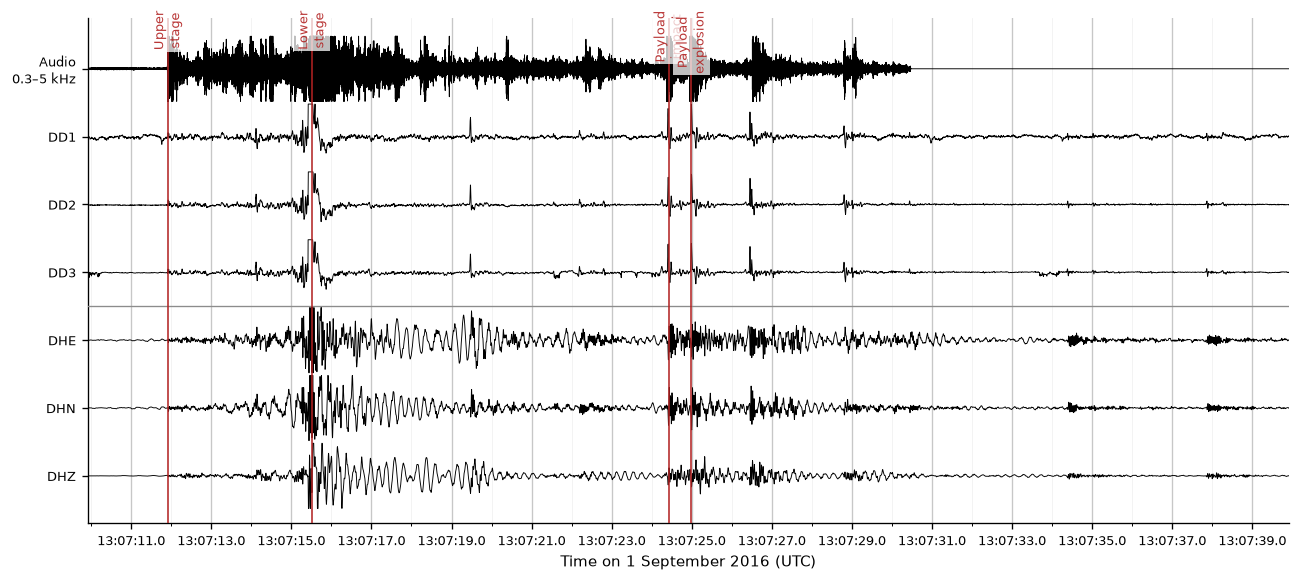

Reducing YT.SYNC..AUD by 0.0000 s
Reducing 1R.BCHH.10.DD1 by 4.1025 s
Reducing 1R.BCHH.10.DD2 by 4.0124 s
Reducing 1R.BCHH.10.DD3 by 4.0252 s
Reducing 1R.BCHH.10.DHE by 4.0453 s
Reducing 1R.BCHH.10.DHN by 4.0453 s
Reducing 1R.BCHH.10.DHZ by 4.0453 s
Plotting fig03_upper_stage_closeup_with_audio_reduced_zp_true: ZEROPHASE=True, REDUCE_TIME=True, acoustic speed=351.0 m/s


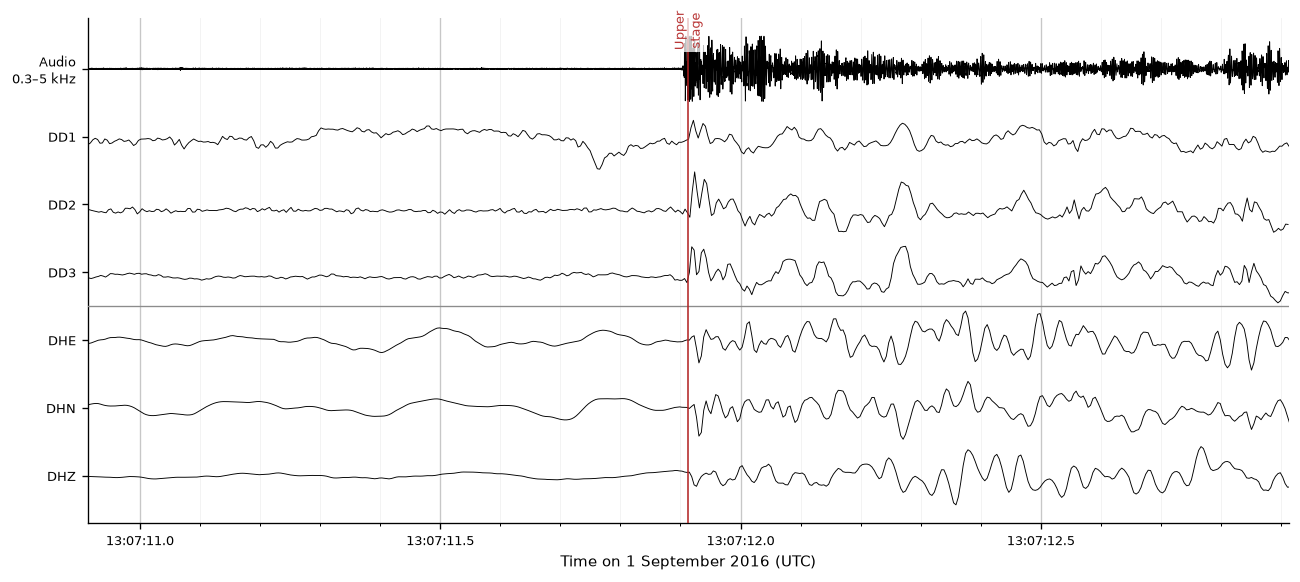

Reducing YT.SYNC..AUD by 0.0000 s
Reducing 1R.BCHH.10.DD1 by 4.1025 s
Reducing 1R.BCHH.10.DD2 by 4.0124 s
Reducing 1R.BCHH.10.DD3 by 4.0252 s
Reducing 1R.BCHH.10.DHE by 4.0453 s
Reducing 1R.BCHH.10.DHN by 4.0453 s
Reducing 1R.BCHH.10.DHZ by 4.0453 s
Plotting fig03_lower_stage_closeup_with_audio_reduced_zp_true: ZEROPHASE=True, REDUCE_TIME=True, acoustic speed=351.0 m/s


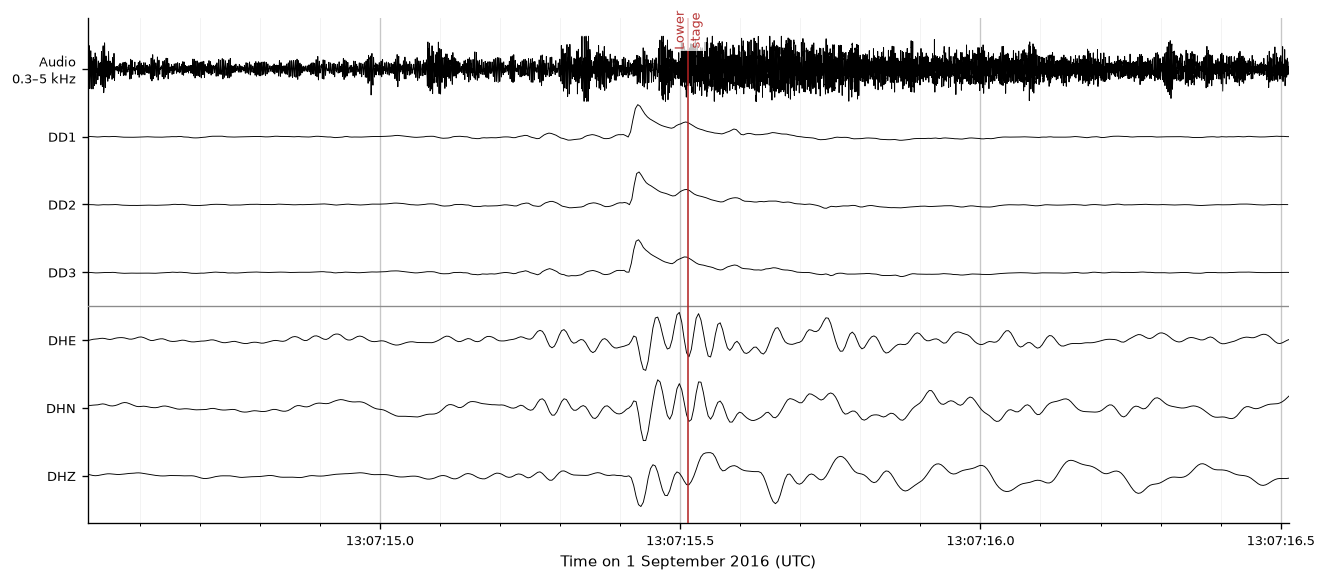

Reducing YT.SYNC..AUD by 0.0000 s
Reducing 1R.BCHH.10.DD1 by 4.1025 s
Reducing 1R.BCHH.10.DD2 by 4.0124 s
Reducing 1R.BCHH.10.DD3 by 4.0252 s
Reducing 1R.BCHH.10.DHE by 4.0453 s
Reducing 1R.BCHH.10.DHN by 4.0453 s
Reducing 1R.BCHH.10.DHZ by 4.0453 s
Plotting fig03_payload_impact_closeup_with_audio_reduced_zp_true: ZEROPHASE=True, REDUCE_TIME=True, acoustic speed=351.0 m/s


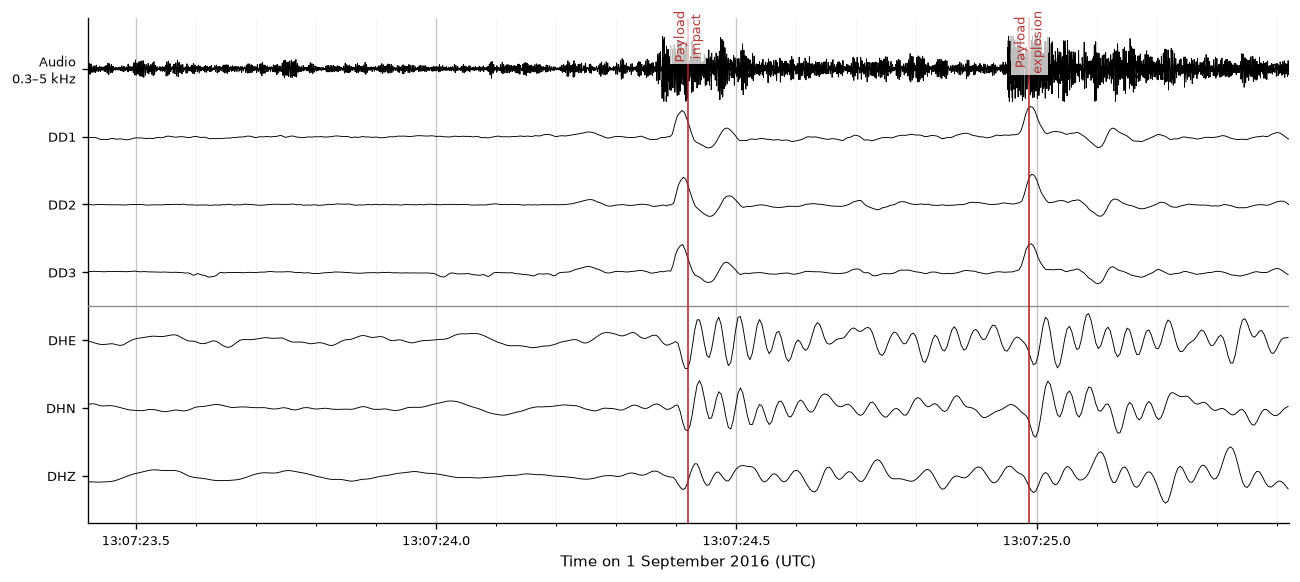

Reducing YT.SYNC..AUD by 0.0000 s
Reducing 1R.BCHH.10.DD1 by 4.1025 s
Reducing 1R.BCHH.10.DD2 by 4.0124 s
Reducing 1R.BCHH.10.DD3 by 4.0252 s
Reducing 1R.BCHH.10.DHE by 4.0453 s
Reducing 1R.BCHH.10.DHN by 4.0453 s
Reducing 1R.BCHH.10.DHZ by 4.0453 s
Plotting fig03_payload_explosion_closeup_with_audio_reduced_zp_true: ZEROPHASE=True, REDUCE_TIME=True, acoustic speed=351.0 m/s


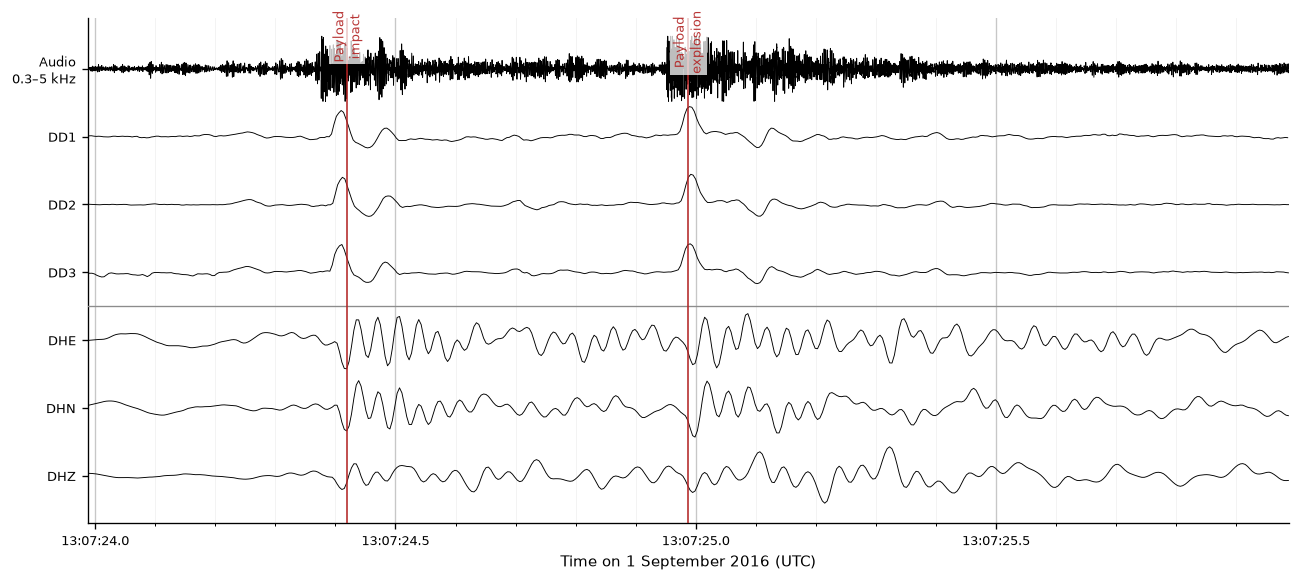

Reducing YT.SYNC..AUD by 0.0000 s
Reducing 1R.BCHH.10.DD1 by 4.1025 s
Reducing 1R.BCHH.10.DD2 by 4.0124 s
Reducing 1R.BCHH.10.DD3 by 4.0252 s
Reducing 1R.BCHH.10.DHE by 4.0453 s
Reducing 1R.BCHH.10.DHN by 4.0453 s
Reducing 1R.BCHH.10.DHZ by 4.0453 s
Plotting fig03_event_024_closeup_with_audio_reduced_zp_true: ZEROPHASE=True, REDUCE_TIME=True, acoustic speed=351.0 m/s


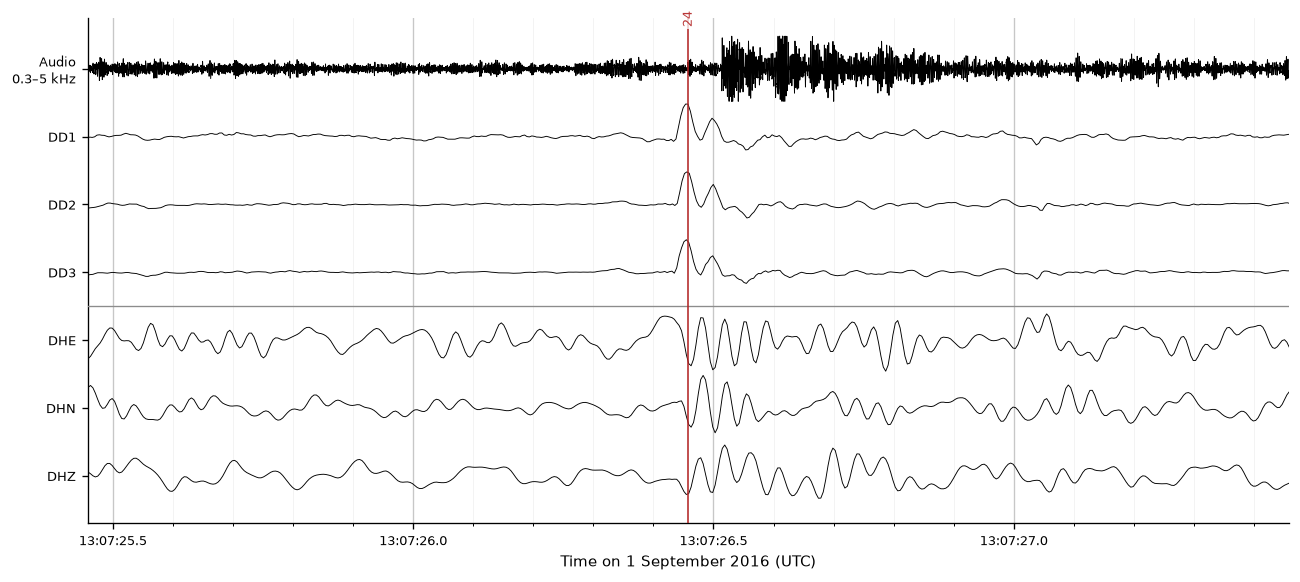

Generated close-up figures:
  /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/170_generate_publication_figures/fig03_upper_stage_closeup_with_audio_reduced_zp_true
  /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/170_generate_publication_figures/fig03_lower_stage_closeup_with_audio_reduced_zp_true
  /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/170_generate_publication_figures/fig03_payload_impact_closeup_with_audio_reduced_zp_true
  /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/170_generate_publication_figures/fig03_payload_explosion_closeup_with_audio_reduced_zp_true
  /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/170_generate_publication_figu

,source_event_key,event,reference_channel,source_time_utc,observed_positive_peak_utc,model_positive_peak_utc,peak_residual_observed_minus_model_s,model_speed_mps,notebook11_speed_mps,travel_time_difference_from_notebook11_s,positive_peak_implied_effective_speed_mps
0,upper_stage,Initial second-stage failure,DD2,2016-09-01T13:07:11.913000Z,2016-09-01T13:07:15.937360Z,2016-09-01T13:07:15.925360Z,0.012,351.0,351.0,0.0,349.953398
1,lower_stage,Principal explosion,DD2,2016-09-01T13:07:15.513600Z,2016-09-01T13:07:19.443960Z,2016-09-01T13:07:19.525960Z,-0.082,351.0,351.0,0.0,358.323018
2,payload_impact,Payload impact,DD2,2016-09-01T13:07:24.420000Z,2016-09-01T13:07:28.424360Z,2016-09-01T13:07:28.432360Z,-0.008,351.0,351.0,0.0,351.701260
3,payload_explosion,Payload explosion,DD2,2016-09-01T13:07:24.987500Z,2016-09-01T13:07:29.005860Z,2016-09-01T13:07:28.999860Z,0.006,351.0,351.0,0.0,350.475930


Wrote: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/170_generate_publication_figures/named_event_peak_alignment_diagnostic.csv


In [29]:
REDUCE_TIME = True

zoom_start = EXPLOSION_TIME - 2
zoom_end = EXPLOSION_TIME + 28

speed_to_use = ADOPTED_ACOUSTIC_SPEED_MPS
video_alignment_mode = AUDIO_ALIGNMENT_MODE
sync_speed_value = next(
    (
        video_sync.get(name)
        for name in (
            "bchh_meteorological_effective_sound_speed_mps",
            "bchh_effective_sound_speed_mps",
            "sound_speed_mps",
        )
        if video_sync.get(name) is not None
    ),
    np.nan,
)
sync_bchh_speed_mps = float(sync_speed_value)
if np.isfinite(sync_bchh_speed_mps) and not np.isclose(
    sync_bchh_speed_mps,
    ADOPTED_ACOUSTIC_SPEED_MPS,
    rtol=0.0,
    atol=0.05,
):
    warnings.warn(
        "Notebook 160 recorded a different BCHH display speed "
        f"({sync_bchh_speed_mps:.3f} m/s) from the current adopted "
        f"reduction speed ({ADOPTED_ACOUSTIC_SPEED_MPS:.3f} m/s). "
        "Notebook 170 will independently reduce BCHH data using the "
        "current authoritative speed."
    )
elif not np.isfinite(sync_bchh_speed_mps):
    warnings.warn(
        "Notebook 160 metadata does not record a BCHH sound speed; "
        "Notebook 170 will use its authoritative Notebook 020/110 handoff."
    )

if len(st_audio_raw):
    if video_alignment_mode not in {"observed_utc", "source_aligned"}:
        raise ValueError(
            f"Invalid audio timing basis: {video_alignment_mode!r}"
        )
    audio_delay_to_use = (
        0.0
        if video_alignment_mode == "source_aligned"
        else AUDIO_CAMERA_TRAVEL_TIME_S
    )
else:
    audio_delay_to_use = 0.0

print(
    f"Using acoustic speed {speed_to_use:.2f} m/s "
    f"from {ADOPTED_SPEED_SOURCE}"
)
print(
    f"Using audio delay {audio_delay_to_use:.3f} s "
    f"from {AUDIO_METADATA_SOURCE or 'no audio product'}"
)

zoom_filter_settings = {
    "infra_freqmin": 0.05,
    "infra_freqmax": 120.0,
    "seis_freqmin": 0.05,
    "seis_freqmax": 120.0,
    "audio_freqmin": 300.0,
    "audio_freqmax": 5000.0,
    "corners": 4,
    "pad_seconds": 10.0,
}
zoom_plot_settings = {
    "show_source_times": True,
    "show_event_windows": False,
    "normalize_by_group": False,
    "clip": 1.2,
    "trace_gain": 0.4,
}

zoom_results = []
closeup_results = []

if len(st_audio_raw):
    zerophase_values_to_run = (
        ZEROPHASE_RUNS
        if RUN_ZEROPHASE_COMPARISON
        else [ZEROPHASE]
    )

    for zerophase in zerophase_values_to_run:
        zoom_results.append(
            make_zoom_variant(
                stcentaur=st_ordered,
                staudio=st_audio_raw,
                output_dir=OUTDIR,
                zerophase=zerophase,
                reduce_time=REDUCE_TIME,
                window_start=zoom_start,
                window_end=zoom_end,
                source_events=MAIN_SOURCE_EVENTS,
                sensor_distances_m=SENSOR_DISTANCES_M,
                acoustic_speed_mps=speed_to_use,
                audio_delay_s=audio_delay_to_use,
                event_window_s=VIDEO_PICK_UNCERTAINTY_S,
                outfile_stem="fig03_bchh_30s_zoom_with_audio",
                show=True,
                zoom_filter_settings=zoom_filter_settings,
                plot_settings=zoom_plot_settings,
            )
        )

    # Event-centered display windows. Centers come from Notebook 02/12
    # products; only the visual half-widths are figure-layout choices.
    closeup_definitions = [
        {
            "name": "upper_stage",
            "center": EXPLOSION_TIME,
            "half_width_s": 1.0,
            "source_events": {"Upper\nstage": UPPER_STAGE},
            "outfile_stem": (
                "fig03_upper_stage_closeup_with_audio"
            ),
        },
        {
            "name": "lower_stage",
            "center": FIRST_STAGE,
            "half_width_s": 1.0,
            "source_events": {"Lower\nstage": LOWER_STAGE},
            "outfile_stem": (
                "fig03_lower_stage_closeup_with_audio"
            ),
        },
        {
            "name": "payload_impact",
            "center": PAYLOAD_IMPACT,
            "half_width_s": 1.0,
            "source_events": PAYLOAD_SOURCE_EVENTS,
            "outfile_stem": (
                "fig03_payload_impact_closeup_with_audio"
            ),
        },
        {
            "name": "payload_explosion",
            "center": PAYLOAD_EXPLOSION,
            "half_width_s": 1.0,
            "source_events": PAYLOAD_SOURCE_EVENTS,
            "outfile_stem": (
                "fig03_payload_explosion_closeup_with_audio"
            ),
        },
        {
            "name": "event_024",
            "center": EVENT_024,
            "half_width_s": 1.0,
            "source_events": EVENT_024_SOURCE_EVENT,
            "outfile_stem": (
                "fig03_event_024_closeup_with_audio"
            ),
        },
    ]

    # Preserve the useful Notebook 12 precursor closeups from the development
    # notebook. These are centered on provisional candidate-P picks and are
    # deliberately not added to SOURCE_EVENTS or interpreted as source times.
    for pick_name, pick_time in PROVISIONAL_P_PICKS.items():
        closeup_definitions.append({
            "name": pick_name,
            "center": pick_time,
            "half_width_s": 1.0,
            "source_events": {},
            "outfile_stem": (
                f"fig03_{pick_name}_provisional_closeup_with_audio"
            ),
        })

    for definition in closeup_definitions:
        for zerophase in zerophase_values_to_run:
            closeup_results.append(
                make_zoom_variant(
                    stcentaur=st_ordered,
                    staudio=st_audio_raw,
                    output_dir=OUTDIR,
                    zerophase=zerophase,
                    reduce_time=REDUCE_TIME,
                    window_start=(
                        definition["center"]
                        - definition["half_width_s"]
                    ),
                    window_end=(
                        definition["center"]
                        + definition["half_width_s"]
                    ),
                    source_events=definition["source_events"],
                    sensor_distances_m=SENSOR_DISTANCES_M,
                    acoustic_speed_mps=speed_to_use,
                    audio_delay_s=audio_delay_to_use,
                    event_window_s=VIDEO_PICK_UNCERTAINTY_S,
                    outfile_stem=definition["outfile_stem"],
                    show=True,
                    zoom_filter_settings=zoom_filter_settings,
                    plot_settings=zoom_plot_settings,
                )
            )

    st_zoom_plot = zoom_results[0]["stream"]
    outfile = zoom_results[0]["outfile"]

    print("Generated close-up figures:")
    for result in closeup_results:
        print(" ", result["outfile"])
else:
    print(
        "Skipping audio zoom figures because "
        "Notebook 13 audio is unavailable."
    )

# Quantify the figure residual using the Notebook 11 reference-channel
# positive peak. This is a diagnostic, not a redefinition of source time.
# A negative residual means the peak arrives earlier than the 351 m/s model.
alignment_rows = []
for window in key_event_windows.itertuples(index=False):
    source_event_key = config.canonical_source_event_key(window.source_event_key)
    if source_event_key not in config.SOURCE_EVENT_TIMES:
        continue
    reference_channel = str(window.arrival_reference_channel).upper()
    peak_rows = key_event_pressures.loc[
        key_event_pressures["event"].astype(str).eq(str(window.event))
        & key_event_pressures["channel"].astype(str).str.upper().eq(reference_channel)
    ]
    if len(peak_rows) != 1:
        continue

    peak_row = peak_rows.iloc[0]
    source_time = UTCDateTime(config.SOURCE_EVENT_TIMES[source_event_key])
    observed_peak_time = (
        UTCDateTime(str(window.window_start_utc))
        + float(peak_row["positive_peak_time_s"])
    )
    distance_m = float(window.arrival_reference_distance_m)
    model_travel_time_s = distance_m / speed_to_use
    model_peak_time = source_time + model_travel_time_s
    observed_travel_time_s = float(observed_peak_time - source_time)
    notebook11_speed_mps = float(window.acoustic_propagation_speed_mps)

    alignment_rows.append({
        "source_event_key": source_event_key,
        "event": str(window.event),
        "reference_channel": reference_channel,
        "source_time_utc": str(source_time),
        "observed_positive_peak_utc": str(observed_peak_time),
        "model_positive_peak_utc": str(model_peak_time),
        "peak_residual_observed_minus_model_s": float(
            observed_peak_time - model_peak_time
        ),
        "model_speed_mps": speed_to_use,
        "notebook11_speed_mps": notebook11_speed_mps,
        "travel_time_difference_from_notebook11_s": float(
            distance_m / speed_to_use - distance_m / notebook11_speed_mps
        ),
        "positive_peak_implied_effective_speed_mps": (
            distance_m / observed_travel_time_s
            if observed_travel_time_s > 0 else np.nan
        ),
    })

named_event_peak_alignment = pd.DataFrame(alignment_rows)
alignment_output = OUTDIR / "named_event_peak_alignment_diagnostic.csv"
named_event_peak_alignment.to_csv(alignment_output, index=False)
display(named_event_peak_alignment)
print("Wrote:", alignment_output)


## 14. Compact video–audio–infrasound–seismic event figures

These publication-oriented figures simplify the final Notebook 13b alignment display. Each figure shows one native video frame immediately before and one immediately after the mapped event time, followed by individually normalized, source-reduced camera audio, raw infrasound, and three-component seismic traces. The final configured source times replace the provisional 13b pick JSON; travel-time reduction uses the exact 351 m s⁻¹ convention adopted by the final workflow. Camera audio is high-pass filtered above 300 Hz, DD1–DD3 are unfiltered apart from the previously applied baseline correction, and the seismic channels are filtered from 0.5 to 20 Hz for display. The figures demonstrate timing correspondence rather than relative amplitude.


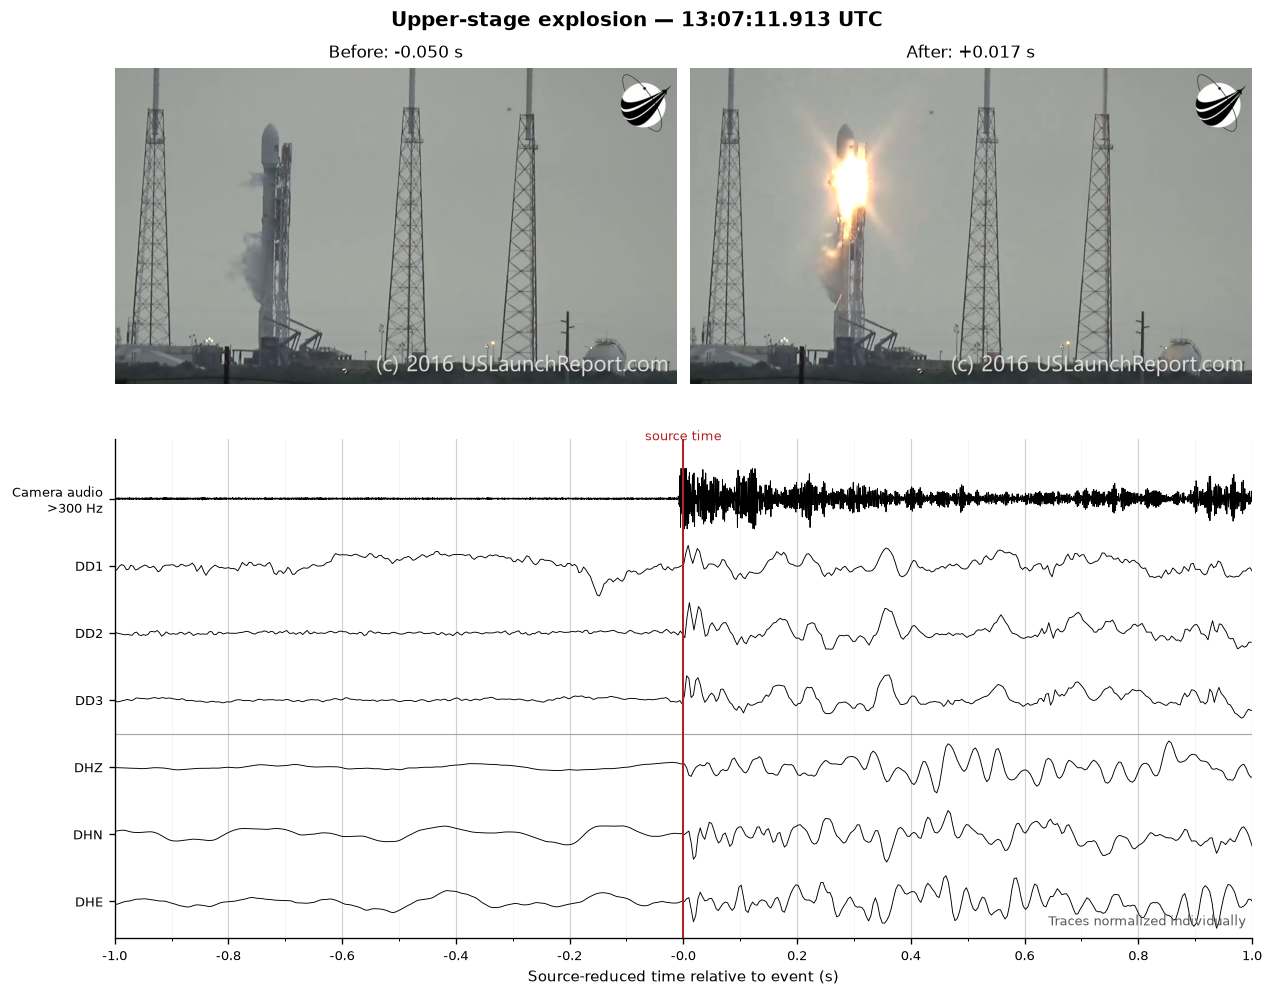

Wrote: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/170_generate_publication_figures/fig04_multimodal_alignment_upper_stage.pdf


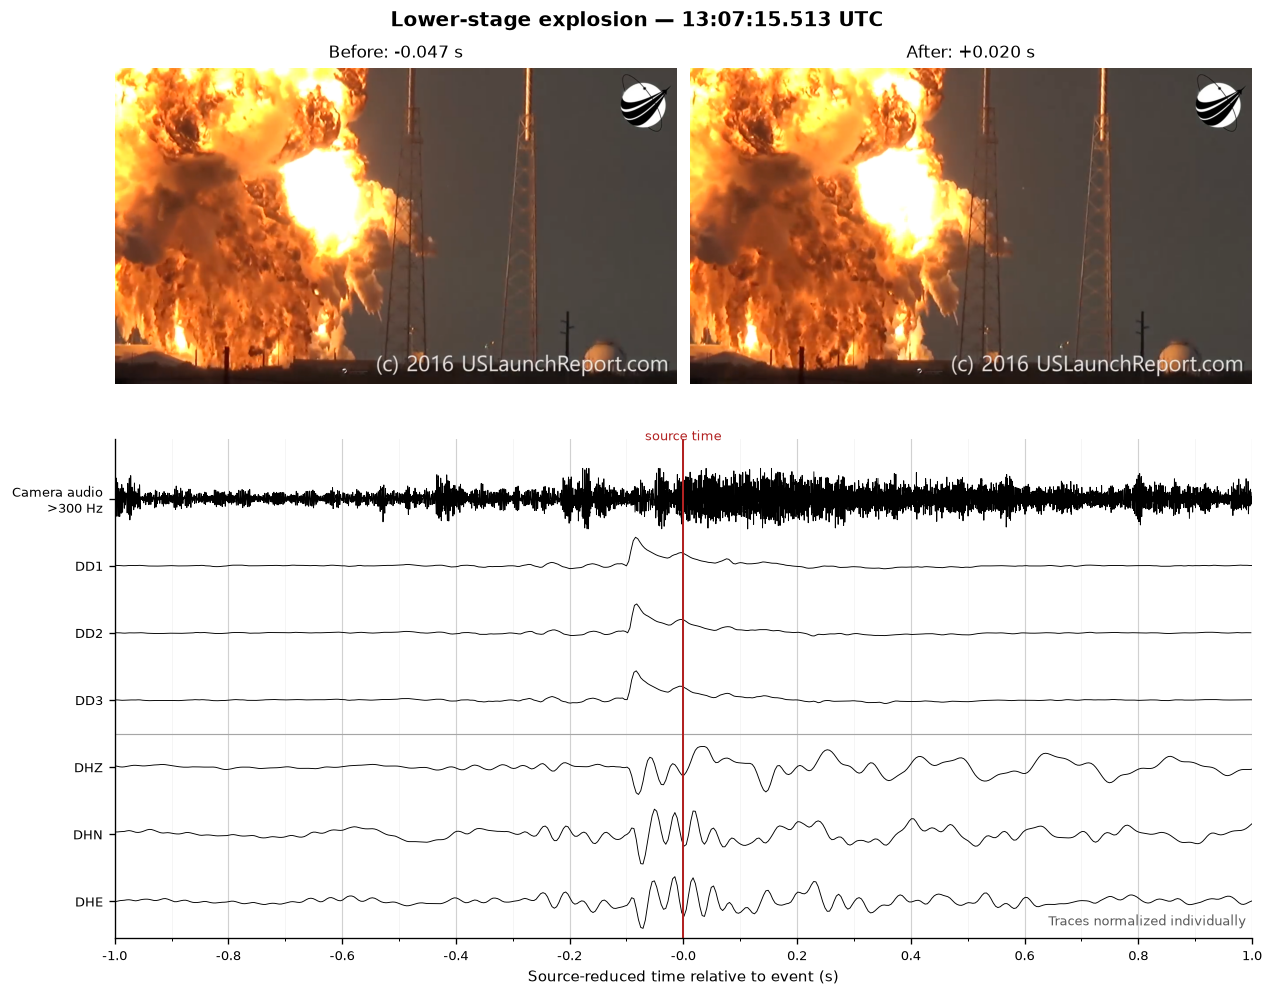

Wrote: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/170_generate_publication_figures/fig04_multimodal_alignment_lower_stage.pdf


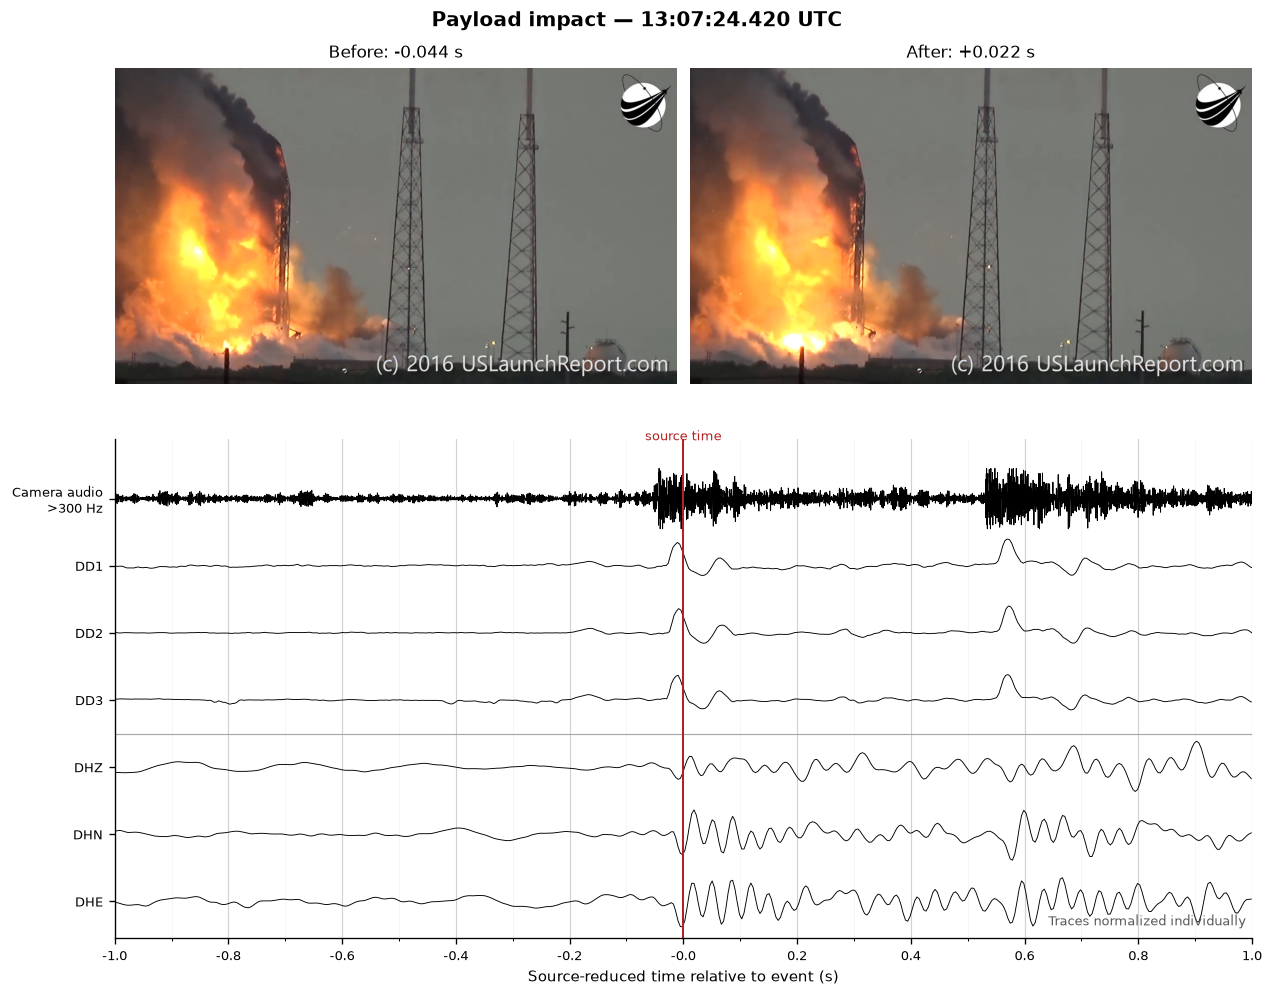

Wrote: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/170_generate_publication_figures/fig04_multimodal_alignment_payload_impact.pdf


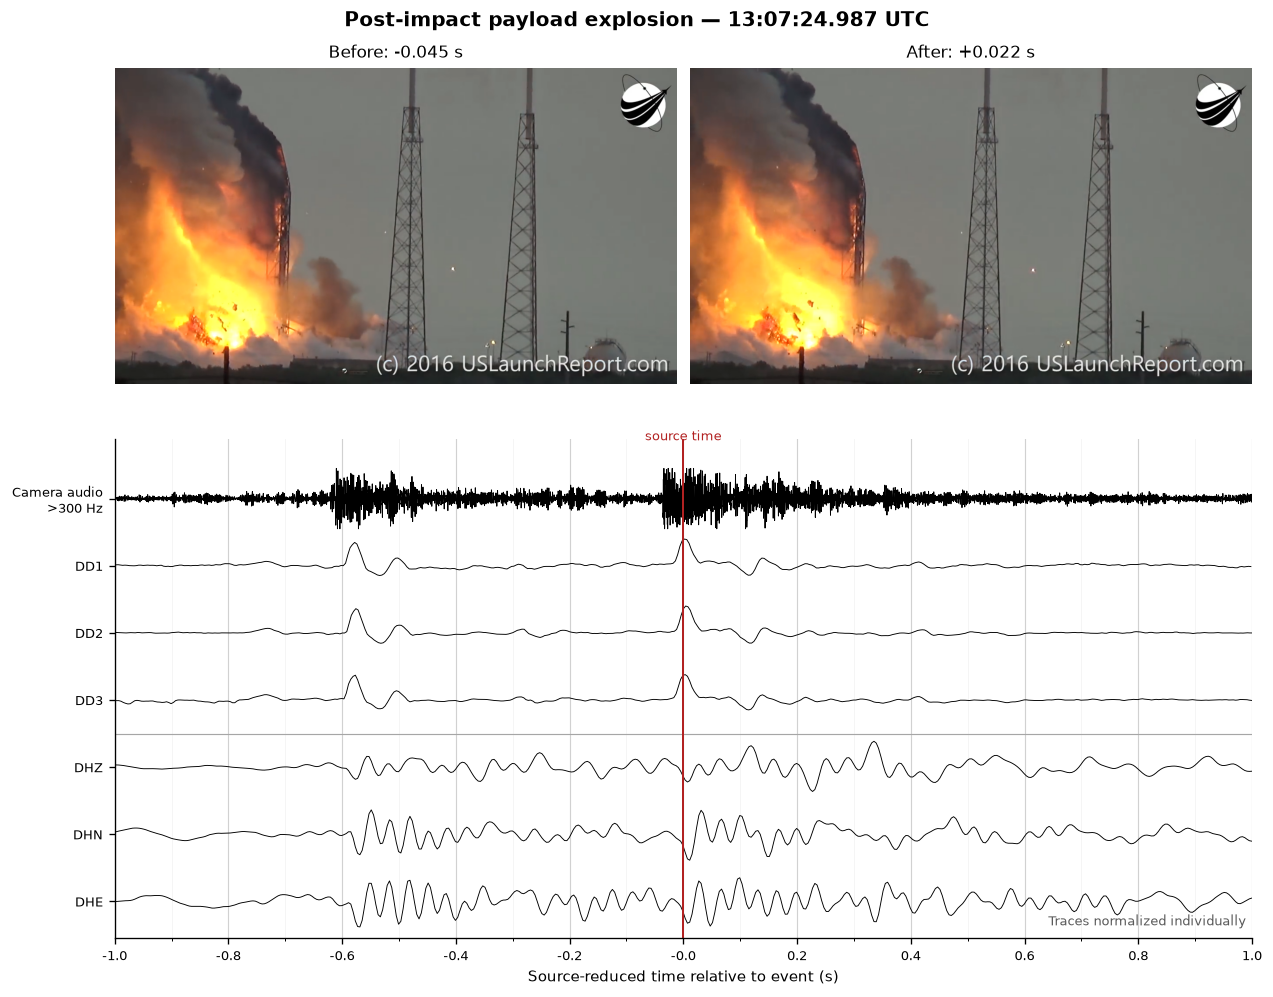

Wrote: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/170_generate_publication_figures/fig04_multimodal_alignment_payload_explosion.pdf


,event_key,event_label,source_time_utc,frame_position,requested_pts_s,actual_pts_s,mapped_source_time_utc,offset_from_source_time_s
0,upper_stage,Upper-stage explosion,2016-09-01T13:07:11.913000Z,before,71.688000,71.671600,2016-09-01T13:07:11.863233Z,-0.049767
1,upper_stage,Upper-stage explosion,2016-09-01T13:07:11.913000Z,after,71.754733,71.738333,2016-09-01T13:07:11.929967Z,0.016967
2,lower_stage,Lower-stage explosion,2016-09-01T13:07:15.513600Z,before,75.288600,75.275200,2016-09-01T13:07:15.466833Z,-0.046767
3,lower_stage,Lower-stage explosion,2016-09-01T13:07:15.513600Z,after,75.355333,75.341933,2016-09-01T13:07:15.533567Z,0.019967
4,payload_impact,Payload impact,2016-09-01T13:07:24.420000Z,before,84.195000,84.184100,2016-09-01T13:07:24.375733Z,-0.044267
5,payload_impact,Payload impact,2016-09-01T13:07:24.420000Z,after,84.261733,84.250833,2016-09-01T13:07:24.442467Z,0.022467
6,payload_explosion,Post-impact payload explosion,2016-09-01T13:07:24.987500Z,before,84.762500,84.751333,2016-09-01T13:07:24.942967Z,-0.044533
7,payload_explosion,Post-impact payload explosion,2016-09-01T13:07:24.987500Z,after,84.829233,84.818067,2016-09-01T13:07:25.009700Z,0.022200


Wrote: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/170_generate_publication_figures/multimodal_event_frame_audit.csv


In [30]:
import av
from matplotlib.ticker import FuncFormatter

MULTIMODAL_EVENT_HALF_WINDOW_S = 1.0
MULTIMODAL_FRAME_OFFSET_COUNT = 1
MULTIMODAL_OUTPUT_PREFIX = "fig04_multimodal_alignment"

MULTIMODAL_EVENTS = {
    "upper_stage": ("Upper-stage explosion", UPPER_STAGE),
    "lower_stage": ("Lower-stage explosion", LOWER_STAGE),
    "payload_impact": ("Payload impact", PAYLOAD_IMPACT),
    "payload_explosion": ("Post-impact payload explosion", PAYLOAD_EXPLOSION),
}

video_file_value = video_sync.get("video_file")
VIDEO_FILE_FOR_FIGURES = (
    Path(video_file_value).expanduser()
    if video_file_value
    else Path(config.USLAUNCHREPORT_VIDEO_FILE)
    if config.USLAUNCHREPORT_VIDEO_FILE is not None
    else Path()
)
if (
    not VIDEO_FILE_FOR_FIGURES.is_file()
    and config.USLAUNCHREPORT_VIDEO_FILE is not None
):
    VIDEO_FILE_FOR_FIGURES = Path(config.USLAUNCHREPORT_VIDEO_FILE)
if not VIDEO_FILE_FOR_FIGURES.is_file():
    warnings.warn(
        "The configured source video is unavailable; compact multimodal figures "
        f"will be skipped: {VIDEO_FILE_FOR_FIGURES}"
    )


class PublicationVideoFrameReader:
    """Read the native movie frame nearest a requested presentation timestamp."""

    def __init__(self, path: Path):
        self.path = Path(path)
        self.container = av.open(str(self.path))
        self.stream = self.container.streams.video[0]
        self.stream.thread_type = "AUTO"
        self.nominal_fps = (
            float(self.stream.average_rate)
            if self.stream.average_rate is not None
            else float(config.VIDEO_NOMINAL_FPS)
        )

    def close(self):
        self.container.close()

    def frame_at_pts(self, requested_s: float):
        seek_pts = int(max(0.0, requested_s) / float(self.stream.time_base))
        self.container.seek(
            max(0, seek_pts),
            stream=self.stream,
            backward=True,
            any_frame=False,
        )
        best_frame = None
        best_seconds = np.nan
        best_error = np.inf
        for frame in self.container.decode(self.stream):
            if frame.pts is None:
                continue
            seconds = float(frame.pts * frame.time_base)
            error = abs(seconds - requested_s)
            if error < best_error:
                best_frame = frame
                best_seconds = seconds
                best_error = error
            if seconds >= requested_s:
                break
        if best_frame is None:
            raise RuntimeError(
                f"No video frame decoded near PTS {requested_s:.6f} s"
            )
        return best_frame.to_ndarray(format="rgb24"), best_seconds


def prepare_multimodal_event_stream(source_time: UTCDateTime, filter_seismic=False) -> Stream:
    """Reproduce final 13b timing logic and add display-filtered seismic."""
    window_start = source_time - MULTIMODAL_EVENT_HALF_WINDOW_S
    window_end = source_time + MULTIMODAL_EVENT_HALF_WINDOW_S
    output = Stream()

    # Notebook 13 audio is normally already source aligned. If its metadata
    # instead says observed_utc, audio_delay_to_use is removed exactly once.
    # Match final 13b with a high-pass filter above 300 Hz.
    audio_matches = st_audio_raw.select(channel="AUD")
    if len(audio_matches) != 1:
        raise ValueError(
            f"Expected one synchronized AUD trace; found {len(audio_matches)}"
        )
    audio = audio_matches[0].copy()
    audio.detrend("demean")
    audio.filter("highpass", freq=300.0, corners=4, zerophase=True)
    audio.stats.starttime -= audio_delay_to_use
    audio.trim(window_start, window_end, pad=False)
    output += audio

    # Final 13b displays raw infrasound. The canonical stream has already
    # undergone response and moving-median baseline correction upstream; no
    # additional detrend, taper, or frequency filter is applied here.
    for channel in PRESSURE_CHANNELS:
        matches = st_ordered.select(channel=channel)
        if len(matches) != 1:
            raise ValueError(f"Expected one {channel} trace; found {len(matches)}")
        trace = matches[0].copy()
        trace.stats.starttime -= SENSOR_ACOUSTIC_TRAVEL_TIMES_S[channel]
        trace.trim(window_start, window_end, pad=False)
        output += trace

    # The seismic channels principally show the ground-coupled airwave, so
    # the same acoustic d/c reduction is used. A zero-phase 0.5–20 Hz display
    # filter suppresses drift and noise without changing the arrival time.
    for channel in ("DHZ", "DHN", "DHE"):
        matches = st_ordered.select(channel=channel)
        if len(matches) != 1:
            raise ValueError(f"Expected one {channel} trace; found {len(matches)}")
        trace = matches[0].copy()
        trace.detrend("demean")
        if filter_seismic:
            trace.taper(max_percentage=0.02)
            trace.filter(
                "bandpass", freqmin=0.5, freqmax=20.0,
                corners=4, zerophase=True,
            )
        trace.stats.starttime -= SENSOR_ACOUSTIC_TRAVEL_TIMES_S[channel]
        trace.trim(window_start, window_end, pad=False)
        output += trace

    return output


def one_trace_by_channel(stream: Stream, channel: str):
    matches = stream.select(channel=channel)
    if len(matches) != 1:
        raise ValueError(
            f"Expected one {channel} trace in compact event figure; "
            f"found {len(matches)}"
        )
    return matches[0]


def make_multimodal_event_figure(
    video_reader: PublicationVideoFrameReader,
    event_key: str,
    event_label: str,
    source_time: UTCDateTime,
    outfile_base: Path,
):
    """Create a two-frame and seven-trace source-alignment figure."""
    frame_period_s = 1.0 / video_reader.nominal_fps
    event_pts_s = (
        float(config.VIDEO_ANCHOR_MOVIE_S)
        + float(source_time - UTCDateTime(config.VIDEO_ANCHOR_UTC))
    )
    requested_frame_pts = (
        event_pts_s - MULTIMODAL_FRAME_OFFSET_COUNT * frame_period_s,
        event_pts_s + MULTIMODAL_FRAME_OFFSET_COUNT * frame_period_s,
    )

    frames = []
    frame_rows = []
    for position, requested_pts_s in zip(("Before", "After"), requested_frame_pts):
        frame, actual_pts_s = video_reader.frame_at_pts(requested_pts_s)
        mapped_source_time = (
            UTCDateTime(config.VIDEO_ANCHOR_UTC)
            + actual_pts_s
            - float(config.VIDEO_ANCHOR_MOVIE_S)
        )
        offset_s = float(mapped_source_time - source_time)
        frames.append((position, frame, actual_pts_s, offset_s))
        frame_rows.append({
            "event_key": event_key,
            "event_label": event_label,
            "source_time_utc": str(source_time),
            "frame_position": position.lower(),
            "requested_pts_s": requested_pts_s,
            "actual_pts_s": actual_pts_s,
            "mapped_source_time_utc": str(mapped_source_time),
            "offset_from_source_time_s": offset_s,
        })

    stream = prepare_multimodal_event_stream(source_time)
    display_channels = [
        ("AUD", "Camera audio\n>300 Hz"),
        ("DD1", "DD1"),
        ("DD2", "DD2"),
        ("DD3", "DD3"),
        ("DHZ", "DHZ"),#\n0.5–20 Hz"),
        ("DHN", "DHN"),#\n0.5–20 Hz"),
        ("DHE", "DHE"),#\n0.5–20 Hz"),
    ]

    fig = plt.figure(figsize=(10.5, 8.2), constrained_layout=True)
    grid = fig.add_gridspec(2, 2, height_ratios=(1.0, 1.35), hspace=0.04)
    video_axes = [fig.add_subplot(grid[0, 0]), fig.add_subplot(grid[0, 1])]
    waveform_ax = fig.add_subplot(grid[1, :])

    for ax, (position, frame, actual_pts_s, offset_s) in zip(video_axes, frames):
        ax.imshow(frame)
        ax.set_axis_off()
        ax.set_title(
            f"{position}: {offset_s:+.3f} s",
            fontsize=10,
            loc="center",
        )

    offsets = np.arange(len(display_channels))[::-1].astype(float)
    for y0, (channel, label) in zip(offsets, display_channels):
        trace = one_trace_by_channel(stream, channel).copy()
        relative_s = trace.times(reftime=source_time)
        values = np.asarray(trace.data, dtype=float)
        scale = robust_scale(values, percentile=99.5)
        normalized = np.clip(values / scale, -1.25, 1.25)
        waveform_ax.plot(
            relative_s,
            y0 + 0.36 * normalized,
            color="black",
            lw=0.55,
            rasterized=True,
        )

    waveform_ax.axhline(2.5, color="0.65", lw=0.7)
    waveform_ax.axvline(0.0, color="firebrick", lw=1.2)
    waveform_ax.text(
        0.0,
        len(display_channels) - 0.18,
        "source time",
        color="firebrick",
        fontsize=8,
        ha="center",
        va="bottom",
    )
    waveform_ax.set_yticks(offsets)
    waveform_ax.set_yticklabels([label for _, label in display_channels])
    waveform_ax.set_ylim(-0.55, len(display_channels) - 0.12)
    waveform_ax.set_xlim(
        -MULTIMODAL_EVENT_HALF_WINDOW_S,
        MULTIMODAL_EVENT_HALF_WINDOW_S,
    )
    waveform_ax.set_xticks(np.arange(-1.0, 1.01, 0.2))
    waveform_ax.set_xticks(np.arange(-1.0, 1.01, 0.1), minor=True)
    waveform_ax.xaxis.set_major_formatter(
        FuncFormatter(lambda value, position: f"{value:.1f}")
    )
    waveform_ax.grid(axis="x", which="major", color="0.82", lw=0.7)
    waveform_ax.grid(axis="x", which="minor", color="0.94", lw=0.4)
    waveform_ax.set_xlabel("Source-reduced time relative to event (s)")
    waveform_ax.text(
        0.995,
        0.02,
        "Traces normalized individually",
        transform=waveform_ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=7.5,
        color="0.35",
    )
    for spine in ("top", "right"):
        waveform_ax.spines[spine].set_visible(False)

    fig.suptitle(
        f"{event_label} — {source_time.strftime('%H:%M:%S.%f')[:-3]} UTC",
        fontsize=12,
        fontweight="bold",
    )
    for extension in ("pdf",):
        fig.savefig(
            outfile_base.with_suffix(f".{extension}"),
            dpi=300,
            bbox_inches="tight",
            pad_inches=0.04,
        )
    return fig, frame_rows


multimodal_frame_rows = []
multimodal_event_figures = {}
if VIDEO_FILE_FOR_FIGURES.is_file() and len(st_audio_raw):
    publication_video_reader = PublicationVideoFrameReader(VIDEO_FILE_FOR_FIGURES)
    try:
        for event_key, (event_label, source_time) in MULTIMODAL_EVENTS.items():
            outfile_base = OUTDIR / f"{MULTIMODAL_OUTPUT_PREFIX}_{event_key}"
            figure, frame_rows = make_multimodal_event_figure(
                publication_video_reader,
                event_key,
                event_label,
                source_time,
                outfile_base,
            )
            multimodal_event_figures[event_key] = figure
            multimodal_frame_rows.extend(frame_rows)
            plt.show()
            print("Wrote:", outfile_base.with_suffix(".pdf"))
    finally:
        publication_video_reader.close()

    multimodal_frame_audit = pd.DataFrame(multimodal_frame_rows)
    multimodal_frame_audit_file = (
        OUTDIR / "multimodal_event_frame_audit.csv"
    )
    multimodal_frame_audit.to_csv(multimodal_frame_audit_file, index=False)
    display(multimodal_frame_audit)
    print("Wrote:", multimodal_frame_audit_file)
else:
    warnings.warn(
        "Skipping compact multimodal event figures because synchronized "
        "video or audio is unavailable."
    )


## 15. Figure-generation provenance


In [31]:
figure_provenance = {
    "producer_notebook": "170_generate_publication_figures.ipynb",
    "analysis_configuration": str(ANALYSIS_CONFIG_FILE),
    "weather_summary": str(WEATHER_FILE),
    "catalogue": str(CATALOGUE_FILE),
    "geometry": str(GEOMETRY_FILE),
    "waveform_stream": str(BASELINE_STREAM_FILE),
    "planar_results": str(PLANAR_RESULTS_FILE),
    "planar_summary": str(PLANAR_SUMMARY_FILE),
    "polarization_picks": str(POLARIZATION_PICKS_FILE),
    "key_event_pressures": str(KEY_EVENT_PRESSURES_FILE),
    "key_event_windows": str(KEY_EVENT_WINDOWS_FILE),
    "key_event_metadata": str(KEY_EVENT_METADATA_FILE),
    "video_sync": str(VIDEO_SYNC_FILE),
    "publication_audio_file": (
        str(AUDIO_FILE) if AUDIO_FILE is not None else None
    ),
    "publication_audio_alignment_mode": AUDIO_ALIGNMENT_MODE,
    "publication_audio_start_utc": (
        str(AUDIO_STARTTIME) if len(st_audio_raw) else None
    ),
    "publication_audio_camera_travel_time_s": (
        AUDIO_CAMERA_TRAVEL_TIME_S
    ),
    "publication_audio_metadata_source": AUDIO_METADATA_SOURCE,
    "publication_audio_native_start_pts_s": AUDIO_NATIVE_START_PTS_S,
    "multimodal_event_figure_prefix": str(
        OUTDIR / "fig04_multimodal_alignment_*"
    ),
    "multimodal_event_frame_audit": str(
        OUTDIR / "multimodal_event_frame_audit.csv"
    ),
    "named_event_peak_alignment_diagnostic": str(
        OUTDIR / "named_event_peak_alignment_diagnostic.csv"
    ),
    "source_event_times_utc": {
        key: str(UTCDateTime(value))
        for key, value in config.SOURCE_EVENT_TIMES.items()
    },
    "source_to_bchh_effective_sound_speed_mps": ADOPTED_ACOUSTIC_SPEED_MPS,
    "source_to_bchh_speed_source": ADOPTED_SPEED_SOURCE,
    "empirical_array_trace_speed_mps": (
        EMPIRICAL_ARRAY_TRACE_SPEED_MPS
        if np.isfinite(EMPIRICAL_ARRAY_TRACE_SPEED_MPS)
        else None
    ),
    "empirical_array_trace_speed_used_for_travel_time": False,
    "camera_effective_speeds_mps": CAMERA_EFFECTIVE_SPEEDS_MPS,
    "camera_travel_times_s": CAMERA_ACOUSTIC_TRAVEL_TIMES_S,
    "timing_configuration_source": str(config.__file__),
    "video_anchor_movie_s": config.VIDEO_ANCHOR_MOVIE_S,
    "video_anchor_utc": str(config.VIDEO_ANCHOR_UTC),
    "video_has_no_independent_absolute_clock": True,
    "reduced_time_residual_shift_s": config.REDUCED_TIME_RESIDUAL_SHIFT_S,
    "zerophase": ZEROPHASE,
    "audio_filter_hz": [300.0, 5000.0],
    "channels": CHANNEL_ORDER,
    "tremor_start_utc": str(TREMOR_START) if TREMOR_START is not None else None,
    "tremor_end_utc": str(TREMOR_END) if TREMOR_END is not None else None,
}
provenance_file = OUTDIR / "figure_generation_provenance.json"
provenance_file.write_text(
    json.dumps(figure_provenance, indent=2) + "\n"
)
display(pd.Series(figure_provenance, name="value").to_frame())
print("Wrote:", provenance_file)


,value
producer_notebook,170_generate_publication_figures.ipynb
analysis_configuration,/Users/thompsong/Developer/KSCRocketSeismology...
weather_summary,/Users/thompsong/Developer/KSCRocketSeismology...
catalogue,/Users/thompsong/Developer/KSCRocketSeismology...
geometry,/Users/thompsong/Developer/KSCRocketSeismology...
waveform_stream,/Users/thompsong/Developer/KSCRocketSeismology...
planar_results,/Users/thompsong/Developer/KSCRocketSeismology...
planar_summary,/Users/thompsong/Developer/KSCRocketSeismology...
polarization_picks,/Users/thompsong/Developer/KSCRocketSeismology...
key_event_pressures,/Users/thompsong/Developer/KSCRocketSeismology...


Wrote: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/170_generate_publication_figures/figure_generation_provenance.json


## 16. YouTube-camera audio waveform and power spectral density

This preserves the development-notebook PSD as a saved diagnostic figure. The spectrum is calculated from the unfiltered, source-aligned YouTube-camera audio over the original 7 s window. Audio amplitudes are digital waveform units, not calibrated pressure; calibrated acoustic and seismic spectra remain in Notebook 10.


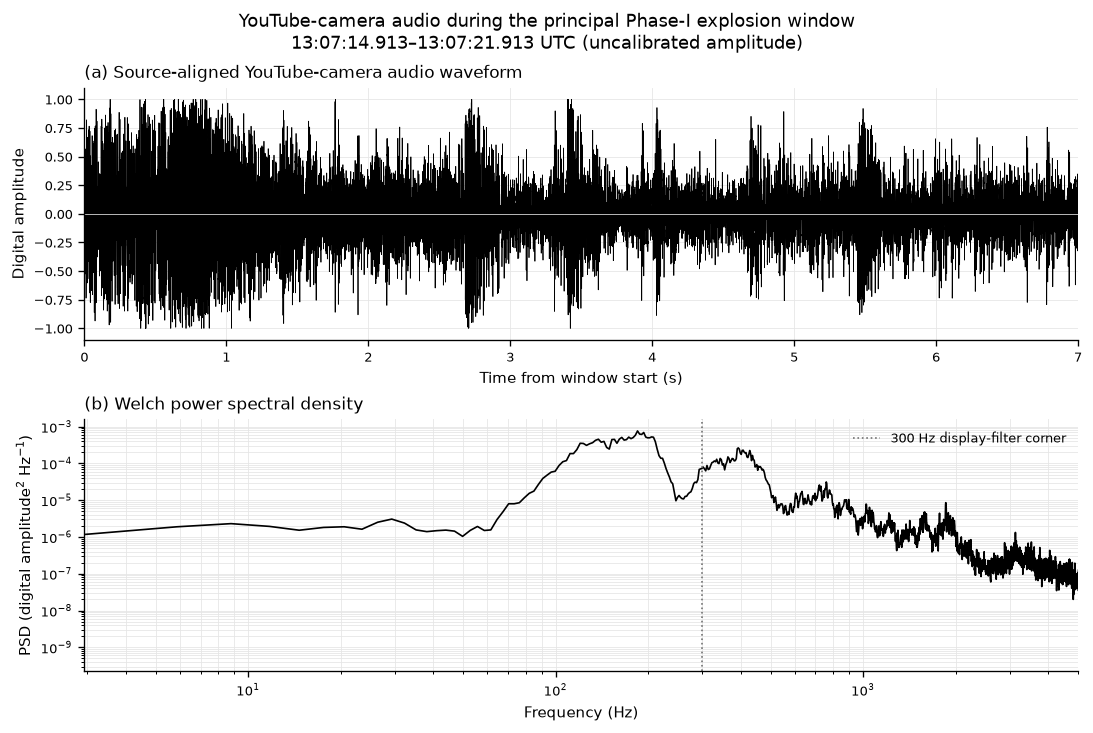

Wrote: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/170_generate_publication_figures/fig_audio_waveform_psd_phase1.pdf


In [32]:
from scipy.signal import welch

AUDIO_PSD_START = EXPLOSION_TIME + 3.0
AUDIO_PSD_END = EXPLOSION_TIME + 10.0
AUDIO_PSD_MAX_HZ = 5000.0
AUDIO_PSD_NPERSEG = 4096
AUDIO_PSD_OUTPUT = OUTDIR / "fig_audio_waveform_psd_phase1"


def make_audio_waveform_psd_figure(
    st_audio: Stream,
    starttime: UTCDateTime,
    endtime: UTCDateTime,
    outfile_base: Path,
):
    """Plot an uncalibrated camera-audio waveform and Welch PSD."""
    if len(st_audio) != 1:
        raise ValueError(f"Expected one synchronized audio trace; found {len(st_audio)}")

    trace = st_audio[0].copy().trim(starttime, endtime, pad=False)
    data = np.asarray(trace.data, dtype=float)
    finite = np.isfinite(data)
    if finite.sum() < 32:
        raise ValueError("Too few finite audio samples for the PSD diagnostic")
    data = np.where(finite, data, np.nanmedian(data[finite]))
    data -= np.mean(data)

    sampling_rate_hz = float(trace.stats.sampling_rate)
    nperseg = min(AUDIO_PSD_NPERSEG, len(data))
    noverlap = nperseg // 2
    frequency_hz, psd = welch(
        data,
        fs=sampling_rate_hz,
        window="hann",
        nperseg=nperseg,
        noverlap=noverlap,
        detrend="constant",
        scaling="density",
    )

    elapsed_s = np.arange(len(data), dtype=float) / sampling_rate_hz
    fig, axes = plt.subplots(
        2, 1, figsize=(9.0, 6.0), constrained_layout=True
    )
    waveform_ax, psd_ax = axes
    waveform_ax.plot(elapsed_s, data, color="black", lw=0.45, rasterized=True)
    waveform_ax.axhline(0.0, color="0.7", lw=0.6)
    waveform_ax.set_xlim(0.0, elapsed_s[-1])
    waveform_ax.set_ylabel("Digital amplitude")
    waveform_ax.set_xlabel("Time from window start (s)")
    waveform_ax.set_title(
        "(a) Source-aligned YouTube-camera audio waveform", loc="left"
    )

    positive = (frequency_hz > 0.0) & np.isfinite(psd) & (psd > 0.0)
    psd_ax.loglog(
        frequency_hz[positive], psd[positive], color="black", lw=1.0
    )
    minimum_hz = max(float(frequency_hz[positive][0]), 1.0)
    maximum_hz = min(
        AUDIO_PSD_MAX_HZ, 0.95 * 0.5 * sampling_rate_hz
    )
    psd_ax.set_xlim(minimum_hz, maximum_hz)
    psd_ax.axvline(
        300.0, color="0.45", ls=":", lw=1.0,
        label="300 Hz display-filter corner",
    )
    psd_ax.set_xlabel("Frequency (Hz)")
    psd_ax.set_ylabel("PSD (digital amplitude$^2$ Hz$^{-1}$)")
    psd_ax.set_title("(b) Welch power spectral density", loc="left")
    psd_ax.legend(frameon=False, loc="best")

    for ax in axes:
        ax.grid(True, which="both", color="0.9", lw=0.5)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    fig.suptitle(
        "YouTube-camera audio during the principal Phase-I explosion window\n"
        f"{starttime.strftime('%H:%M:%S.%f')[:-3]}–"
        f"{endtime.strftime('%H:%M:%S.%f')[:-3]} UTC (uncalibrated amplitude)"
    )
    for extension in ("pdf",):
        fig.savefig(
            outfile_base.with_suffix(f".{extension}"),
            dpi=300, bbox_inches="tight", pad_inches=0.04,
        )
    return fig, axes, frequency_hz, psd


if len(st_audio_raw):
    audio_psd_figure = make_audio_waveform_psd_figure(
        st_audio_raw,
        AUDIO_PSD_START,
        AUDIO_PSD_END,
        AUDIO_PSD_OUTPUT,
    )
    plt.show()
    print("Wrote:", AUDIO_PSD_OUTPUT.with_suffix(".pdf"))
else:
    warnings.warn("Skipping camera-audio PSD because Notebook 13 audio is unavailable")


# synchronized video frames and audio time series


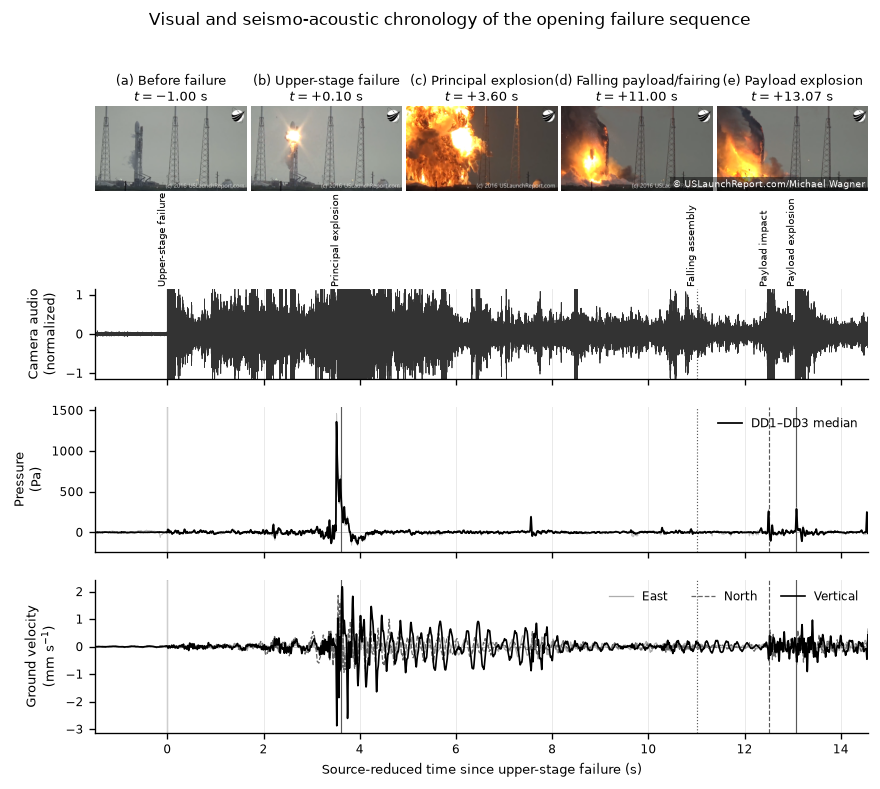

Saved figure: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/170_generate_publication_figures/video_waveform_chronology.pdf
Saved timing audit: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/170_generate_publication_figures/video_waveform_chronology_timing.csv
Camera propagation: 4254.5 m / 349.802 m/s = 12.163 s
BCHH source-reduction speed: 350.977 m/s


In [33]:
import subprocess
import sys
import tempfile
from pathlib import Path

import av
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.gridspec import GridSpec
from obspy import UTCDateTime, read
from pyproj import Geod
from scipy.io import wavfile
from scipy.signal import butter, sosfiltfilt


# -----------------------------------------------------------------------------
# Project configuration and required inputs
# -----------------------------------------------------------------------------

project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from modules import project_config as config
from modules.kml_utils import read_kml_points


if config.USLAUNCHREPORT_VIDEO_FILE is None:
    raise RuntimeError(
        "Set external_paths.uslaunchreport_video_file in "
        f"{config.LOCAL_CONFIG_FILE} to an authorized local copy of "
        "the USLaunchReport source movie."
    )

video_file = Path(config.USLAUNCHREPORT_VIDEO_FILE)
waveform_file = (
    config.NB010_DIR
    / "bchh_corrected_moving_median_baseline_removed.pkl"
)
weather_file = config.NB020_DIR / "weather_acoustic_summary.csv"
output_file = config.NB170_DIR / "video_waveform_chronology.pdf"

for label, path in {
    "USLaunchReport movie": video_file,
    "baseline-corrected waveform stream": waveform_file,
    "meteorological summary": weather_file,
    "launchpad/camera KML": config.KML_FILE,
}.items():
    if not path.is_file():
        raise FileNotFoundError(f"Missing {label}: {path}")

config.NB170_DIR.mkdir(parents=True, exist_ok=True)


# -----------------------------------------------------------------------------
# Timing, geometry, and display choices
# -----------------------------------------------------------------------------

upper_stage_utc = UTCDateTime(config.SOURCE_EVENT_TIMES["upper_stage"])
lower_stage_utc = UTCDateTime(config.SOURCE_EVENT_TIMES["lower_stage"])
payload_impact_utc = UTCDateTime(
    config.SOURCE_EVENT_TIMES["payload_impact"]
)
payload_explosion_utc = UTCDateTime(
    config.SOURCE_EVENT_TIMES["payload_explosion"]
)

lower_stage_offset_s = float(lower_stage_utc - upper_stage_utc)
payload_impact_offset_s = float(payload_impact_utc - upper_stage_utc)
payload_explosion_offset_s = float(
    payload_explosion_utc - upper_stage_utc
)

# Frame offsets are movie/source times relative to the upper-stage source time.
# The +0.10-s frame makes the initiating flash visible; the +11-s frame shows
# the descending payload/fairing assembly before its impact.
frame_specs = (
    ("a", "Before failure", -1.00),
    ("b", "Upper-stage failure", 0.10),
    ("c", "Principal explosion", lower_stage_offset_s),
    ("d", "Falling payload/fairing", 11.00),
    ("e", "Payload explosion", payload_explosion_offset_s),
)

plot_start_s = -1.5
plot_end_s = payload_explosion_offset_s + 1.5

# Named markers on the time-series panels.  The falling-object marker is a
# visual observation rather than a separately picked geophysical event.
timeline_markers = (
    ("Upper-stage failure", 0.0, "-"),
    ("Principal explosion", lower_stage_offset_s, "-"),
    ("Falling assembly", 11.0, ":"),
    ("Payload impact", payload_impact_offset_s, "--"),
    ("Payload explosion", payload_explosion_offset_s, "-"),
)


# -----------------------------------------------------------------------------
# Frame extraction using native presentation timestamps
# -----------------------------------------------------------------------------

def video_frame_at_pts(path: Path, requested_pts_s: float):
    """Return the decoded frame closest to a requested movie PTS."""
    with av.open(str(path)) as container:
        stream = container.streams.video[0]
        stream.thread_type = "AUTO"
        seek_pts = int(max(0.0, requested_pts_s) / float(stream.time_base))
        container.seek(seek_pts, stream=stream, backward=True)

        best_frame = None
        best_pts_s = np.nan
        best_error_s = np.inf
        for frame in container.decode(stream):
            if frame.pts is None:
                continue
            frame_pts_s = float(frame.pts * frame.time_base)
            error_s = abs(frame_pts_s - requested_pts_s)
            if error_s < best_error_s:
                best_frame = frame
                best_pts_s = frame_pts_s
                best_error_s = error_s
            if frame_pts_s >= requested_pts_s:
                break

        if best_frame is None:
            raise RuntimeError(
                f"No video frame decoded near PTS={requested_pts_s:.6f} s"
            )
        return (
            best_frame.to_ndarray(format="rgb24"),
            float(best_pts_s),
            float(best_error_s),
        )


video_frames = []
for letter, label, source_offset_s in frame_specs:
    requested_pts_s = (
        float(config.VIDEO_ANCHOR_MOVIE_S) + source_offset_s
    )
    image, actual_pts_s, error_s = video_frame_at_pts(
        video_file,
        requested_pts_s,
    )
    video_frames.append(
        {
            "letter": letter,
            "label": label,
            "source_offset_s": source_offset_s,
            "requested_pts_s": requested_pts_s,
            "actual_pts_s": actual_pts_s,
            "frame_error_s": error_s,
            "image": image,
        }
    )


# -----------------------------------------------------------------------------
# Camera-path propagation and source-reduced native camera audio
# -----------------------------------------------------------------------------

weather = pd.read_csv(weather_file).iloc[0]
kml_points = read_kml_points(config.KML_FILE)
for required_point in ("SLC40", "YouTube Video"):
    if required_point not in kml_points:
        raise KeyError(
            f"{required_point!r} is absent from {config.KML_FILE}; "
            f"available={sorted(kml_points)}"
        )

source_point = kml_points["SLC40"]
camera_point = kml_points["YouTube Video"]
geod = Geod(ellps="WGS84")
camera_azimuth_deg, _, camera_distance_m = geod.inv(
    float(source_point["lon"]),
    float(source_point["lat"]),
    float(camera_point["lon"]),
    float(camera_point["lat"]),
)
camera_azimuth_deg %= 360.0

still_air_speed_mps = float(weather["still_air_sound_speed_mps"])
wind_speed_mps = float(weather["path_vector_mean_wind_speed_mps"])
wind_from_deg = float(
    weather["path_vector_mean_wind_direction_from_deg"]
)
wind_to_deg = (wind_from_deg + 180.0) % 360.0
camera_wind_along_ray_mps = wind_speed_mps * np.cos(
    np.deg2rad(camera_azimuth_deg - wind_to_deg)
)
camera_effective_speed_mps = (
    still_air_speed_mps + camera_wind_along_ray_mps
)
camera_travel_time_s = camera_distance_m / camera_effective_speed_mps


def extract_camera_audio(path: Path, sample_rate_hz: int = 12000):
    """Extract native movie audio to a temporary mono WAV array."""
    with tempfile.TemporaryDirectory(prefix="falcon9_camera_audio_") as tmp:
        wav_path = Path(tmp) / "camera_audio.wav"
        command = [
            "ffmpeg",
            "-y",
            "-loglevel",
            "error",
            "-i",
            str(path),
            "-vn",
            "-ac",
            "1",
            "-ar",
            str(sample_rate_hz),
            "-c:a",
            "pcm_s16le",
            str(wav_path),
        ]
        subprocess.run(command, check=True)
        actual_rate_hz, values = wavfile.read(wav_path)
    return float(actual_rate_hz), np.asarray(values, dtype=float)


audio_rate_hz, camera_audio = extract_camera_audio(video_file)
camera_audio -= np.nanmedian(camera_audio)

# Filtering is used only to make the uncalibrated camera audio legible.  BCHH
# pressure and seismic traces below remain unfiltered.
audio_sos = butter(
    4,
    300.0,
    btype="highpass",
    fs=audio_rate_hz,
    output="sos",
)
camera_audio = sosfiltfilt(audio_sos, camera_audio)
audio_scale = np.nanpercentile(np.abs(camera_audio), 99.8)
if not np.isfinite(audio_scale) or audio_scale <= 0:
    audio_scale = 1.0
camera_audio /= audio_scale

native_audio_pts_s = np.arange(camera_audio.size) / audio_rate_hz
audio_source_relative_s = (
    native_audio_pts_s
    - float(config.VIDEO_ANCHOR_MOVIE_S)
    - camera_travel_time_s
)
audio_include = (
    (audio_source_relative_s >= plot_start_s)
    & (audio_source_relative_s <= plot_end_s)
)


# -----------------------------------------------------------------------------
# Source-reduced BCHH pressure and ground velocity
# -----------------------------------------------------------------------------

stream = read(str(waveform_file), format="PICKLE")
source_to_bchh_speed_mps = float(weather["effective_sound_speed_mps"])


def trace_source_distance_m(trace) -> float:
    """Read source distance from the canonical trace metadata."""
    geometry = getattr(trace.stats, "source_geometry", None)
    if geometry is not None and hasattr(geometry, "distance_m"):
        return float(geometry.distance_m)

    coordinates = getattr(trace.stats, "coordinates", None)
    if coordinates is not None:
        longitude = getattr(coordinates, "longitude", None)
        latitude = getattr(coordinates, "latitude", None)
        if longitude is not None and latitude is not None:
            _, _, distance_m = geod.inv(
                float(source_point["lon"]),
                float(source_point["lat"]),
                float(longitude),
                float(latitude),
            )
            return float(distance_m)

    raise ValueError(f"{trace.id} lacks usable source-distance metadata")


def source_relative_time_s(trace) -> np.ndarray:
    """Return trace times after removing source-to-sensor acoustic travel."""
    observed_epoch_s = (
        float(trace.stats.starttime.timestamp)
        + np.arange(trace.stats.npts) / float(trace.stats.sampling_rate)
    )
    return (
        observed_epoch_s
        - trace_source_distance_m(trace) / source_to_bchh_speed_mps
        - float(upper_stage_utc.timestamp)
    )


pressure_channels = ("DD1", "DD2", "DD3")
seismic_channels = ("DHE", "DHN", "DHZ")


def one_trace(channel: str):
    matches = [tr for tr in stream if tr.stats.channel == channel]
    if len(matches) != 1:
        raise ValueError(
            f"Expected one {channel} trace; found {[tr.id for tr in matches]}"
        )
    return matches[0].copy()


pressure_traces = [one_trace(channel) for channel in pressure_channels]
seismic_traces = [one_trace(channel) for channel in seismic_channels]

common_sample_rate_hz = min(
    float(trace.stats.sampling_rate) for trace in pressure_traces
)
common_time_s = np.arange(
    plot_start_s,
    plot_end_s + 0.5 / common_sample_rate_hz,
    1.0 / common_sample_rate_hz,
)

aligned_pressure = []
for trace in pressure_traces:
    time_s = source_relative_time_s(trace)
    aligned_pressure.append(
        np.interp(
            common_time_s,
            time_s,
            np.asarray(trace.data, dtype=float),
            left=np.nan,
            right=np.nan,
        )
    )
aligned_pressure = np.asarray(aligned_pressure)
pressure_beam = np.nanmedian(aligned_pressure, axis=0)


# -----------------------------------------------------------------------------
# Publication figure
# -----------------------------------------------------------------------------

plt.rcParams.update(
    {
        "font.size": 8,
        "axes.titlesize": 8,
        "axes.labelsize": 8,
        "legend.fontsize": 7,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
    }
)

fig = plt.figure(figsize=(7.2, 6.6), constrained_layout=False)
outer = GridSpec(
    4,
    1,
    figure=fig,
    height_ratios=(1.55, 0.62, 1.0, 1.05),
    hspace=0.18,
    left=0.09,
    right=0.985,
    bottom=0.085,
    top=0.965,
)

frame_grid = outer[0].subgridspec(1, len(video_frames), wspace=0.025)
for index, record in enumerate(video_frames):
    axis = fig.add_subplot(frame_grid[0, index])
    axis.imshow(record["image"])
    axis.set_xticks([])
    axis.set_yticks([])
    for spine in axis.spines.values():
        spine.set_visible(False)
    axis.set_title(
        f"({record['letter']}) {record['label']}\n"
        f"$t={record['source_offset_s']:+.2f}$ s",
        pad=3,
    )

frame_axis = fig.axes[len(video_frames) - 1]
frame_axis.text(
    0.98,
    0.02,
    "\u00a9 USLaunchReport.com/Michael Wagner",
    transform=frame_axis.transAxes,
    ha="right",
    va="bottom",
    fontsize=5.5,
    color="white",
    bbox={"facecolor": "black", "alpha": 0.45, "pad": 1.2, "edgecolor": "none"},
)

audio_axis = fig.add_subplot(outer[1])
pressure_axis = fig.add_subplot(outer[2], sharex=audio_axis)
seismic_axis = fig.add_subplot(outer[3], sharex=audio_axis)

audio_axis.plot(
    audio_source_relative_s[audio_include],
    camera_audio[audio_include],
    color="0.20",
    linewidth=0.45,
)
audio_axis.set_ylabel("Camera audio\n(normalized)")
audio_axis.set_ylim(-1.15, 1.15)

for row, channel in zip(aligned_pressure, pressure_channels):
    pressure_axis.plot(
        common_time_s,
        row,
        color="0.72",
        linewidth=0.55,
        alpha=0.8,
    )
pressure_axis.plot(
    common_time_s,
    pressure_beam,
    color="black",
    linewidth=1.05,
    label="DD1–DD3 median",
)
pressure_axis.set_ylabel("Pressure\n(Pa)")
pressure_axis.legend(frameon=False, loc="upper right")

seismic_styles = {
    "DHE": ("0.68", "-", "East"),
    "DHN": ("0.40", "--", "North"),
    "DHZ": ("0.00", "-", "Vertical"),
}
for trace in seismic_traces:
    relative_time_s = source_relative_time_s(trace)
    values = np.asarray(trace.data, dtype=float)
    baseline_mask = (
        (relative_time_s >= plot_start_s)
        & (relative_time_s <= -0.25)
    )
    if np.any(baseline_mask):
        values = values - np.nanmedian(values[baseline_mask])
    color, linestyle, label = seismic_styles[trace.stats.channel]
    seismic_axis.plot(
        relative_time_s,
        values * 1.0e3,
        color=color,
        linestyle=linestyle,
        linewidth=0.75 if trace.stats.channel != "DHZ" else 1.0,
        label=label,
    )
seismic_axis.set_ylabel("Ground velocity\n(mm s$^{-1}$)")
seismic_axis.set_xlabel("Source-reduced time since upper-stage failure (s)")
seismic_axis.legend(frameon=False, loc="upper right", ncol=3)

signal_axes = (audio_axis, pressure_axis, seismic_axis)
for axis in signal_axes:
    axis.axhline(0.0, color="0.75", linewidth=0.5, zorder=0)
    axis.set_xlim(plot_start_s, plot_end_s)
    axis.grid(axis="x", color="0.90", linewidth=0.5)
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)
    for _, marker_time_s, linestyle in timeline_markers:
        axis.axvline(
            marker_time_s,
            color="0.35",
            linestyle=linestyle,
            linewidth=0.7,
            zorder=0,
        )

for label, marker_time_s, _ in timeline_markers:
    audio_axis.text(
        marker_time_s,
        1.02,
        label,
        transform=audio_axis.get_xaxis_transform(),
        rotation=90,
        ha="right",
        va="bottom",
        fontsize=6.1,
        clip_on=False,
    )

plt.setp(audio_axis.get_xticklabels(), visible=False)
plt.setp(pressure_axis.get_xticklabels(), visible=False)

fig.suptitle(
    "Visual and seismo-acoustic chronology of the opening failure sequence",
    y=0.995,
    fontsize=10,
)
fig.savefig(output_file, format="pdf", bbox_inches="tight")
plt.show()


# Audit the exact timing used in the figure.
frame_audit = pd.DataFrame(
    [
        {
            key: value
            for key, value in record.items()
            if key != "image"
        }
        for record in video_frames
    ]
)
frame_audit["camera_distance_m"] = camera_distance_m
frame_audit["camera_effective_speed_mps"] = camera_effective_speed_mps
frame_audit["camera_travel_time_s"] = camera_travel_time_s
frame_audit["bchh_effective_speed_mps"] = source_to_bchh_speed_mps
audit_file = config.NB170_DIR / "video_waveform_chronology_timing.csv"
frame_audit.to_csv(audit_file, index=False)

print(f"Saved figure: {output_file}")
print(f"Saved timing audit: {audit_file}")
print(
    "Camera propagation: "
    f"{camera_distance_m:.1f} m / {camera_effective_speed_mps:.3f} m/s "
    f"= {camera_travel_time_s:.3f} s"
)
print(
    "BCHH source-reduction speed: "
    f"{source_to_bchh_speed_mps:.3f} m/s"
)